# Bayesian Double Machine Learning con BART y Cross-Fitting
## Estimating the Effects of Differentiated Minimum Wage Policies and Fiscal Incentives on Informal Employment in Mexico's Northern Border Municipalities.

**Autor:** Leobardo Enríquez Hernández

**Junio de 2026.**

---

**Sección de tesis:** §3.2 — *Bayesian Double Machine Learning con BART y cross-fitting*  
**Notebook previo (§3.1):** `PS_AIPW_DR.ipynb` — Propensity score bayesiano + estimador doblemente robusto AIPW  
**Dependencia de datos:** `dataset.xlsx` (muestra completa, 281 municipios) y `dataset_trimmed.xlsx` (muestra recortada, generada por `PS_AIPW_DR.ipynb`)


## Requisitos de software

El notebook está escrito y probado contra las versiones más recientes (junio 2026):

| Paquete | Versión mínima | Notas |
|---|---|---|
| `pymc` | **6.0** | `pm.Data` es mutable por defecto. `pm.MutableData` ya no existe. |
| `pymc-bart` | **0.12** | Requiere `numba` y `numpy >= 2.0`. Expone `OneHotSplitRule`, `ContinuousSplitRule`, `plot_convergence`, `compute_variable_importance`. La predicción OOF se realiza directamente sobre `bartrv.owner.op.all_trees`. |
| `arviz` | **1.1** | API: `az.hdi(x, prob=...)` (no `hdi_prob`). |
| `numba` | reciente | Requerida por `pymc-bart` para el sampler PGBART. |
| `statsmodels`, `pandas`, `seaborn`, `geopandas`, `openpyxl`, `scikit-learn` | recientes | sin cambios de API relevantes. |

```bash
pip install -U pymc pymc-bart arviz statsmodels pandas seaborn geopandas openpyxl scikit-learn
```

**Advertencia técnica sobre predicción OOF con BART:**  
En `pymc-bart 0.12`, la predicción out-of-fold (OOF) se realiza accediendo directamente a `bartrv.owner.op.all_trees` y evaluando cada árbol sobre los datos de prueba. Esto funciona correctamente **siempre que el sampler sea únicamente PGBART** (sin `CompoundStep` que combine PGBART con NUTS). Por ello, el BART del *outcome nuisance* $m_0(x)$ se especifica sin `sigma` como parámetro muestreado: se estima $\hat\sigma_y$ a partir de los datos de entrenamiento de cada fold y se fija, eliminando NUTS del modelo. El BART del PS ($e_0(x)$) ya usa sólo PGBART (likelihood Bernoulli) y no tiene este problema.


## Configuración de reproducibilidad y carga de paquetes

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# REPRODUCIBILIDAD
# ─────────────────────────────────────────────────────────────────────────────
import os

SEED = 3101
os.environ["PYTHONHASHSEED"] = str(SEED)
# Un solo hilo en las BLAS: elimina no-determinismo por orden de reducción en paralelo
for _v in ("MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[_v] = "1"

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import seaborn as sns
import geopandas as gpd
import arviz as az
import pymc as pm
import pymc_bart as pmb
import statsmodels.api as sm
import scipy.stats as stats
from scipy.stats import norm
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from numba import njit

%config InlineBackend.figure_format = "retina"
for _st in ("arviz-whitegrid", "seaborn-v0_8-whitegrid"):
    if _st in plt.style.available:
        plt.style.use(_st)
        break

# ── Figuras en alta definición ────────────────────────────────────────────────
FIG_DIR = "FigurasBDML"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(os.path.join(FIG_DIR, "pdf"), exist_ok=True)

def save_fig(nombre, fig=None):
    """Guarda PNG 300 dpi y PDF vectorial."""
    if fig is None:
        fig = plt.gcf()
    fig.savefig(os.path.join(FIG_DIR, f"{nombre}.png"),
                dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(os.path.join(FIG_DIR, "pdf", f"{nombre}.pdf"),
                bbox_inches="tight", facecolor="white")
    print(f"[guardada] {FIG_DIR}/{nombre}.png  (+ pdf)")

# ── Semilla del RNG interno de Numba ─────────────────────────────────────────
# numba mantiene su PROPIO estado aleatorio en código compilado (nopython),
# independiente del estado global de NumPy. La única forma de sembrarlo es
# llamar a np.random.seed DENTRO de una función @njit:
@njit(cache=False)
def _seed_numba(seed):
    np.random.seed(seed)

def fix_all_seeds(seed=SEED):
    """Fija TODAS las fuentes de aleatoriedad relevantes:
       1) NumPy global,
       2) random de la stdlib,
       3) RNG interno de numba (usado por PGBART de pymc-bart)."""
    np.random.seed(seed)
    random.seed(seed)
    _seed_numba(seed)

fix_all_seeds(SEED)

# ── Verificación de versiones mínimas ────────────────────────────────────────
from importlib.metadata import version as _version
_req = {"pymc": "6.0", "pymc-bart": "0.12", "arviz": "1.1"}
for _pkg, _min in _req.items():
    _v = _version(_pkg)
    _ok = tuple(map(int, _v.split(".")[:2])) >= tuple(map(int, _min.split(".")))
    status = "✓" if _ok else "✗ REQUIERE >= " + _min
    print(f"{_pkg:>12}: {_v}  {status}")
print(f"{'numpy':>12}: {np.__version__}")
print(f"{'pandas':>12}: {pd.__version__}")
print(f"{'statsmodels':>12}: {sm.__version__}")


        pymc: 6.0.1  ✓
   pymc-bart: 0.12.0  ✓
       arviz: 1.1.0  ✓
       numpy: 2.4.6
      pandas: 3.0.3
 statsmodels: 0.14.6


## Datos

La muestra incluye 281 municipios de los seis estados mexicanos fronterizos con Estados Unidos, 43 de los cuales pertenecen a la Zona Libre de la Frontera Norte (ZLFN). El notebook trabaja con **dos conjuntos de datos**:

- **`dataset.xlsx`** — muestra completa (281 municipios), análisis principal (§3.2).
- **`dataset_trimmed.xlsx`** — muestra recortada (0.1 ≤ PS ≤ 0.9 bajo ambos modelos), generada por `PS_AIPW_DR.ipynb` (§3.1). Se usa para el análisis de robustez.

Las variables de diseño son idénticas a las de §3.1.


In [2]:
dat = pd.read_excel("dataset.xlsx")
dat["state"]     = dat["state"].astype("category")
dat["pib_class"] = dat["pib_class"].astype("category")
dat["urban"]     = dat["urban"].astype("category")
print(f"Municipios cargados (muestra completa): {len(dat)}")
dat.head()


Municipios cargados (muestra completa): 281


,LLAVE,municipality_name,state,urban,maquila,informal_class,poverty_class,pib_class,pibpc_class,share_manuf_class,informal,imssissste,poverty,lpopulation,urbanpop,lpib,lpibpc,share_manufacture,trt,outcome
0,2001,Baja California Ensenada,2,1,1,2,2,5,5,4,44.941117,80.477908,27.900848,13.252382,89.753307,25.137456,12.142288,30.413544,1,-6.050756
1,2002,Baja California Mexicali,2,1,1,1,2,5,5,4,38.635661,83.170333,22.949496,13.830386,92.300043,26.241905,12.297599,36.977853,1,-3.421040
2,2003,Baja California Tecate,2,1,1,1,2,5,5,5,41.702882,82.648756,23.872581,11.616114,82.855594,24.059878,12.473903,54.628673,1,-2.901544
3,2004,Baja California Tijuana,2,1,1,1,2,5,5,5,36.177469,85.861896,26.588062,14.342304,99.644967,26.803545,12.283074,50.296458,1,0.566683
4,2005,Baja California Playas de Rosarito,2,1,1,2,3,5,5,5,56.410941,75.087620,34.528759,11.614561,90.029092,24.014745,12.271645,42.574534,1,-11.938737


### Matrices de diseño

**Nota de especificación (consistente con §3.1):**
- Para BART: se usan todas las dummies con `OneHotSplitRule`; las variables continuas usan `ContinuousSplitRule`.
- Los dummies de estado representan efectos fijos por entidad federativa (sin omitir categoría base, ya que BART no necesita identificación lineal).


In [3]:
# Dummies de estado y clase de PIB (todas las categorías; BART no requiere drop_first)
all_states    = [2, 5, 8, 19, 26, 28]
all_pib_class = [1, 2, 3, 4, 5]

d1 = pd.get_dummies(
    pd.Categorical(dat["state"].astype(int), categories=all_states),
    prefix="state", dtype=int
)
d2 = pd.get_dummies(
    pd.Categorical(dat["pib_class"].astype(int), categories=all_pib_class),
    prefix="pib_class", dtype=int
)
selected_columns = dat[["LLAVE", "urban", "maquila", "informal", "imssissste",
                         "lpibpc", "poverty", "share_manufacture", "lpopulation",
                         "trt", "outcome"]]
data = pd.concat([selected_columns, d1, d2], axis=1)

# Columnas continuas y dummies para split_rules
CONT_COLS = ["informal", "imssissste", "lpibpc", "poverty",
             "share_manufacture", "lpopulation"]
DUM_COLS  = ["urban", "maquila",
             "state_2", "state_5", "state_8", "state_19", "state_26", "state_28",
             "pib_class_1", "pib_class_2", "pib_class_3", "pib_class_4", "pib_class_5"]
ALL_COVS  = CONT_COLS + DUM_COLS

SPLIT_RULES = (
    [pmb.ContinuousSplitRule] * len(CONT_COLS)
    + [pmb.OneHotSplitRule]   * len(DUM_COLS)
)

X = data[ALL_COVS].copy()
t = data["trt"]
y = data["outcome"]
n_obs = len(X)

print(f"n = {n_obs},  tratados = {t.sum()},  controles = {(1-t).sum()}")
print(f"Covariables: {len(ALL_COVS)}  ({len(CONT_COLS)} continuas + {len(DUM_COLS)} dummies)")
data.head()


n = 281,  tratados = 43,  controles = 238
Covariables: 19  (6 continuas + 13 dummies)


,LLAVE,urban,maquila,informal,imssissste,lpibpc,poverty,share_manufacture,lpopulation,trt,...,state_5,state_8,state_19,state_26,state_28,pib_class_1,pib_class_2,pib_class_3,pib_class_4,pib_class_5
0,2001,1,1,44.941117,80.477908,12.142288,27.900848,30.413544,13.252382,1,...,0,0,0,0,0,0,0,0,0,1
1,2002,1,1,38.635661,83.170333,12.297599,22.949496,36.977853,13.830386,1,...,0,0,0,0,0,0,0,0,0,1
2,2003,1,1,41.702882,82.648756,12.473903,23.872581,54.628673,11.616114,1,...,0,0,0,0,0,0,0,0,0,1
3,2004,1,1,36.177469,85.861896,12.283074,26.588062,50.296458,14.342304,1,...,0,0,0,0,0,0,0,0,0,1
4,2005,1,1,56.410941,75.087620,12.271645,34.528759,42.574534,11.614561,1,...,0,0,0,0,0,0,0,0,0,1


## Marco teórico (§3.2)

El estimador DML con cross-fitting (Chernozhukov et al., 2018) identifica el ATE bajo la **representación lineal parcial de Robinson** (§3.2.1):

$$Y_i = \theta_0\,Z_i + g_0(X_i) + \varepsilon_i, \quad \mathbb{E}[\varepsilon_i\mid X_i,Z_i]=0$$

donde $g_0(\cdot)$ es desconocida y $\theta_0\in\mathbb{R}$ es el ATE. Las funciones nuisance son:

$$e_0(x) = \mathbb{P}(Z=1\mid X=x), \qquad m_0(x) = \mathbb{E}[Y\mid X=x]$$

La **ecuación ortogonalizada de Robinson** (§3.2.2) es:

$$\tilde Y_i := Y_i - m_0(X_i), \quad \tilde Z_i := Z_i - e_0(X_i), \quad \tilde Y_i = \theta_0\,\tilde Z_i + \varepsilon_i$$

**Implementación con cross-fitting K=4 y BART bayesiano para nuisances (§3.2.3–3.2.5):**

Para cada fold $k$:
1. BART normal (con $\sigma_y$ fijo en cada fold): $m_0^{(-k)}(x) \approx \mathbb{E}[Y\mid X=x]$ — *outcome nuisance*.
2. BART probit (PGBART): $e_0^{(-k)}(x) = \Phi(f(X_i))$ — *propensity nuisance*.
3. Residuos OOF: $\tilde Y_i^{(s)} = Y_i - \hat m^{(-k(i),s)}(X_i)$, $\tilde Z_i^{(s)} = Z_i - \hat e^{(-k(i),s)}(X_i)$.
4. Estimador por draw (§3.2.5): $\hat\theta^{(s)} = \frac{\sum_i (\tilde Z_i^{(s)} - \bar{\tilde Z}^{(s)})(\tilde Y_i^{(s)} - \bar{\tilde Y}^{(s)})}{\sum_i (\tilde Z_i^{(s)} - \bar{\tilde Z}^{(s)})^2}$

El conjunto $\{\hat\theta^{(s)}\}_{s=1}^S$ es la **distribución posterior inducida** del ATE (§3.2.5). El **score ortogonal de Neyman** (§3.2.6) garantiza que errores de primer orden en los nuisances afectan a $\hat\theta$ sólo en segundo orden.

**Nota sobre $m_0$ y $m_z$:** En esta sección, $m_0(x) = \mathbb{E}[Y\mid X=x]$ es la regresión marginal del outcome (sin condicionar en tratamiento), distinto de $m_z(x)=\mathbb{E}[Y\mid Z=z,X=x]$ usado en §3.1. Esta es la convención estándar DML.


## Implementación del BDML bayesiano

### Función de predicción OOF a partir de `all_trees`

En `pymc-bart 0.12`, la predicción en nuevos datos (OOF) se realiza accediendo directamente
a `bartrv.owner.op.all_trees`, una lista donde el índice $s$ corresponde al draw posterior $s$.
Esto requiere que el modelo use **únicamente PGBART** (sin `CompoundStep` mixto),
lo que se garantiza fijando $\sigma_y$ en los modelos de outcome.


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# bart_predict_draws: predicción OOF usando all_trees de pymc-bart 0.12
# ─────────────────────────────────────────────────────────────────────────────
def bart_predict_draws(bartrv, X_new: np.ndarray) -> np.ndarray:
    """
    Evalúa todos los draws posteriores del BART en X_new.

    Parámetros
    ----------
    bartrv : TensorVariable
        Variable BART (e.g. mu, eta) DESPUÉS de pm.sample.
    X_new : np.ndarray, shape (n_new, p)
        Matriz de covariables en la que predecir.

    Retorna
    -------
    preds : np.ndarray, shape (S, n_new)
        Predicciones por draw posterior. S = chains * draws.

    Notas
    -----
    - Solo funciona cuando el sampler es únicamente PGBART (sin NUTS en el mismo modelo).
      Para el outcome BART se fija sigma_y → PGBART puro → len(all_trees) = chains * draws.
    - Para el PS BART (Bernoulli/Probit): también PGBART puro → funciona directamente.
    """
    all_trees = bartrv.owner.op.all_trees
    X_new = np.asarray(X_new, dtype=float)
    S = len(all_trees)
    n_new = X_new.shape[0]
    preds = np.zeros((S, n_new), dtype=float)
    for s in range(S):
        # all_trees[s] es una lista de output-dims; dim 0 = escalar
        for tree in all_trees[s][0]:
            preds[s] += tree.predict(x=X_new, shape=1).ravel()
    return preds


### Funciones de estimación BART para los nuisances

Conforme a §3.2.4:

**Outcome nuisance** $m_0(x) = \mathbb{E}[Y\mid X=x]$:
BART Normal con $\sigma_y$ fijo por fold (estimado en el conjunto de entrenamiento de cada fold).
La fijación de $\sigma_y$ elimina NUTS del modelo → solo PGBART → `all_trees` tiene exactamente
`chains × draws` entradas → predicción OOF exacta y reproducible.

**PS nuisance** $e_0(x) = \Phi(f(X_i))$:
BART Probit-Bernoulli (PGBART puro, §3.2.4). Idéntico en estructura al Modelo 2 de §3.1
(`PS_AIPW_DR.ipynb`), pero re-estimado dentro de cada fold del cross-fitting.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Outcome nuisance: BART Normal con sigma_y fijo por fold
# Sección §3.2.4 de la tesis
# ─────────────────────────────────────────────────────────────────────────────
def fit_outcome_bart(
    X_train: np.ndarray,
    y_train: np.ndarray,
    split_rules: list,
    m: int = 50,
    draws: int = 4000,
    tune: int = 1000,
    chains: int = 4,
    random_seed: int = SEED,
) -> tuple:
    """
    Estima BART normal con sigma_y fijo (= std de y_train).

    La fijación de sigma_y garantiza que el modelo use solo PGBART
    (sin CompoundStep PGBART+NUTS), lo que hace que all_trees tenga
    exactamente chains * draws entradas y permite predicción OOF exacta.

    Parámetros
    ----------
    X_train, y_train : arrays de entrenamiento del fold.
    split_rules : lista de SplitRule, una por columna de X.
    m : número de árboles BART.
    draws, tune, chains : parámetros de muestreo.
    random_seed : semilla para reproducibilidad.

    Retorna
    -------
    (model, idata, mu_rv) : modelo pymc, InferenceData, TensorVariable BART.
    """
    X_arr = np.asarray(X_train, dtype=float)
    y_arr = np.asarray(y_train, dtype=float)
    sigma_fixed = float(y_arr.std())          # estimado en datos de entrenamiento

    fix_all_seeds(random_seed)
    with pm.Model() as model:
        mu = pmb.BART("mu", X=X_arr, Y=y_arr, m=m, split_rules=split_rules)
        # sigma fijo → solo PGBART → len(all_trees) = chains * draws ✓
        pm.Normal("y_obs", mu=mu, sigma=sigma_fixed, observed=y_arr)
        idata = pm.sample(
            draws=draws, tune=tune, chains=chains, cores=1,
            random_seed=random_seed, progressbar=True,
            compute_convergence_checks=False
        )
    return model, idata, mu


# ─────────────────────────────────────────────────────────────────────────────
# PS nuisance: BART Probit-Bernoulli (§3.2.4 y §3.1)
# ─────────────────────────────────────────────────────────────────────────────
def fit_ps_bart(
    X_train: np.ndarray,
    t_train: np.ndarray,
    split_rules: list,
    m: int = 50,
    draws: int = 4000,
    tune: int = 1000,
    chains: int = 4,
    random_seed: int = SEED,
) -> tuple:
    """
    Estima BART Probit-Bernoulli para el propensity score.

    Usa enlace probit: e(X_i) = Phi(eta(X_i)), con eta ~ BART.
    Equivalente al Modelo 2 de §3.1, re-estimado en cada fold del cross-fitting.
    La representación con variable latente (eq. 3.2.4 de la tesis) justifica el enlace probit.

    Solo PGBART (sin NUTS) → len(all_trees) = chains * draws ✓

    Retorna
    -------
    (model, idata, eta_rv) : modelo pymc, InferenceData, TensorVariable BART (escala probit).
    """
    X_arr = np.asarray(X_train, dtype=float)
    t_arr = np.asarray(t_train, dtype=float)

    fix_all_seeds(random_seed)
    with pm.Model() as model:
        eta = pmb.BART("eta", X=X_arr, Y=t_arr, m=m, split_rules=split_rules)
        p   = pm.Deterministic("p", pm.math.invprobit(eta))
        pm.Bernoulli("t_obs", p=p, observed=t_arr.astype(int))
        idata = pm.sample(
            draws=draws, tune=tune, chains=chains, cores=1,
            random_seed=random_seed, progressbar=True,
            compute_convergence_checks=False
        )
    return model, idata, eta


### Estimador DML con cross-fitting bayesiano (función principal)

Implementa el estimador de la §3.2.3 con distribución posterior inducida (§3.2.5).


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# dml_crossfit_bayesian_bart
# Secciones §3.2.3–3.2.5 de la tesis
# ─────────────────────────────────────────────────────────────────────────────
def dml_crossfit_bayesian_bart(
    X: pd.DataFrame,
    t: pd.Series,
    y: pd.Series,
    split_rules: list,
    K: int = 4,
    stratify_t: bool = True,
    m_outcome: int = 50,
    m_ps: int = 50,
    draws: int = 4000,
    tune: int = 1000,
    chains: int = 4,
    p_clip: float = 1e-3,
    random_seed: int = SEED,
) -> dict:
    """
    BDML con cross-fitting K-fold y BART bayesiano para ambos nuisances.

    Conforme a §3.2.3–3.2.5:
      - Outcome nuisance m_0(x) = E[Y|X=x]: BART Normal con sigma fijo por fold.
      - PS nuisance e_0(x) = Phi(eta(x)): BART Probit-Bernoulli.
      - Predicción OOF via bart_predict_draws sobre all_trees.
      - Theta puntual: OLS de ytilde en ttilde (con intercepto, HC3) apilado.
      - Theta draws: formula de Robinson centrada por draw (eq. 3.2.9 de la tesis).
      - Distribución posterior inducida: {theta^(s)}_{s=1}^S.

    Parámetros
    ----------
    X : DataFrame de covariables pretratamiento.
    t : Series de indicador de tratamiento {0,1}.
    y : Series del outcome (continuo).
    split_rules : lista de SplitRule por columna de X.
    K : número de folds para cross-fitting.
    stratify_t : si True, estratifica los folds por tratamiento.
    m_outcome, m_ps : número de árboles BART para outcome y PS.
    draws, tune, chains : parámetros de muestreo BART.
    p_clip : valor mínimo/máximo para clipear el PS (estabilidad numérica).
    random_seed : semilla base.

    Retorna
    -------
    dict con:
      theta_hat         : float, estimador puntual apilado (OLS HC3 sobre residuos medios)
      ols_summary       : resumen OLS HC3 de la etapa final
      theta_folds       : list[float], theta por fold
      fold_summaries    : list[OLS summary], resumen por fold
      y_tilde           : np.ndarray (n,), residuos de outcome (medias posteriores)
      t_tilde           : np.ndarray (n,), residuos de tratamiento (medias posteriores)
      theta_draws       : np.ndarray (S,), distribución posterior inducida del ATE
      ytilde_full       : np.ndarray (S, n), residuos outcome por draw
      ttilde_full       : np.ndarray (S, n), residuos tratamiento por draw
      fold_diagnostics  : list[dict], diagnósticos por fold (n_treated, n_control, sigma_y)
      stability         : dict, métricas de estabilidad numérica de ttilde
    """
    X = pd.DataFrame(X).reset_index(drop=True)
    t = (pd.Series(t).reset_index(drop=True) > 0).astype(int)
    y = pd.Series(y).reset_index(drop=True)
    n = len(X)

    y_tilde = np.zeros(n, dtype=float)
    t_tilde = np.zeros(n, dtype=float)
    ytilde_draws_list, ttilde_draws_list, test_index_list = [], [], []
    theta_folds, fold_summaries, fold_diagnostics = [], [], []

    if stratify_t:
        splitter  = StratifiedKFold(n_splits=K, shuffle=True, random_state=random_seed)
        split_gen = splitter.split(X, t)
    else:
        splitter  = KFold(n_splits=K, shuffle=True, random_state=random_seed)
        split_gen = splitter.split(X)

    for fold, (tr_idx, te_idx) in enumerate(split_gen):
        print(f"\n{'='*60}")
        print(f"  FOLD {fold+1}/{K}  |  train={len(tr_idx)},  test={len(te_idx)}")
        print(f"{'='*60}")

        X_tr, X_te = X.iloc[tr_idx].values, X.iloc[te_idx].values
        y_tr = y.iloc[tr_idx].values.astype(float)
        y_te = y.iloc[te_idx].values.astype(float)
        t_tr = t.iloc[tr_idx].values.astype(float)
        t_te = t.iloc[te_idx].values.astype(float)

        n_tr_1 = int(t_tr.sum())
        fold_diagnostics.append({"fold": fold, "n_train": len(tr_idx),
                                  "n_test": len(te_idx),
                                  "n_treated_train": n_tr_1,
                                  "n_control_train": len(tr_idx) - n_tr_1,
                                  "sigma_y_fixed": float(y_tr.std())})

        # ── PS nuisance (BART Probit) ────────────────────────────────────────
        print(f"  [Fold {fold+1}] Estimando PS nuisance (BART Probit)...")
        _, _, eta_rv = fit_ps_bart(
            X_tr, t_tr, split_rules=split_rules, m=m_ps,
            draws=draws, tune=tune, chains=chains,
            random_seed=random_seed + 10_000 + fold
        )
        # Predicción OOF: S draws × n_te observaciones
        eta_oof = bart_predict_draws(eta_rv, X_te)         # (S, n_te)
        p_oof   = norm.cdf(eta_oof)                        # Phi(eta) → propensity
        p_oof   = np.clip(p_oof, p_clip, 1.0 - p_clip)    # estabilidad (ec. 3.2.4)
        p_mean  = p_oof.mean(axis=0)                       # media posterior puntual

        t_tilde[te_idx]     = t_te - p_mean               # residuo puntual
        ttilde_draws        = t_te[None, :] - p_oof        # (S, n_te)
        ttilde_draws_list.append(ttilde_draws)

        # ── Outcome nuisance (BART Normal, sigma fijo) ───────────────────────
        print(f"  [Fold {fold+1}] Estimando outcome nuisance (BART Normal)...")
        _, _, mu_rv = fit_outcome_bart(
            X_tr, y_tr, split_rules=split_rules, m=m_outcome,
            draws=draws, tune=tune, chains=chains,
            random_seed=random_seed + fold
        )
        # Predicción OOF
        mu_oof  = bart_predict_draws(mu_rv, X_te)          # (S, n_te)
        mu_mean = mu_oof.mean(axis=0)                      # media posterior puntual

        y_tilde[te_idx]  = y_te - mu_mean                  # residuo puntual
        ytilde_draws     = y_te[None, :] - mu_oof          # (S, n_te)
        ytilde_draws_list.append(ytilde_draws)
        test_index_list.append(te_idx)

        # ── Theta por fold (OLS HC3 sobre residuos puntuales) ────────────────
        t_tilde_fold = t_tilde[te_idx]
        y_tilde_fold = y_tilde[te_idx]
        X_ols = sm.add_constant(t_tilde_fold)
        ols_fold = sm.OLS(y_tilde_fold, X_ols).fit(cov_type="HC3")
        theta_folds.append(float(ols_fold.params[1]))
        fold_summaries.append(ols_fold.summary())
        print(f"  [Fold {fold+1}] theta_fold = {ols_fold.params[1]:.6f}")

    # ── Estimador puntual apilado ─────────────────────────────────────────────
    X_ols_full = sm.add_constant(t_tilde)
    ols_full   = sm.OLS(y_tilde, X_ols_full).fit(cov_type="HC3")
    theta_hat  = float(ols_full.params[1])

    # ── Distribución posterior inducida (§3.2.5) ──────────────────────────────
    S = ytilde_draws_list[0].shape[0]
    ytilde_full = np.zeros((S, n), dtype=float)
    ttilde_full = np.zeros((S, n), dtype=float)
    for te_idx, yd, td in zip(test_index_list, ytilde_draws_list, ttilde_draws_list):
        ytilde_full[:, te_idx] = yd
        ttilde_full[:, te_idx] = td

    # Formula centrada por draw (eq. 3.2.9 de la tesis):
    t_center = ttilde_full - ttilde_full.mean(axis=1, keepdims=True)
    y_center = ytilde_full - ytilde_full.mean(axis=1, keepdims=True)
    denom    = np.sum(t_center**2, axis=1) + 1e-12
    theta_draws = np.sum(t_center * y_center, axis=1) / denom

    # ── Estabilidad numérica ──────────────────────────────────────────────────
    abs_tt = np.abs(t_tilde)
    stability = {
        "ttilde_abs_q01": float(np.quantile(abs_tt, 0.01)),
        "ttilde_abs_q05": float(np.quantile(abs_tt, 0.05)),
        "ttilde_abs_q10": float(np.quantile(abs_tt, 0.10)),
        "ttilde_abs_q50": float(np.quantile(abs_tt, 0.50)),
        "share_abs_lt_1e-3": float(np.mean(abs_tt < 1e-3)),
    }

    return {
        "theta_hat"      : theta_hat,
        "ols_summary"    : ols_full.summary(),
        "theta_folds"    : theta_folds,
        "fold_summaries" : fold_summaries,
        "y_tilde"        : y_tilde,
        "t_tilde"        : t_tilde,
        "theta_draws"    : theta_draws,
        "ytilde_full"    : ytilde_full,
        "ttilde_full"    : ttilde_full,
        "fold_diagnostics": fold_diagnostics,
        "stability"      : stability,
    }


### Funciones utilitarias (HPDI, resumen)

In [7]:
def hpdi_from_samples(samples: np.ndarray, prob: float = 0.90) -> tuple[float, float]:
    """HPDI por búsqueda del intervalo más corto. Equivalente a az.hdi(samples, prob=prob)."""
    s = np.sort(np.asarray(samples).ravel())
    n_s = len(s)
    k   = int(np.floor(prob * n_s))
    w   = s[k:] - s[:n_s-k]
    i   = int(np.argmin(w))
    return float(s[i]), float(s[i+k])


def report_ate(theta_draws: np.ndarray, label: str = "ATE (BDML)") -> pd.DataFrame:
    """Tabla resumen de la distribución posterior inducida del ATE."""
    hpdi_lo_90, hpdi_hi_90 = hpdi_from_samples(theta_draws, 0.90)
    hpdi_lo_95, hpdi_hi_95 = hpdi_from_samples(theta_draws, 0.95)
    q025, q05, q50, q95, q975 = np.quantile(theta_draws, [0.025, 0.05, 0.5, 0.95, 0.975])
    p_pos = float(np.mean(theta_draws > 0))   # P(ATE > 0)
    tabla = pd.DataFrame({
        "Estimado":            [f"{np.mean(theta_draws):.4f}"],
        "Mediana":             [f"{q50:.4f}"],
        "HPDI 90% Lo":         [f"{hpdi_lo_90:.4f}"],
        "HPDI 90% Hi":         [f"{hpdi_hi_90:.4f}"],
        "HPDI 95% Lo":         [f"{hpdi_lo_95:.4f}"],
        "HPDI 95% Hi":         [f"{hpdi_hi_95:.4f}"],
        "IC equic. 5–95%":     [f"[{q05:.4f}, {q95:.4f}]"],
        "IC equic. 2.5–97.5%": [f"[{q025:.4f}, {q975:.4f}]"],
        "P(ATE>0)":            [f"{p_pos:.4f}"],   # probabilidad de efecto positivo
    }, index=[label])
    return tabla


## Aplicación a muestra completa (n = 281 municipios)

Se estima el BDML sobre la muestra completa. El resultado primario es la distribución posterior inducida $\{\hat\theta^{(s)}\}$.


In [8]:
# Ajuste principal (muestra completa)
# Parámetros: K=4 folds, 4 cadenas, 4,000 draws + 1,000 tune por fold y nuisance
# Tiempo estimado: ~30–60 min dependiendo del hardware
fix_all_seeds(SEED)
res = dml_crossfit_bayesian_bart(
    X, t, y,
    split_rules=SPLIT_RULES,
    K=4,
    stratify_t=True,
    m_outcome=50,
    m_ps=50,
    draws=4000,
    tune=1000,
    chains=4,
    p_clip=1e-3,
    random_seed=SEED
)



  FOLD 1/4  |  train=210,  test=71
  [Fold 1] Estimando PS nuisance (BART Probit)...


Sequential sampling (4 chains in 1 job)
PGBART: [eta]


Output()

Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 332 seconds.


  [Fold 1] Estimando outcome nuisance (BART Normal)...


...

  [Fold 4] Estimando outcome nuisance (BART Normal)...


PGBART: [mu]


Output()

Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 321 seconds.


  [Fold 4] theta_fold = -1.103574


### Resultados: distribución posterior inducida del ATE

In [9]:
# ── Resumen numérico ──────────────────────────────────────────────────────────
theta_draws = res["theta_draws"]
t_tilde     = res["t_tilde"]
y_tilde     = res["y_tilde"]

ate_mean = np.mean(theta_draws)
ate_ci   = np.quantile(theta_draws, [0.025, 0.975])
hpdi_lo, hpdi_hi = hpdi_from_samples(theta_draws, 0.90)
p_pos = float(np.mean(theta_draws > 0))   # P(ATE > 0)

print("\n" + "="*55)
print("  BDML — Distribución posterior inducida del ATE")
print("  Sección §3.2.5 de la tesis")
print("="*55)
print(f"  E[ATE]           = {ate_mean:.4f}")
print(f"  Mediana          = {np.median(theta_draws):.4f}")
print(f"  HPDI 90%         = [{hpdi_lo:.4f}, {hpdi_hi:.4f}]")
print(f"  IC equicaudal 95%= [{ate_ci[0]:.4f}, {ate_ci[1]:.4f}]")
print(f"  P(ATE > 0)       = {p_pos:.4f}")
print("="*55)
print()
print("Resultados por fold:")
for k, th in enumerate(res["theta_folds"]):
    diag = res["fold_diagnostics"][k]
    print(f"  Fold {k+1}: theta={th:+.4f}  "          f"  (n_train={diag['n_train']}, "          f"tratados={diag['n_treated_train']}, "          f"sigma_y_fijo={diag['sigma_y_fixed']:.3f})")
print()
print("Theta puntual apilado (OLS HC3):", res["theta_hat"])
print()
display(report_ate(theta_draws, "BDML (muestra completa)"))



  BDML — Distribución posterior inducida del ATE
  Sección §3.2.5 de la tesis
  E[ATE]           = 1.8109
  Mediana          = 1.8091
  HPDI 90%         = [0.9515, 2.6769]
  IC equicaudal 95%= [0.7659, 2.8385]
  P(ATE > 0)       = 0.9996

Resultados por fold:
  Fold 1: theta=+4.8013    (n_train=210, tratados=32, sigma_y_fijo=9.762)
  Fold 2: theta=-0.4878    (n_train=211, tratados=32, sigma_y_fijo=9.716)
  Fold 3: theta=+4.7127    (n_train=211, tratados=32, sigma_y_fijo=9.909)
  Fold 4: theta=-1.1036    (n_train=211, tratados=33, sigma_y_fijo=8.530)

Theta puntual apilado (OLS HC3): 1.918794091090096



,Estimado,Mediana,HPDI 90% Lo,HPDI 90% Hi,HPDI 95% Lo,HPDI 95% Hi,IC equic. 5–95%,IC equic. 2.5–97.5%,P(ATE>0)
BDML (muestra completa),1.8109,1.8091,0.9515,2.6769,0.7730,2.8454,"[0.9482, 2.6738]","[0.7659, 2.8385]",0.9996


In [10]:
# ── Resumen OLS etapa final ───────────────────────────────────────────────────
print(res["ols_summary"])


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.510
Date:                Mon, 15 Jun 2026   Prob (F-statistic):              0.220
Time:                        16:44:28   Log-Likelihood:                -1004.5
No. Observations:                 281   AIC:                             2013.
Df Residuals:                     279   BIC:                             2020.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2360      0.519      0.455      0.6

### Gráficas de la distribución posterior inducida

[guardada] FigurasBDML/bdml_ate_posterior_completa.png  (+ pdf)


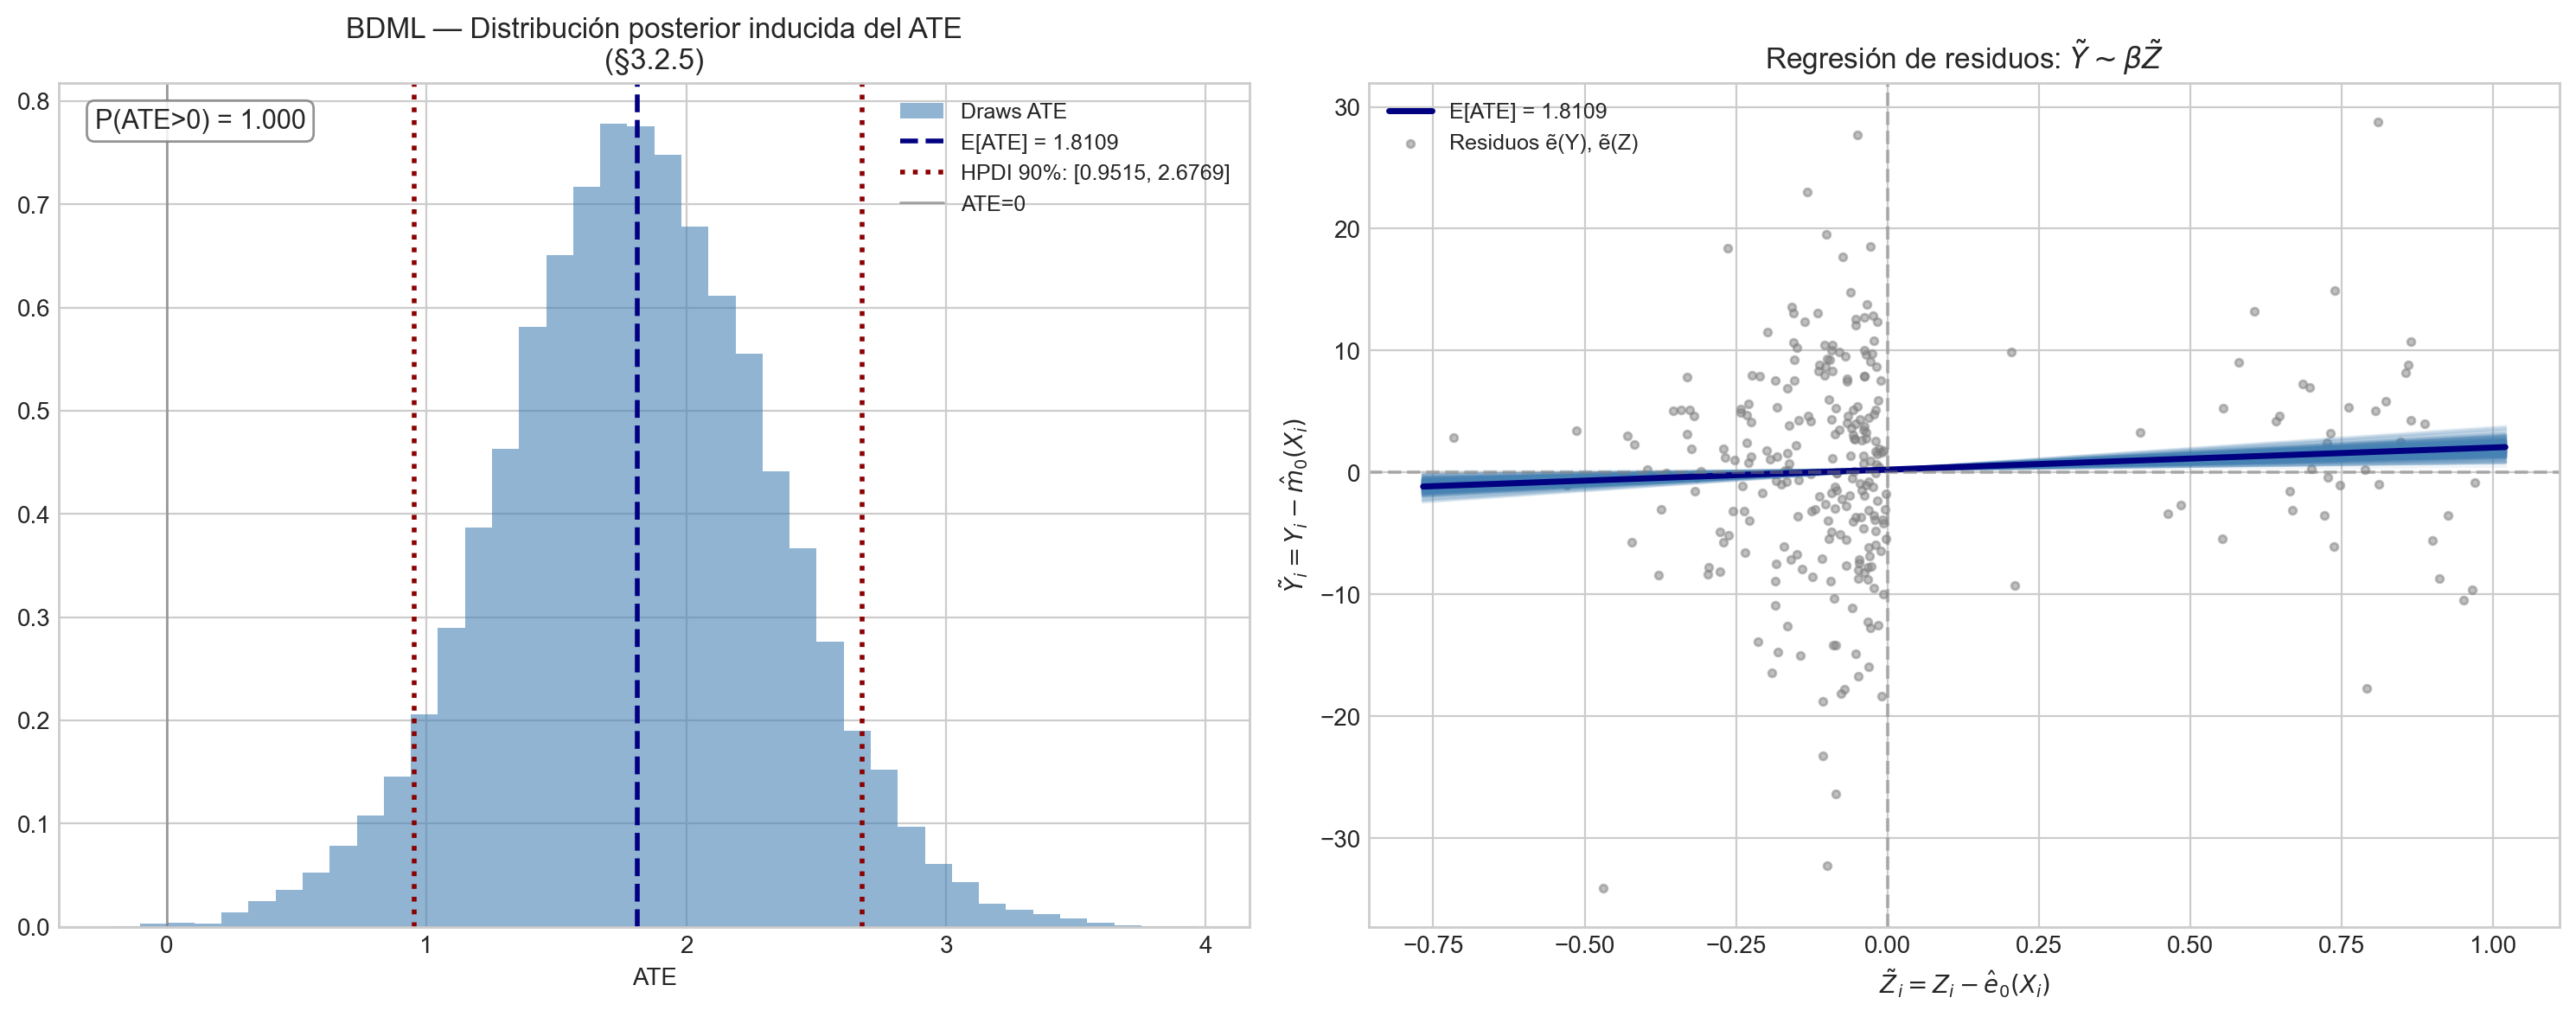

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# Panel izquierdo: posterior del ATE
axs[0].hist(theta_draws, bins=40, density=True, ec="black", alpha=0.6,
            color="steelblue", label="Draws ATE")
axs[0].axvline(ate_mean, ls="--", lw=2, color="navy",
               label=f"E[ATE] = {ate_mean:.4f}")
axs[0].axvline(hpdi_lo,  ls=":",  lw=2, color="darkred",
               label=f"HPDI 90%: [{hpdi_lo:.4f}, {hpdi_hi:.4f}]")
axs[0].axvline(hpdi_hi,  ls=":",  lw=2, color="darkred")
axs[0].axvline(0.0,       ls="-",  lw=1, color="gray", alpha=0.7, label="ATE=0")
axs[0].text(0.03, 0.97, f"P(ATE>0) = {p_pos:.3f}",
            transform=axs[0].transAxes, va="top", ha="left", fontsize=11,
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.85))
axs[0].set_title("BDML — Distribución posterior inducida del ATE\n(§3.2.5)", fontsize=12)
axs[0].set_xlabel("ATE")
axs[0].legend(loc="upper right", fontsize=9)

# Panel derecho: rectas de regresión de residuos por draw
x_range = np.linspace(t_tilde.min() - 0.05, t_tilde.max() + 0.05, 200)
tbar = t_tilde.mean(); ybar = y_tilde.mean()
alpha_draws = ybar - theta_draws * tbar
n_lines = min(400, len(theta_draws))
for i in range(n_lines):
    axs[1].plot(x_range, alpha_draws[i] + theta_draws[i]*x_range, alpha=0.08, color="steelblue")
axs[1].plot(x_range, alpha_draws.mean() + theta_draws.mean()*x_range,
            lw=2.5, color="navy", label=f"E[ATE] = {ate_mean:.4f}")
axs[1].scatter(t_tilde, y_tilde, s=10, alpha=0.5, color="gray", label="Residuos ẽ(Y), ẽ(Z)")
axs[1].axhline(0, ls="--", color="gray", alpha=0.5)
axs[1].axvline(0, ls="--", color="gray", alpha=0.5)
axs[1].set_title(r"Regresión de residuos: $\tilde Y \sim \beta \tilde Z$", fontsize=12)
axs[1].set_xlabel(r"$\tilde Z_i = Z_i - \hat e_0(X_i)$")
axs[1].set_ylabel(r"$\tilde Y_i = Y_i - \hat m_0(X_i)$")
axs[1].legend(fontsize=9)

plt.tight_layout()
save_fig("bdml_ate_posterior_completa")
plt.show()


## Pruebas de validación del modelo BDML

Las siguientes pruebas validan los supuestos y la correcta implementación del estimador BDML (§3.2).


### V1: Balance de residuos (media ≈ 0)

Condición necesaria: $\mathbb{E}[\tilde Y_i] \approx 0$ y $\mathbb{E}[\tilde Z_i] \approx 0$.
Si la media de los residuos es grande, indica que el nuisance correspondiente está mal centrado
(p. ej. por sobreajuste o sesgo en la predicción OOF).


In [12]:
# ── V1: Balance de residuos ────────────────────────────────────────────────────
print("V1: Balance de residuos OOF")
print("-"*45)
print(f"  media(ytilde)   = {y_tilde.mean():.6f}   (debería ≈ 0)")
print(f"  media(ttilde)   = {t_tilde.mean():.6f}   (debería ≈ 0)")
print(f"  std(ytilde)     = {y_tilde.std():.4f}")
print(f"  std(ttilde)     = {t_tilde.std():.4f}")
print()
print("  Estabilidad numérica de ttilde:")
s = res["stability"]
print(f"  |ttilde| Q01={s['ttilde_abs_q01']:.4f}  Q05={s['ttilde_abs_q05']:.4f}  "      f"Q10={s['ttilde_abs_q10']:.4f}  Q50={s['ttilde_abs_q50']:.4f}")
print(f"  Fracción |ttilde|<0.001: {s['share_abs_lt_1e-3']:.4f}  "      f"(debe ser baja para estabilidad numérica)")


V1: Balance de residuos OOF
---------------------------------------------
  media(ytilde)   = 0.240700   (debería ≈ 0)
  media(ttilde)   = 0.002451   (debería ≈ 0)
  std(ytilde)     = 8.6563
  std(ttilde)     = 0.3288

  Estabilidad numérica de ttilde:
  |ttilde| Q01=0.0062  Q05=0.0159  Q10=0.0226  Q50=0.1082
  Fracción |ttilde|<0.001: 0.0000  (debe ser baja para estabilidad numérica)


### V2: Ortogonalidad de Neyman

El score ortogonal (§3.2.6) implica que $\mathrm{Corr}(\tilde Y_i, \tilde Z_i) \approx \theta_0 \cdot \mathrm{Var}(\tilde Z_i) / \mathrm{Var}(\tilde Z_i) = \theta_0$,
y en particular que los residuos de la regresión final de $\tilde Y$ sobre $\tilde Z$ deben ser ortogonales a $\tilde Z$.
Se verifica que la correlación entre los **residuos de la regresión OLS final** y $\tilde Z$ sea ≈ 0.


In [13]:
# ── V2: Ortogonalidad (residuos OLS ⊥ ttilde) ─────────────────────────────────
X_ols_v2   = sm.add_constant(t_tilde)
ols_v2     = sm.OLS(y_tilde, X_ols_v2).fit()
resid_ols  = ols_v2.resid

corr_resid_ttilde = float(np.corrcoef(resid_ols, t_tilde)[0, 1])
print("V2: Ortogonalidad de Neyman")
print("-"*45)
print(f"  Corr(residuos OLS, ttilde) = {corr_resid_ttilde:.8f}  (debe ser ≈ 0 por construcción OLS)")
print(f"  R² de la regresión final   = {ols_v2.rsquared:.4f}")
print()
# Prueba t de la correlación (debería no ser significativa)
n_v2  = len(resid_ols)
t_stat = corr_resid_ttilde * np.sqrt((n_v2-2) / (1 - corr_resid_ttilde**2 + 1e-12))
p_val  = 2 * (1 - stats.t.cdf(abs(t_stat), df=n_v2-2))
print(f"  Test H0: corr=0 → t={t_stat:.4f}, p={p_val:.4f}  (p>0.05 es consistente con ortogonalidad)")


V2: Ortogonalidad de Neyman
---------------------------------------------
  Corr(residuos OLS, ttilde) = -0.00000000  (debe ser ≈ 0 por construcción OLS)
  R² de la regresión final   = 0.0053

  Test H0: corr=0 → t=-0.0000, p=1.0000  (p>0.05 es consistente con ortogonalidad)


### V3: Consistencia fold-by-fold

Variabilidad excesiva entre los $\hat\theta_k$ de cada fold sugiere inestabilidad 
(posiblemente por overlap bajo en algunos folds o insuficiente capacidad predictiva del BART).


V3: Consistencia fold-by-fold
---------------------------------------------
  Fold 1: theta = +4.8013
  Fold 2: theta = -0.4878
  Fold 3: theta = +4.7127
  Fold 4: theta = -1.1036

  Theta apilado     : +1.9188
  Media folds       : +1.9807
  Std folds         : 2.7850
  Max |theta_k - theta_stack|: 3.0224
[guardada] FigurasBDML/bdml_fold_consistency.png  (+ pdf)


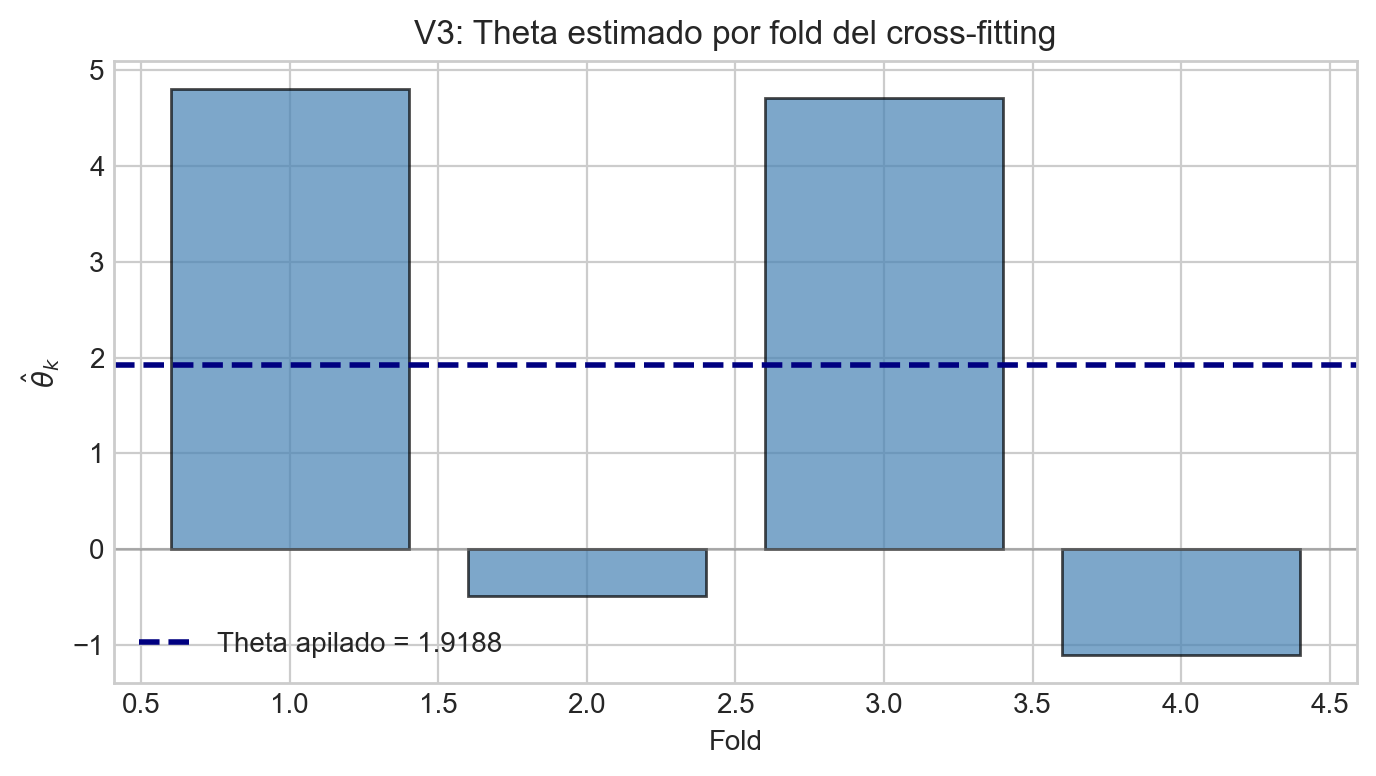

In [14]:
# ── V3: Consistencia fold-by-fold ─────────────────────────────────────────────
theta_folds = res["theta_folds"]
print("V3: Consistencia fold-by-fold")
print("-"*45)
for k, th in enumerate(theta_folds):
    print(f"  Fold {k+1}: theta = {th:+.4f}")
print()
print(f"  Theta apilado     : {res['theta_hat']:+.4f}")
print(f"  Media folds       : {np.mean(theta_folds):+.4f}")
print(f"  Std folds         : {np.std(theta_folds):.4f}")
print(f"  Max |theta_k - theta_stack|: {max(abs(th - res['theta_hat']) for th in theta_folds):.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, len(theta_folds)+1), theta_folds, color="steelblue", alpha=0.7, ec="black")
ax.axhline(res["theta_hat"], ls="--", lw=2, color="navy", label=f"Theta apilado = {res['theta_hat']:.4f}")
ax.axhline(0, ls="-", lw=1, color="gray", alpha=0.5)
ax.set_xlabel("Fold"); ax.set_ylabel(r"$\hat\theta_k$")
ax.set_title("V3: Theta estimado por fold del cross-fitting")
ax.legend(); plt.tight_layout(); save_fig("bdml_fold_consistency"); plt.show()


### V4: Importancia de variables BART

Diagnóstico de plausibilidad del mecanismo aprendido. Se evalúan los árboles del último fold
para identificar qué covariables gobiernan cada nuisance, conforme al enfoque de §3.1.


V4: Importancia de variables BART (muestra completa, modelo auxiliar)
  Re-estimando PS BART auxiliar...


Sequential sampling (2 chains in 1 job)
PGBART: [eta]


Output()

Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 52 seconds.
C:\Users\Leobardo\.conda\envs\zlfn\Lib\site-packages\pytensor\link\numba\dispatch\basic.py:214: UserWarning: Numba will use object mode to run BART_rv{"(m,n),(m),(),(),() -> (m)"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


[guardada] FigurasBDML/bdml_vi_ps_aux.png  (+ pdf)


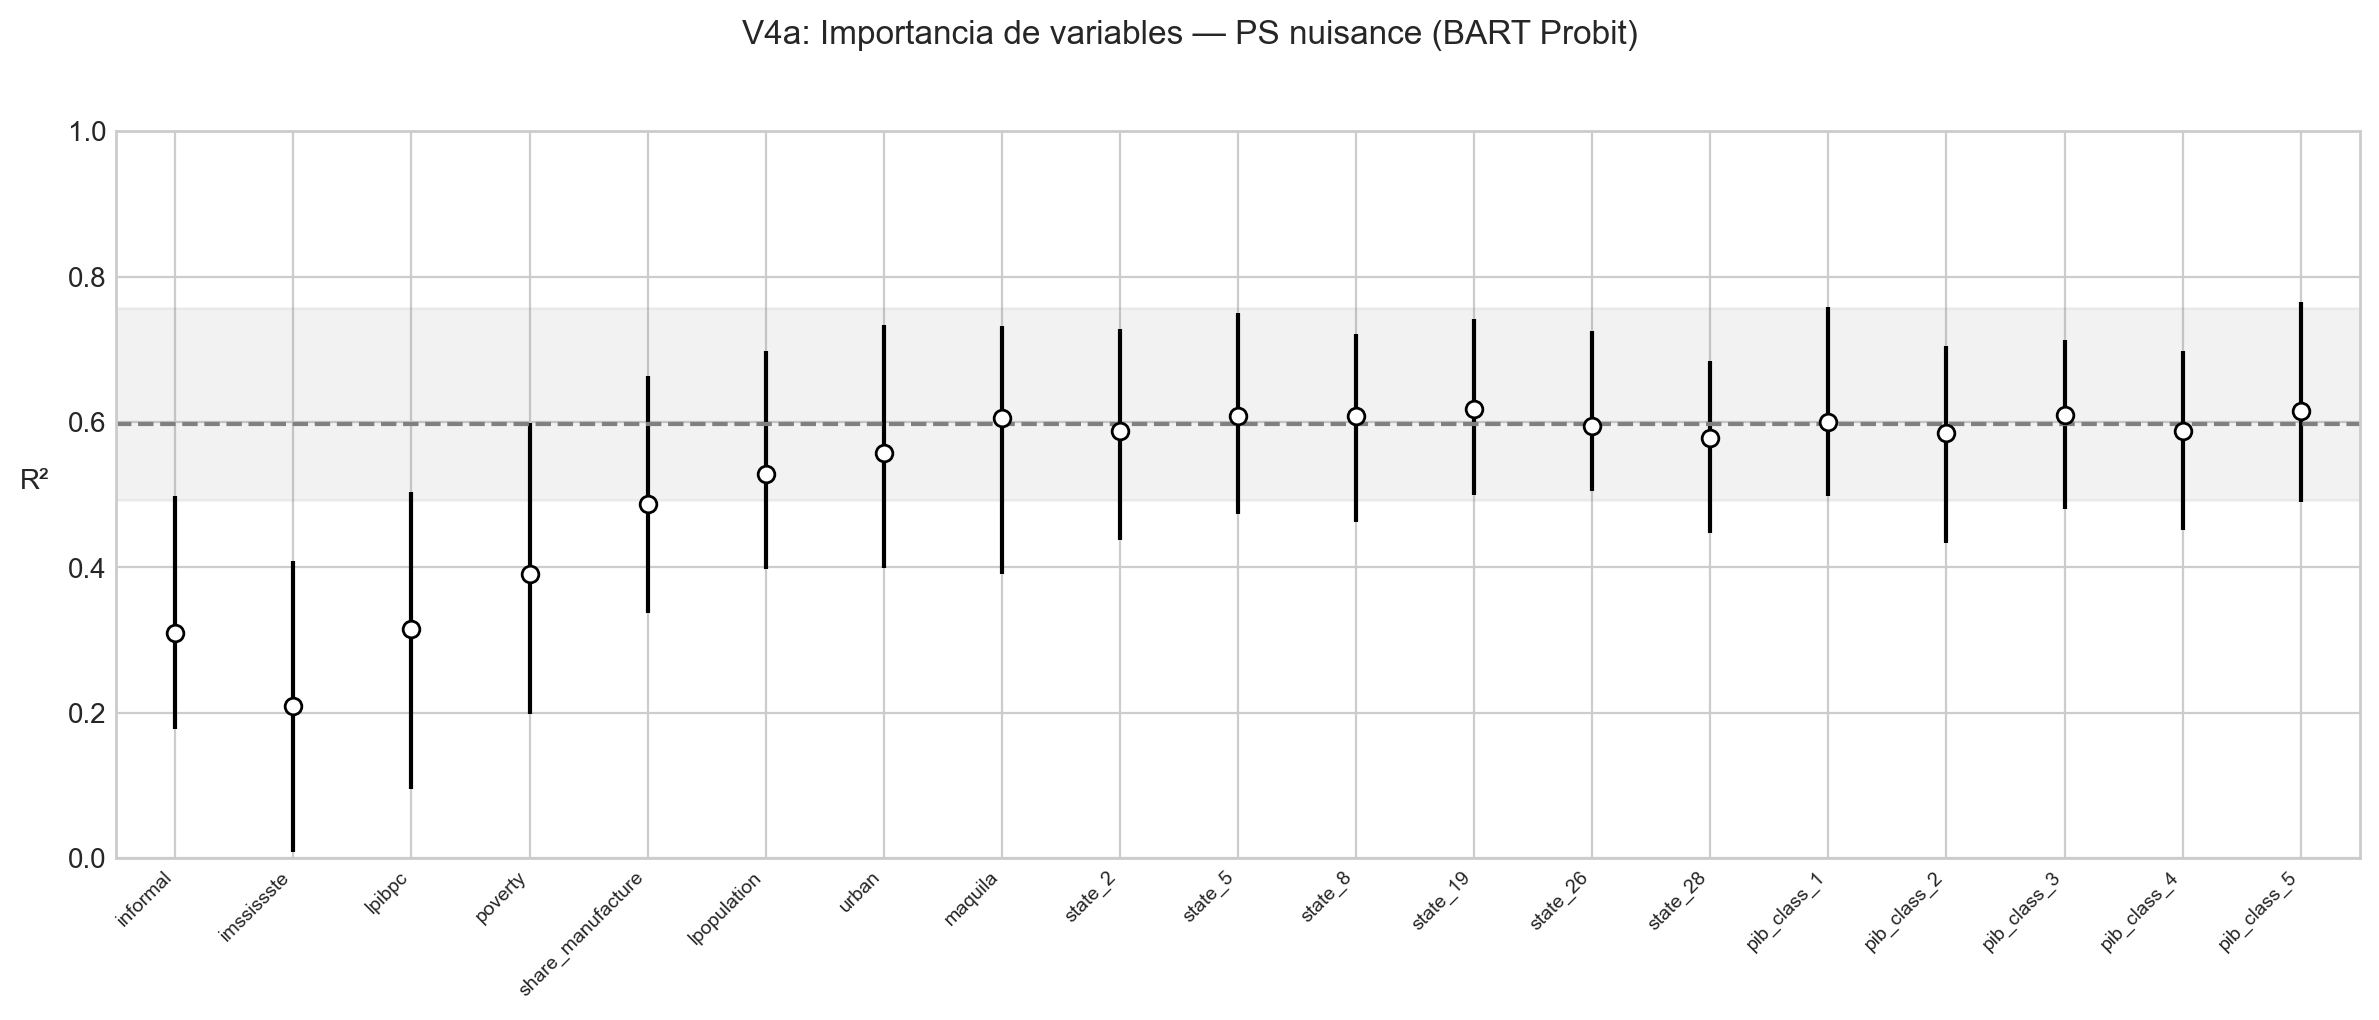

  Re-estimando Outcome BART auxiliar...


Sequential sampling (2 chains in 1 job)
PGBART: [mu]


Output()

Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 46 seconds.
C:\Users\Leobardo\.conda\envs\zlfn\Lib\site-packages\pytensor\link\numba\dispatch\basic.py:214: UserWarning: Numba will use object mode to run BART_rv{"(m,n),(m),(),(),() -> (m)"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


[guardada] FigurasBDML/bdml_vi_outcome_aux.png  (+ pdf)


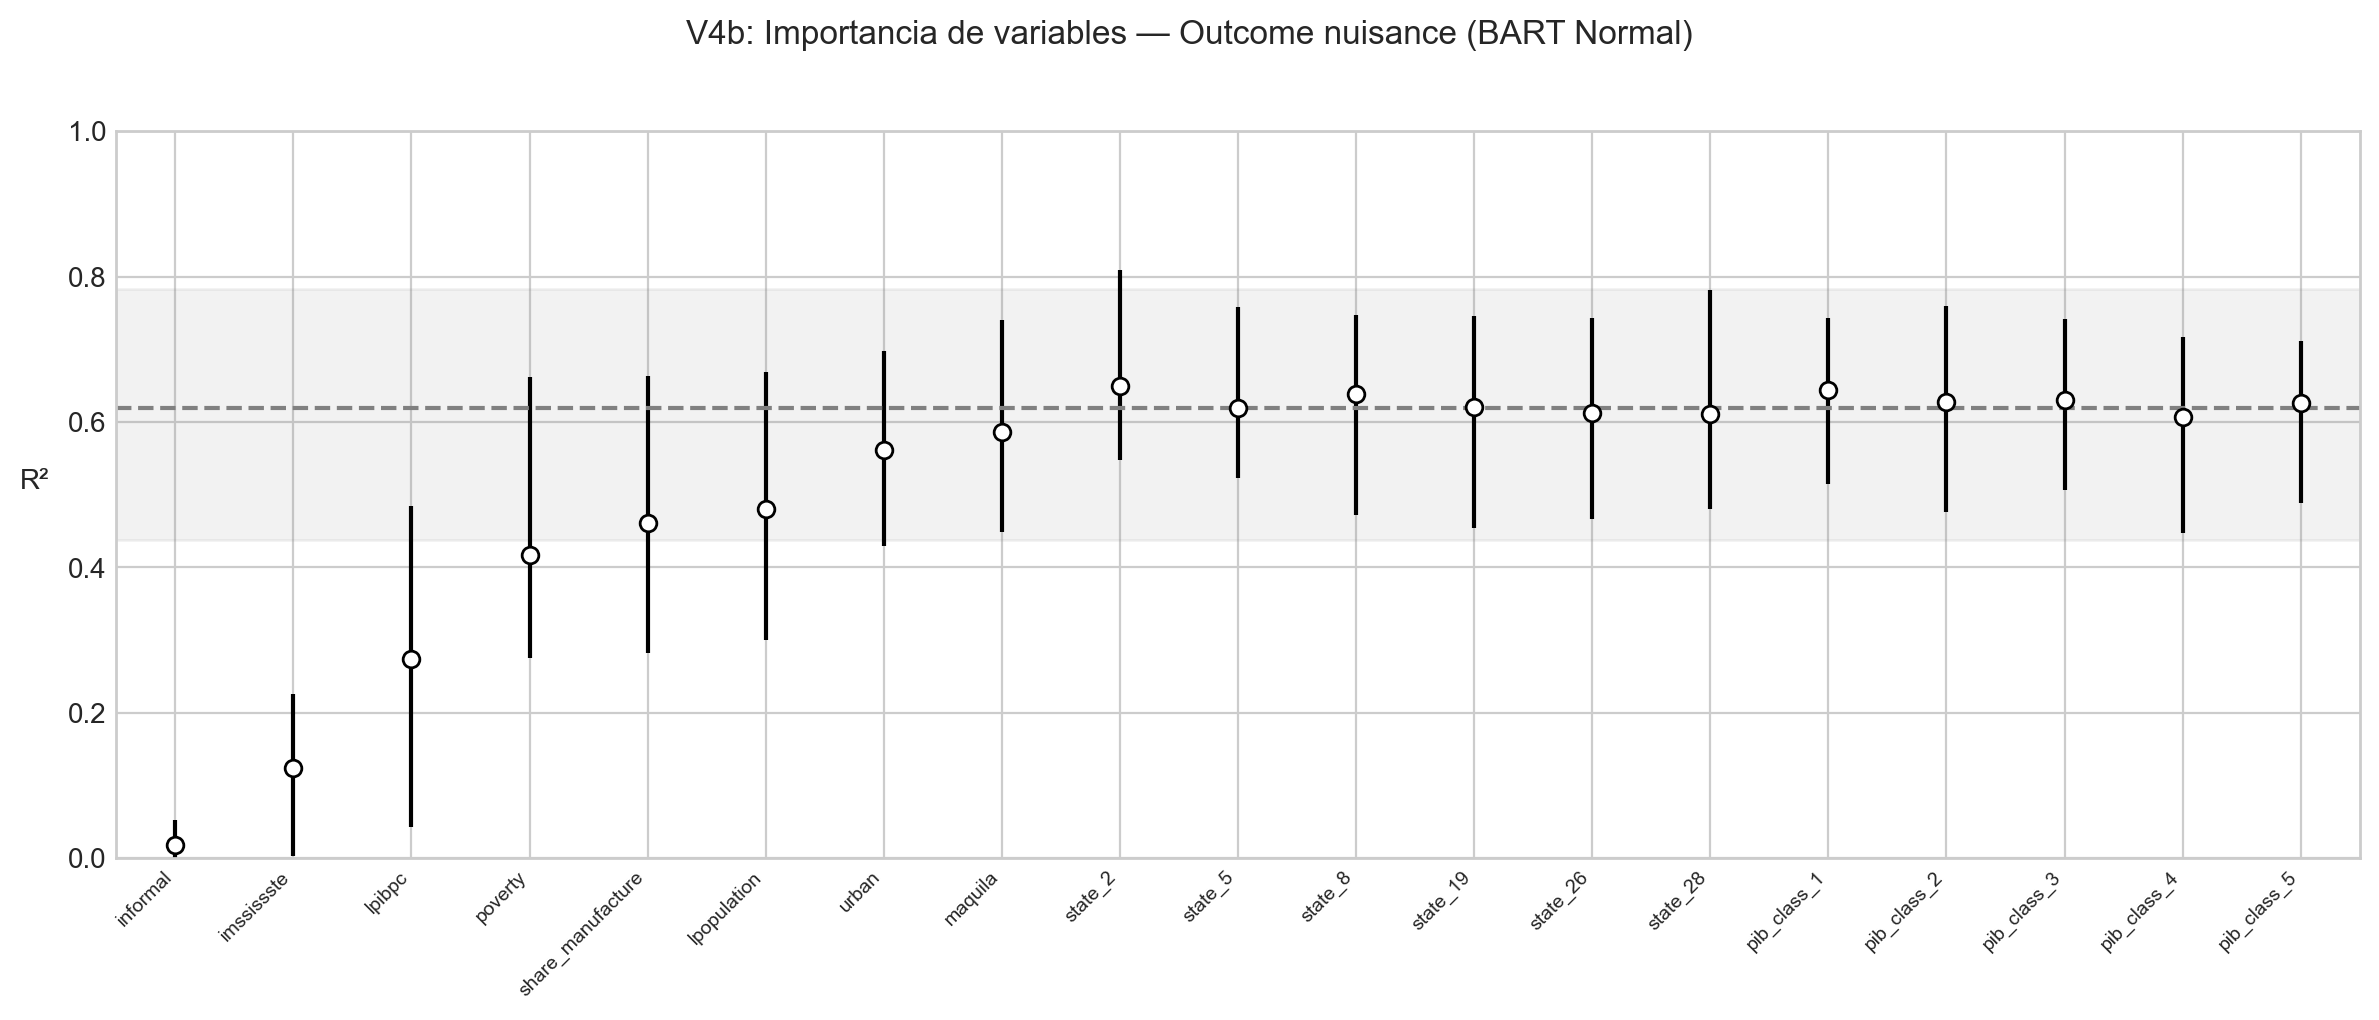

In [15]:
# ── V4: Importancia de variables BART (modelos auxiliares, muestra completa) ──
# Diagnóstico de plausibilidad. Se re-estiman modelos auxiliares con draws reducidos.
print("V4: Importancia de variables BART (muestra completa, modelo auxiliar)")
print("  Re-estimando PS BART auxiliar...")

fix_all_seeds(SEED + 99)
_, idata_ps_aux, eta_aux = fit_ps_bart(
    X.values, t.values, split_rules=SPLIT_RULES,
    m=50, draws=1000, tune=500, chains=2, random_seed=SEED + 99
)
vi_ps = pmb.compute_variable_importance(
    idata_ps_aux, eta_aux, X.values, method="VI", samples=50, random_seed=SEED
)
pmb.plot_variable_importance(vi_ps, labels=ALL_COVS, figsize=(12, 5))
# ── corregir solapamiento de etiquetas ────────────────────────────────────────
for _ax in plt.gcf().get_axes():
    _ax.set_xticklabels(
        [t.get_text() for t in _ax.get_xticklabels()],
        rotation=45, ha="right", fontsize=7
    )
plt.suptitle("V4a: Importancia de variables — PS nuisance (BART Probit)",
             fontsize=12, y=1.01)
plt.tight_layout()
save_fig("bdml_vi_ps_aux"); plt.show()

print("  Re-estimando Outcome BART auxiliar...")
fix_all_seeds(SEED + 100)
_, idata_out_aux, mu_aux = fit_outcome_bart(
    X.values, y.values, split_rules=SPLIT_RULES,
    m=50, draws=1000, tune=500, chains=2, random_seed=SEED + 100
)
vi_out = pmb.compute_variable_importance(
    idata_out_aux, mu_aux, X.values, method="VI", samples=50, random_seed=SEED
)
pmb.plot_variable_importance(vi_out, labels=ALL_COVS, figsize=(12, 5))
# ── corregir solapamiento de etiquetas ────────────────────────────────────────
for _ax in plt.gcf().get_axes():
    _ax.set_xticklabels(
        [t.get_text() for t in _ax.get_xticklabels()],
        rotation=45, ha="right", fontsize=7
    )
plt.suptitle("V4b: Importancia de variables — Outcome nuisance (BART Normal)",
             fontsize=12, y=1.01)
plt.tight_layout()
save_fig("bdml_vi_outcome_aux"); plt.show()


### V5: Convergencia BART (modelos auxiliares)

Análoga a los diagnósticos de §3.1. R̂ y ESS de las variables de árbol dentro de los modelos auxiliares.


V5a: Convergencia PS BART auxiliar (p = Φ(η))
[guardada] FigurasBDML/bdml_convergence_ps.png  (+ pdf)


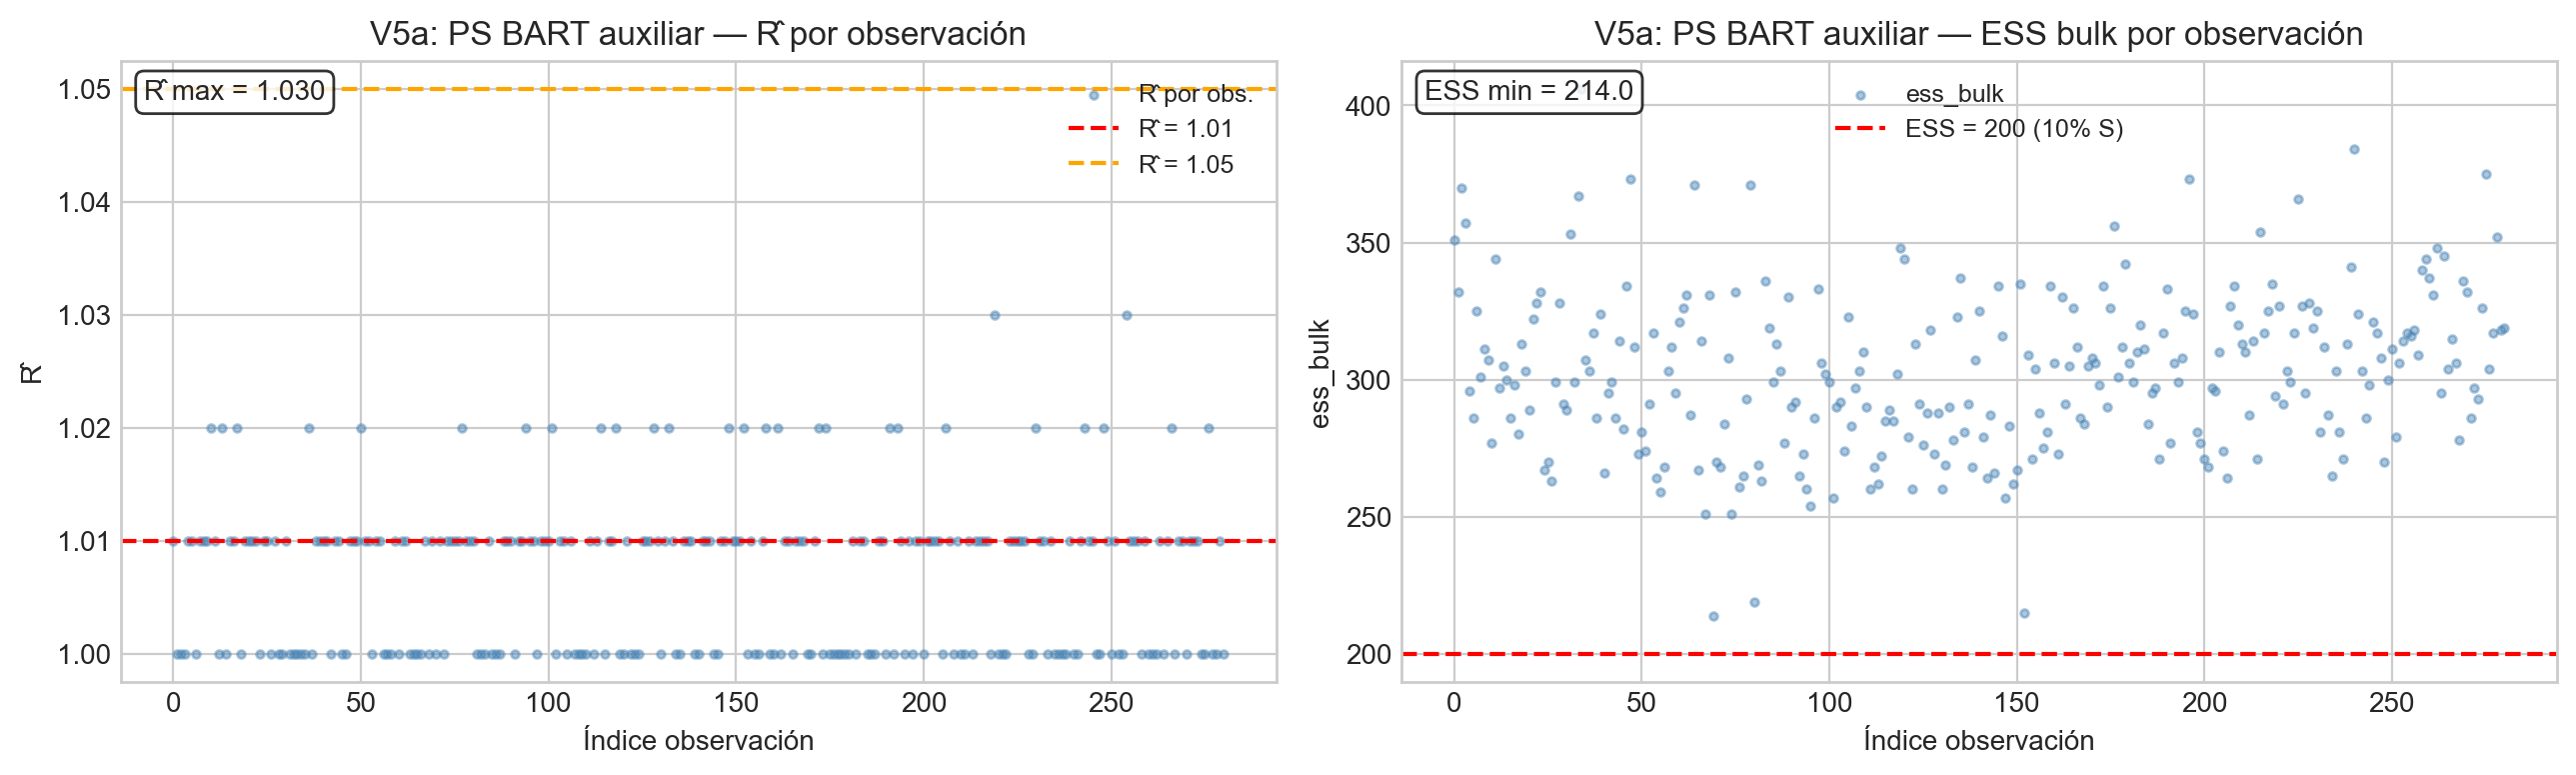

  R̂ max: 1.030  |  ESS bulk min: 214.0
V5b: Convergencia Outcome BART auxiliar (mu)
[guardada] FigurasBDML/bdml_convergence_outcome.png  (+ pdf)


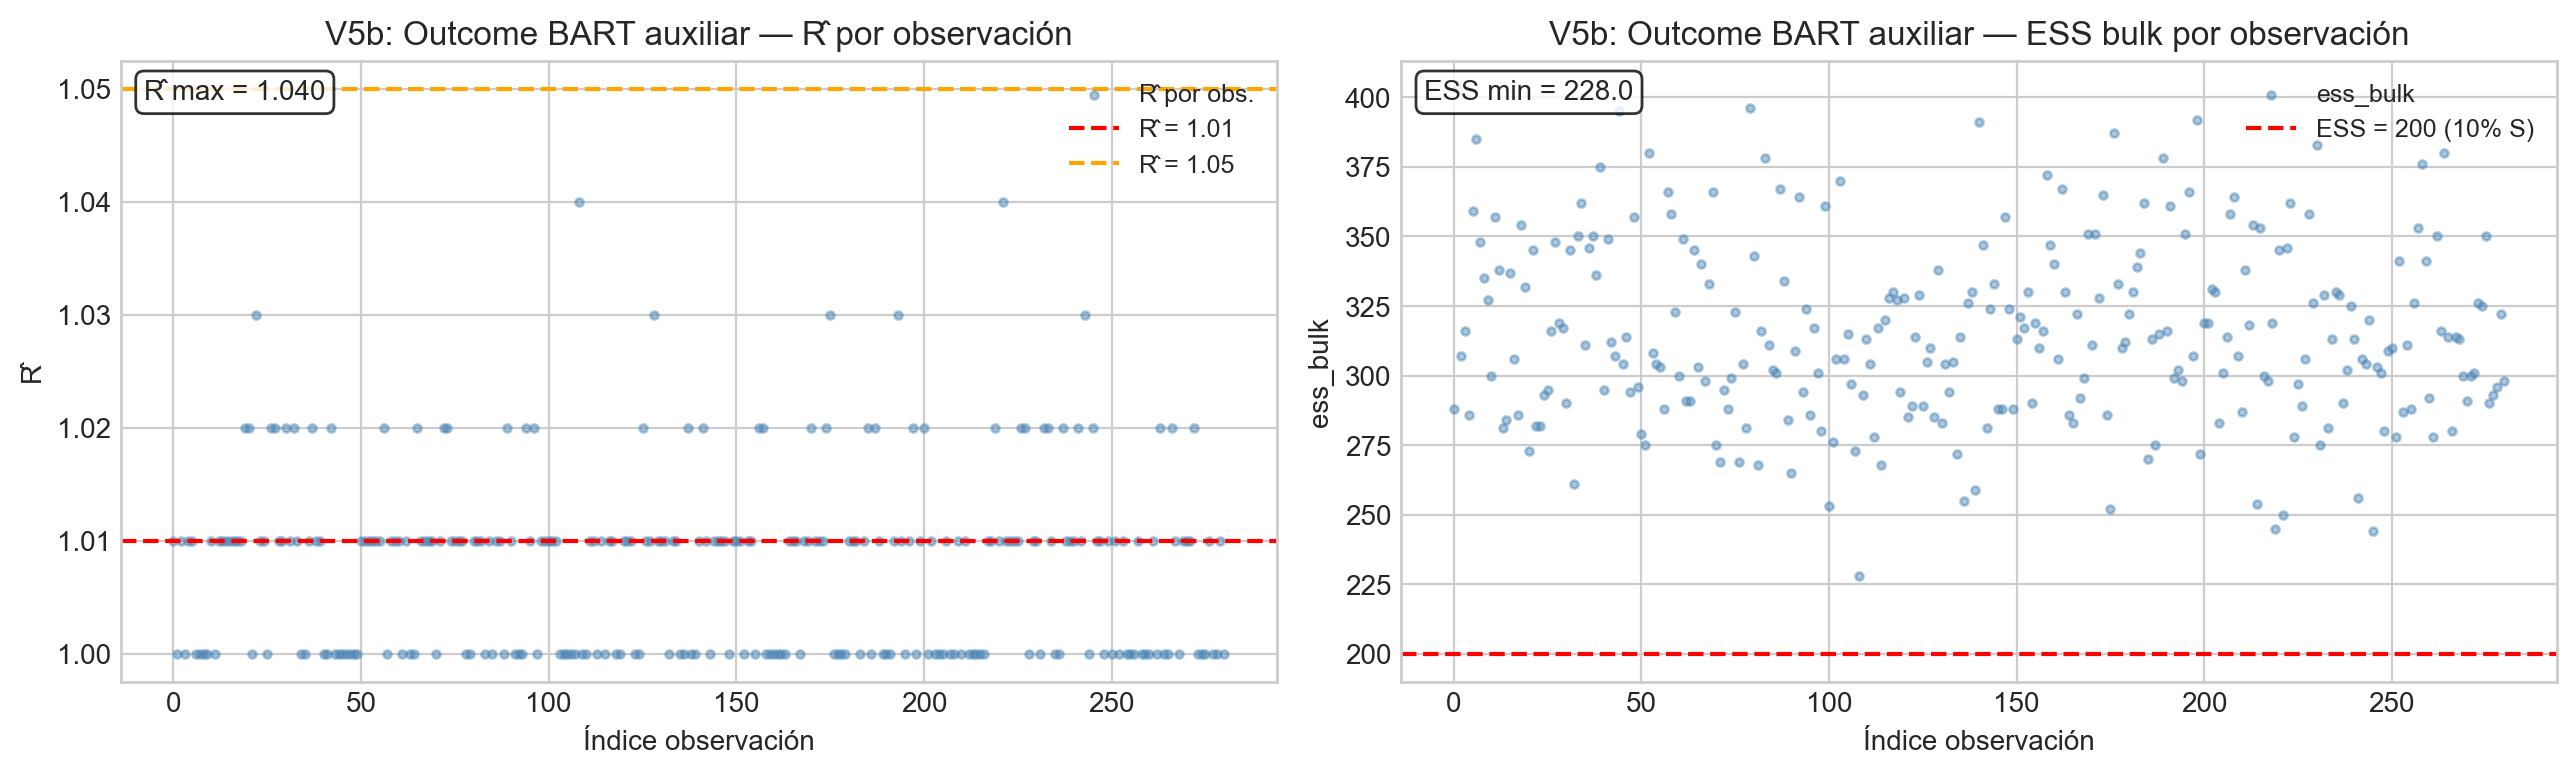

  R̂ max: 1.040  |  ESS bulk min: 228.0

Diagnósticos PS BART auxiliar — p = Φ(η):
  R̂ max: 1.0300  |  ESS bulk min: 214.0  |  ESS bulk mean: 302.4

Diagnósticos Outcome BART auxiliar — mu:
  R̂ max: 1.0400  |  ESS bulk min: 228.0  |  ESS bulk mean: 315.0


In [16]:
# ── V5: Convergencia BART — diagnósticos con arviz ───────────────────────────
# pmb.plot_convergence está deprecada en pymc-bart 0.12 y produce gráficas vacías.
# Se reemplaza con scatter plots de R̂ y ESS por observación (arviz puro).
# Corrección: pd.to_numeric(..., errors='coerce') para evitar ValueError
# cuando az.summary devuelve columnas con dtype 'object' en arviz 1.x.

def _plot_bart_rhat_ess(idata, var_name: str, title_prefix: str, save_name: str):
    """
    Muestra R̂ y ESS bulk por unidad observacional para un BART.
    Reemplaza pmb.plot_convergence (deprecada en pymc-bart 0.12).
    Fuente: az.summary → columnas r_hat y ess_bulk.
    """
    _sum = az.summary(idata, var_names=[var_name])
    n_chains = len(idata.posterior.chain)
    n_draws  = len(idata.posterior.draw)

    # ── Conversión segura a numérico: en arviz 1.x las columnas pueden tener
    #    dtype 'object' con NaN representados como strings, lo que produce
    #    ValueError: Unknown format code 'f' for object of type 'str'
    for _col in _sum.columns:
        _sum[_col] = pd.to_numeric(_sum[_col], errors="coerce")

    # Detectar columna ESS bulk (nombre varía según versión de arviz)
    ess_col = next((c for c in _sum.columns
                    if c.startswith("ess") and "bulk" in c), None)
    if ess_col is None:
        ess_col = next((c for c in _sum.columns if c.startswith("ess")), None)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # ── Panel izquierdo: R̂ ──────────────────────────────────────────────────
    rhat_vals = _sum["r_hat"].values.astype(float)
    rhat_max  = float(np.nanmax(rhat_vals))
    rhat_str  = f"{rhat_max:.3f}" if not np.isnan(rhat_max) else "N/A"

    axes[0].scatter(range(len(_sum)), rhat_vals,
                    s=8, alpha=0.45, color="steelblue", label="R̂ por obs.")
    axes[0].axhline(1.01, color="red",    ls="--", lw=1.5, label="R̂ = 1.01")
    axes[0].axhline(1.05, color="orange", ls="--", lw=1.5, label="R̂ = 1.05")
    axes[0].set_title(f"{title_prefix} — R̂ por observación")
    axes[0].set_xlabel("Índice observación"); axes[0].set_ylabel("R̂")
    axes[0].legend(fontsize=9)
    axes[0].text(0.02, 0.97, f"R̂ max = {rhat_str}",
                 transform=axes[0].transAxes, va="top", fontsize=10,
                 bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

    # ── Panel derecho: ESS bulk ──────────────────────────────────────────────
    if ess_col:
        ess_vals = _sum[ess_col].values.astype(float)
        ess_min  = float(np.nanmin(ess_vals))
        ess_str  = f"{ess_min:.1f}" if not np.isnan(ess_min) else "N/A"
        thresh   = n_chains * n_draws * 0.10

        axes[1].scatter(range(len(_sum)), ess_vals,
                        s=8, alpha=0.45, color="steelblue", label=ess_col)
        axes[1].axhline(thresh, color="red", ls="--", lw=1.5,
                        label=f"ESS = {thresh:.0f} (10% S)")
        axes[1].set_title(f"{title_prefix} — ESS bulk por observación")
        axes[1].set_xlabel("Índice observación"); axes[1].set_ylabel(ess_col)
        axes[1].legend(fontsize=9)
        axes[1].text(0.02, 0.97, f"ESS min = {ess_str}",
                     transform=axes[1].transAxes, va="top", fontsize=10,
                     bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    else:
        axes[1].set_visible(False)

    plt.tight_layout()
    save_fig(save_name)
    plt.show()
    diag_str = f"R̂ max: {rhat_str}"
    if ess_col:
        diag_str += f"  |  ESS bulk min: {ess_str}"
    print(f"  {diag_str}")


print("V5a: Convergencia PS BART auxiliar (p = Φ(η))")
_plot_bart_rhat_ess(idata_ps_aux,  "p",  "V5a: PS BART auxiliar",  "bdml_convergence_ps")

print("V5b: Convergencia Outcome BART auxiliar (mu)")
_plot_bart_rhat_ess(idata_out_aux, "mu", "V5b: Outcome BART auxiliar", "bdml_convergence_outcome")

# ── Tabla resumen de diagnósticos ────────────────────────────────────────────
sum_ps  = az.summary(idata_ps_aux,  var_names=["p"])
sum_out = az.summary(idata_out_aux, var_names=["mu"])
for _s in (sum_ps, sum_out):
    for _col in _s.columns:
        _s[_col] = pd.to_numeric(_s[_col], errors="coerce")
ess_col = next((c for c in sum_ps.columns if c.startswith("ess") and "bulk" in c), "ess_bulk")

print("\nDiagnósticos PS BART auxiliar — p = Φ(η):")
print(f"  R̂ max: {float(np.nanmax(sum_ps['r_hat'].values)):.4f}  |  "      f"ESS bulk min: {float(np.nanmin(sum_ps[ess_col].values)):.1f}  |  "      f"ESS bulk mean: {float(np.nanmean(sum_ps[ess_col].values)):.1f}")

print("\nDiagnósticos Outcome BART auxiliar — mu:")
print(f"  R̂ max: {float(np.nanmax(sum_out['r_hat'].values)):.4f}  |  "      f"ESS bulk min: {float(np.nanmin(sum_out[ess_col].values)):.1f}  |  "      f"ESS bulk mean: {float(np.nanmean(sum_out[ess_col].values)):.1f}")


### V6: Placebo test (permutación del outcome)

Si el modelo funciona correctamente, al permutar aleatoriamente el outcome el ATE estimado 
debería colapsar a ≈ 0 y la distribución posterior inducida debería cruzar 0 con alta probabilidad.


V6: Placebo test — permutación del outcome

  FOLD 1/4  |  train=210,  test=71
  [Fold 1] Estimando PS nuisance (BART Probit)...


Sequential sampling (4 chains in 1 job)
PGBART: [eta]


Output()

Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 328 seconds.
Sequential sampling (4 chains in 1 job)


  [Fold 1] Estimando outcome nuisance (BART Normal)...


...

Output()

Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 326 seconds.


  [Fold 4] theta_fold = -1.439232

Resultado Placebo:
  E[ATE] placebo  = 2.1267  (esperado ≈ 0)
  HPDI 90%        = [1.4262, 2.8198]  (debe cruzar 0)
  P(ATE>0) plac.  = 1.0000  (esperado ≈ 0.5)


C:\Users\Leobardo\AppData\Local\Temp\ipykernel_9008\2420398248.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[1].boxplot([theta_draws, res_placebo["theta_draws"]],


[guardada] FigurasBDML/bdml_placebo_test.png  (+ pdf)


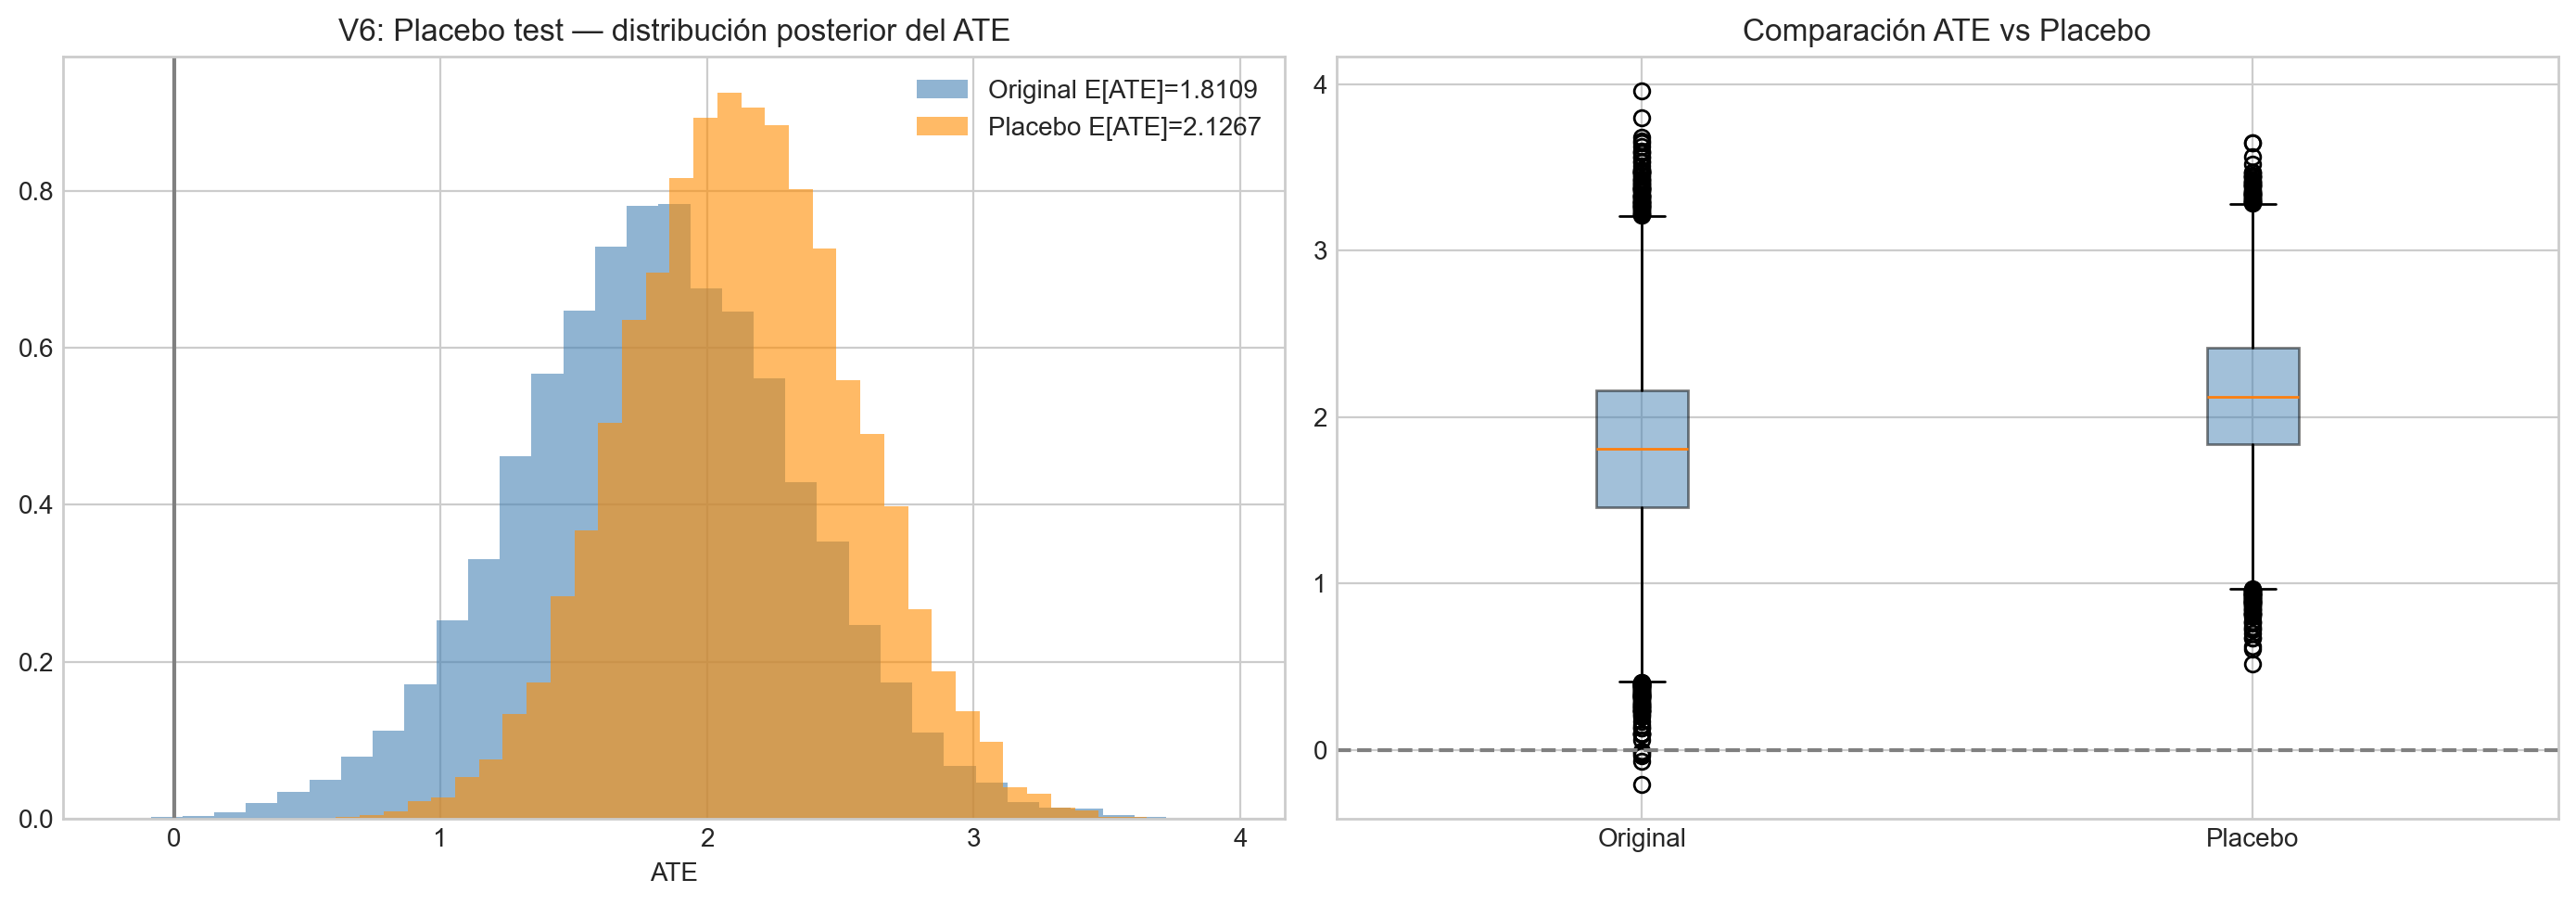

In [17]:
# ── V6: Placebo test ─────────────────────────────────────────────────────────
print("V6: Placebo test — permutación del outcome")
rng_placebo = np.random.default_rng(SEED + 2025)
y_placebo   = pd.Series(rng_placebo.permutation(y.values), name="outcome_placebo")

fix_all_seeds(SEED + 2025)
res_placebo = dml_crossfit_bayesian_bart(
    X, t, y_placebo,
    split_rules=SPLIT_RULES,
    K=4, stratify_t=True, m_outcome=50, m_ps=50,
    draws=4000, tune=1000, chains=4, p_clip=1e-3,
    random_seed=SEED + 2025
)

ate_placebo  = np.mean(res_placebo["theta_draws"])
p_pos_plac   = float(np.mean(res_placebo["theta_draws"] > 0))
hpdi_lo_plac, hpdi_hi_plac = hpdi_from_samples(res_placebo["theta_draws"], 0.90)

print("\nResultado Placebo:")
print(f"  E[ATE] placebo  = {ate_placebo:.4f}  (esperado ≈ 0)")
print(f"  HPDI 90%        = [{hpdi_lo_plac:.4f}, {hpdi_hi_plac:.4f}]  (debe cruzar 0)")
print(f"  P(ATE>0) plac.  = {p_pos_plac:.4f}  (esperado ≈ 0.5)")

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].hist(theta_draws,                bins=35, density=True, alpha=0.6,
            color="steelblue", ec="black", label=f"Original E[ATE]={ate_mean:.4f}")
axs[0].hist(res_placebo["theta_draws"], bins=35, density=True, alpha=0.6,
            color="darkorange", ec="black", label=f"Placebo E[ATE]={ate_placebo:.4f}")
axs[0].axvline(0, ls="-", color="gray")
axs[0].set_title("V6: Placebo test — distribución posterior del ATE")
axs[0].set_xlabel("ATE"); axs[0].legend()

axs[1].boxplot([theta_draws, res_placebo["theta_draws"]],
               labels=["Original", "Placebo"], patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.5))
axs[1].axhline(0, ls="--", color="gray"); axs[1].set_title("Comparación ATE vs Placebo")
plt.tight_layout(); save_fig("bdml_placebo_test"); plt.show()


### V7: Análisis de sensibilidad — E-value

Diagnóstico de robustez frente a confusión no medida, análogo al de §3.1.
El E-value (VanderWeele y Ding, 2017) mide la mínima fuerza de asociación que un confusor no medido
tendría que tener simultáneamente con el tratamiento y el outcome para explicar completamente el efecto.
Se calcula sobre la distribución posterior inducida del ATE para obtener un E-value por draw.


V7: E-value (sensibilidad a confusión no medida)
--------------------------------------------------
  sd(Y)                         = 9.5144
  E-value del estimado puntual  = 1.6633
  E-value límite HPDI 90% (→0)  = 1.4183
  Interpretación: un confusor omitido necesitaría una asociación RR≥1.66
  simultáneamente con tratamiento y outcome para explicar el efecto estimado.

[guardada] FigurasBDML/bdml_evalue.png  (+ pdf)


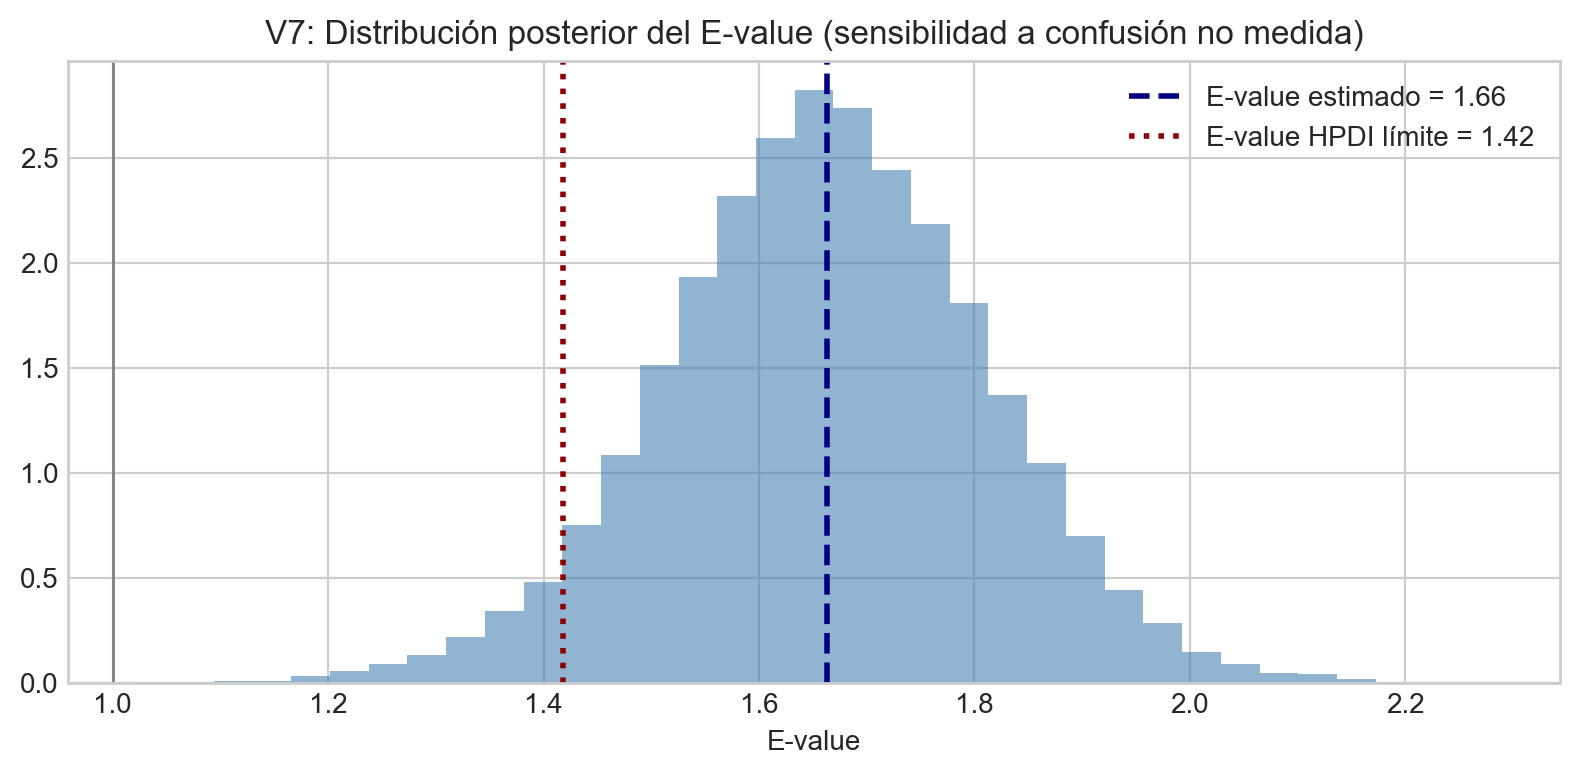

In [18]:
# ── V7: E-value sobre la distribución posterior inducida del ATE ───────────────
# Conversión ATE continuo → RR aproximado (Hasselblad y Hedges, 1995)
# d = ATE / std(Y_obs)  →  RR ≈ exp(0.91 * d)  →  E = RR + sqrt(RR*(RR-1))
sy = float(y.std())

def evalue_from_ate(ate_val: float, sd_y: float) -> float:
    d = ate_val / sd_y
    rr = np.exp(0.91 * d)
    if rr < 1:
        rr = 1.0 / rr         # usar siempre RR > 1
    if rr <= 1:
        return 1.0
    return float(rr + np.sqrt(rr * (rr - 1.0)))

evalues_draws = np.array([evalue_from_ate(th, sy) for th in theta_draws])
ev_mean  = evalue_from_ate(ate_mean, sy)
# E-value del límite del HPDI 90% más cercano a 0
if abs(hpdi_lo) < abs(hpdi_hi):
    ev_hpdi_limit = evalue_from_ate(hpdi_lo, sy) if hpdi_lo != 0 else 1.0
else:
    ev_hpdi_limit = evalue_from_ate(hpdi_hi, sy) if hpdi_hi != 0 else 1.0

print("V7: E-value (sensibilidad a confusión no medida)")
print("-"*50)
print(f"  sd(Y)                         = {sy:.4f}")
print(f"  E-value del estimado puntual  = {ev_mean:.4f}")
print(f"  E-value límite HPDI 90% (→0)  = {ev_hpdi_limit:.4f}")
print(f"  Interpretación: un confusor omitido necesitaría una asociación RR≥{ev_mean:.2f}")
print(f"  simultáneamente con tratamiento y outcome para explicar el efecto estimado.")
print()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(evalues_draws, bins=35, density=True, alpha=0.6, ec="black", color="steelblue")
ax.axvline(ev_mean,        ls="--", lw=2, color="navy",    label=f"E-value estimado = {ev_mean:.2f}")
ax.axvline(ev_hpdi_limit,  ls=":",  lw=2, color="darkred", label=f"E-value HPDI límite = {ev_hpdi_limit:.2f}")
ax.axvline(1.0,            ls="-",  lw=1, color="gray")
ax.set_title("V7: Distribución posterior del E-value (sensibilidad a confusión no medida)")
ax.set_xlabel("E-value"); ax.legend()
plt.tight_layout(); save_fig("bdml_evalue"); plt.show()


## CATE mediante R-learner (§3.2.7)

El R-learner (Nie y Wager, 2021) extiende la ortogonalización de Robinson al CATE (§3.2.7):

$$\hat\tau(\cdot) = \arg\min_{\tau\in\mathcal{F}} \frac{1}{n}\sum_i \tilde Z_i^2 \left(\frac{\tilde Y_i}{\tilde Z_i} - \tau(X_i)\right)^2$$

donde el pseudo-outcome estabilizado es $R_i^{(\epsilon)} = \tilde Y_i / (\tilde Z_i + \epsilon\,\mathrm{sign}(\tilde Z_i))$
(ecuación 3.2.15 de la tesis). Con incertidumbre bayesiana propagada desde los draws posteriores
$(\tilde Y^{(s)}, \tilde Z^{(s)})$, se obtiene una distribución de predicciones CATE.


In [19]:
def fit_cate_rlearner(
    X: pd.DataFrame,
    t: pd.Series,
    y_tilde: np.ndarray,
    t_tilde: np.ndarray,
    method: str = "forest",
    eps: float = 1e-6,
    random_state: int = 123,
) -> tuple:
    """
    R-learner puntual (§3.2.7).

    Target (pseudo-outcome estabilizado, ec. 3.2.15):
        R_i^(eps) = ytilde_i / (ttilde_i + eps * sign(ttilde_i))
    Pesos: w_i = ttilde_i^2

    method in {"forest", "gboost", "ridge"}
    """
    X = pd.DataFrame(X).reset_index(drop=True)
    t = pd.Series(t).reset_index(drop=True).astype(int)
    y_tilde = np.asarray(y_tilde, dtype=float)
    t_tilde = np.asarray(t_tilde, dtype=float)

    denom  = t_tilde + eps * np.where(t_tilde == 0, 1, np.sign(t_tilde))
    target = y_tilde / denom
    weights = t_tilde**2

    if method == "forest":
        model = RandomForestRegressor(
            n_estimators=500, min_samples_leaf=10,
            random_state=random_state, n_jobs=-1
        )
    elif method == "gboost":
        model = GradientBoostingRegressor(random_state=random_state)
    else:
        model = Ridge(alpha=1.0)

    model.fit(X, target, sample_weight=weights)
    tau_hat = model.predict(X)

    df = X.copy()
    df["t"] = t.values
    df["tau_hat"] = tau_hat
    return df, model


def fit_cate_rlearner_bayes(
    X: pd.DataFrame,
    t: pd.Series,
    res: dict,
    method: str = "forest",
    eps: float = 1e-6,
    random_state: int = 123,
    n_draws: int = None,
) -> dict:
    """
    R-learner con propagación de incertidumbre bayesiana (§3.2.7).

    Itera sobre los draws posteriores (ytilde^(s), ttilde^(s)) del BDML
    para obtener una distribución de predicciones CATE tau^(s)(X).

    Retorna
    -------
    dict con tau_draws (S, n), tau_mean, tau_lower, tau_upper, df_mean.
    """
    ytilde_full = res.get("ytilde_full")
    ttilde_full = res.get("ttilde_full")
    if ytilde_full is None or ttilde_full is None:
        raise ValueError("res debe contener 'ytilde_full' y 'ttilde_full'.")

    S = ytilde_full.shape[0]
    if n_draws is not None:
        S = min(n_draws, S)

    X = pd.DataFrame(X).reset_index(drop=True)
    t = pd.Series(t).reset_index(drop=True).astype(int)
    n = len(X)
    tau_draws = np.zeros((S, n), dtype=float)

    for s in range(S):
        df_s, _ = fit_cate_rlearner(
            X, t, ytilde_full[s], ttilde_full[s],
            method=method, eps=eps, random_state=random_state + s
        )
        tau_draws[s] = df_s["tau_hat"].values

    tau_mean  = tau_draws.mean(axis=0)
    tau_lower = np.percentile(tau_draws, 2.5, axis=0)
    tau_upper = np.percentile(tau_draws, 97.5, axis=0)

    df_mean = X.copy()
    df_mean["t"]         = t.values
    df_mean["tau_mean"]  = tau_mean
    df_mean["tau_lower"] = tau_lower
    df_mean["tau_upper"] = tau_upper

    return {
        "tau_draws" : tau_draws,
        "tau_mean"  : tau_mean,
        "tau_lower" : tau_lower,
        "tau_upper" : tau_upper,
        "df_mean"   : df_mean,
    }


In [20]:
# ── Ajuste CATE con propagación bayesiana ─────────────────────────────────────
cate_bayes = fit_cate_rlearner_bayes(
    X=X, t=t, res=res, method="forest",
    n_draws=200,  # subconjunto para costo computacional razonable
    random_state=SEED
)

# Distribución posterior del ATE implícito (media de CATE)
ate_from_cate = cate_bayes["tau_draws"].mean(axis=1)
p_pos_cate    = float(np.mean(ate_from_cate > 0))
hpdi_lo_c, hpdi_hi_c = hpdi_from_samples(ate_from_cate, 0.90)

print("CATE vía R-learner — ATE implícito (§3.2.7)")
print(f"  E[ATE implícito]  = {ate_from_cate.mean():.4f}")
print(f"  HPDI 90%          = [{hpdi_lo_c:.4f}, {hpdi_hi_c:.4f}]")
print(f"  P(ATE_imp > 0)    = {p_pos_cate:.4f}")


CATE vía R-learner — ATE implícito (§3.2.7)
  E[ATE implícito]  = -0.8872
  HPDI 90%          = [-2.2982, 0.5199]
  P(ATE_imp > 0)    = 0.1550


[guardada] FigurasBDML/bdml_cate_posterior.png  (+ pdf)


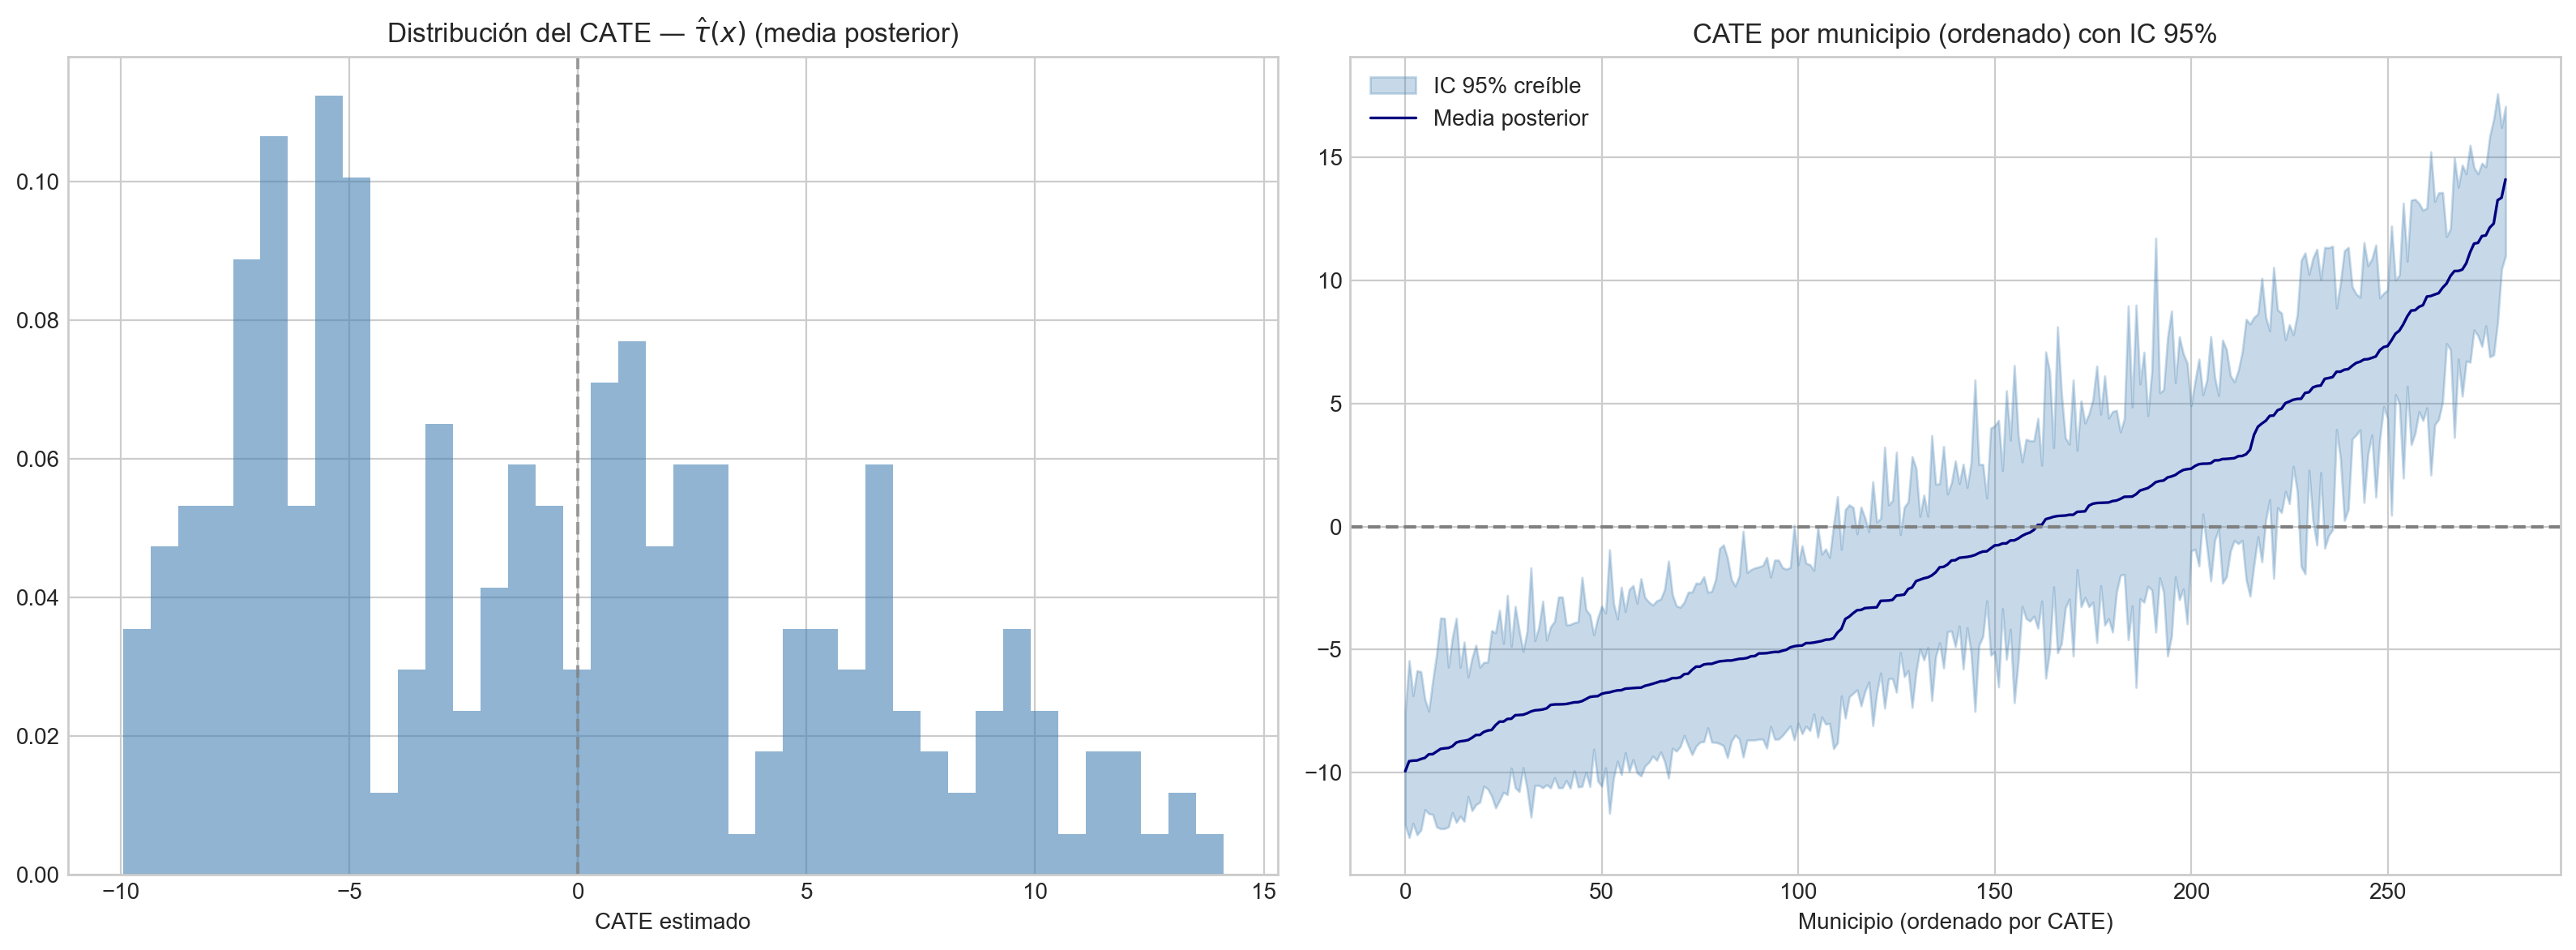

In [21]:
# ── Visualización CATE con incertidumbre ──────────────────────────────────────
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

axs[0].hist(cate_bayes["tau_mean"], bins=40, density=True, alpha=0.6,
            ec="black", color="steelblue")
axs[0].axvline(0, ls="--", color="gray", alpha=0.7)
axs[0].set_title(r"Distribución del CATE — $\hat\tau(x)$ (media posterior)")
axs[0].set_xlabel("CATE estimado")

order = np.argsort(cate_bayes["tau_mean"])
idx   = np.arange(len(order))
axs[1].fill_between(idx, cate_bayes["tau_lower"][order], cate_bayes["tau_upper"][order],
                    alpha=0.3, color="steelblue", label="IC 95% creíble")
axs[1].plot(idx, cate_bayes["tau_mean"][order], lw=1.2, color="navy", label="Media posterior")
axs[1].axhline(0, ls="--", color="gray")
axs[1].set_title("CATE por municipio (ordenado) con IC 95%")
axs[1].set_xlabel("Municipio (ordenado por CATE)")
axs[1].legend()

plt.tight_layout(); save_fig("bdml_cate_posterior"); plt.show()


[guardada] FigurasBDML/bdml_cate_tails.png  (+ pdf)


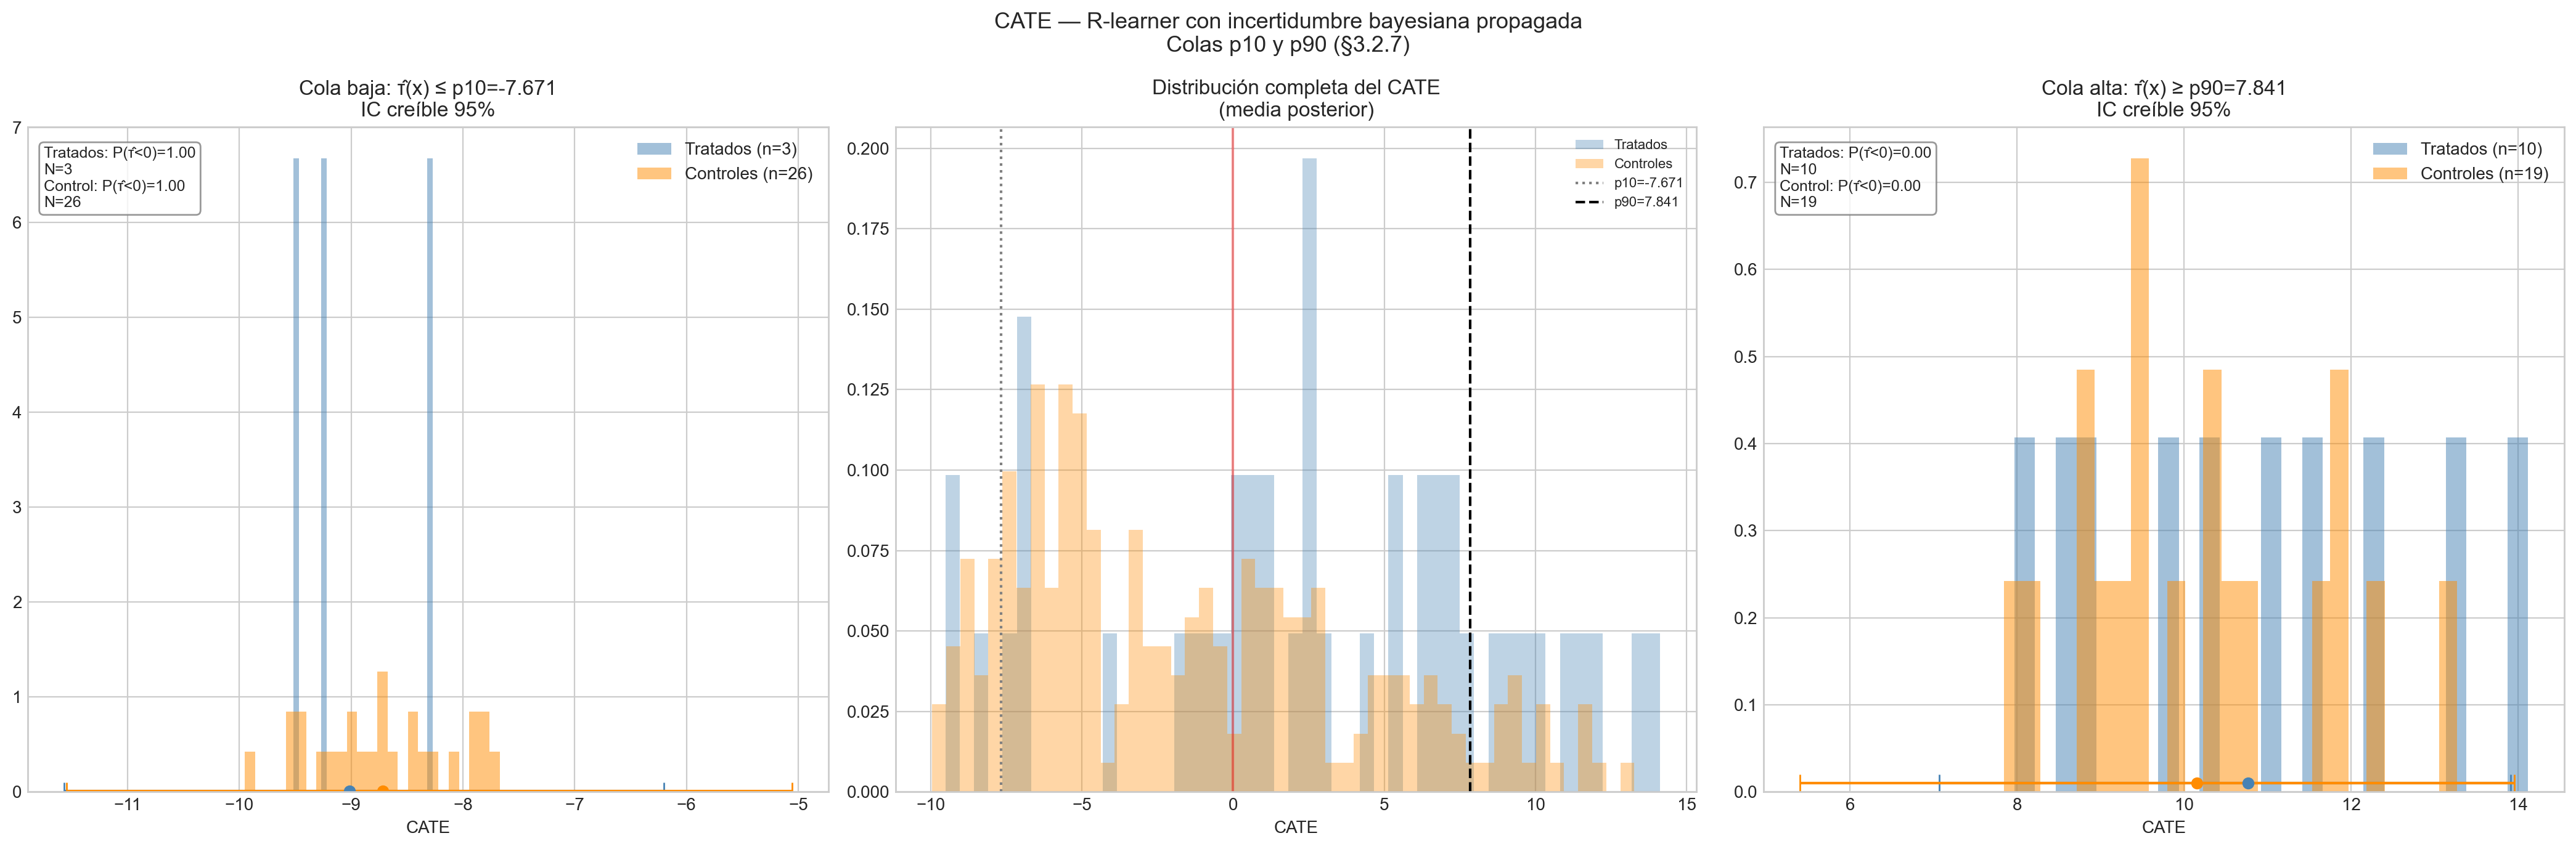

Grupo                             Media τ    IC 2.5%   IC 97.5%     N
-----------------------------------------------------------------
Tratados cola p10                 -9.0146   -11.5657    -6.2043     3
Controles cola p10                -8.7140   -11.5477    -5.0570    26
Tratados cola p90                 10.7655     7.0695    13.9118    10
Controles cola p90                10.1522     5.4023    13.9515    19


In [22]:
# ── CATE: colas p10 y p90 ─────────────────────────────────────────────────────
df_mean = cate_bayes["df_mean"]

def plot_cate_tails(df_mean: pd.DataFrame, bins_main: int = 50, bins_side: int = 25):
    """Distribución del CATE con énfasis en colas p10 y p90 (§3.2.7)."""
    treated = df_mean[df_mean["t"] == 1]
    control = df_mean[df_mean["t"] == 0]
    p10 = np.percentile(df_mean["tau_mean"], 10)
    p90 = np.percentile(df_mean["tau_mean"], 90)

    tr_low  = treated[treated["tau_mean"] <= p10]
    co_low  = control[control["tau_mean"] <= p10]
    tr_high = treated[treated["tau_mean"] >= p90]
    co_high = control[control["tau_mean"] >= p90]

    def cola_summary(grp):
        if len(grp) == 0: return "sin obs"
        return f"P(τ̂<0)={np.mean(grp['tau_mean']<0):.2f}\nN={len(grp)}"

    fig, axs = plt.subplots(1, 3, figsize=(21, 7))

    # Cola baja
    for grp, col, lbl in [(tr_low, "steelblue", "Tratados"), (co_low, "darkorange", "Controles")]:
        if len(grp): axs[0].hist(grp["tau_mean"], bins=bins_side, alpha=0.5, density=True,
                                  label=f"{lbl} (n={len(grp)})", ec="black", color=col)
        if len(grp): axs[0].errorbar(
            grp["tau_mean"].mean(), 0.01,
            xerr=[[grp["tau_mean"].mean()-grp["tau_lower"].mean()],
                  [grp["tau_upper"].mean()-grp["tau_mean"].mean()]],
            fmt="o", color=col, capsize=5)
    axs[0].set_title(f"Cola baja: τ̂(x) ≤ p10={p10:.3f}\nIC creíble 95%")
    axs[0].set_xlabel("CATE"); axs[0].legend()
    axs[0].text(0.02, 0.97, f"Tratados: {cola_summary(tr_low)}\nControl: {cola_summary(co_low)}",
                transform=axs[0].transAxes, ha="left", va="top", fontsize=9,
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.8))

    # Distribución completa
    axs[1].hist(treated["tau_mean"], bins=bins_main, alpha=0.35, density=True,
                label="Tratados", ec="black", color="steelblue")
    axs[1].hist(control["tau_mean"],  bins=bins_main, alpha=0.35, density=True,
                label="Controles", ec="black", color="darkorange")
    axs[1].axvline(p10, ls=":",  color="gray",  label=f"p10={p10:.3f}")
    axs[1].axvline(p90, ls="--", color="black", label=f"p90={p90:.3f}")
    axs[1].axvline(0,   ls="-",  color="red", alpha=0.4)
    axs[1].set_title("Distribución completa del CATE\n(media posterior)")
    axs[1].set_xlabel("CATE"); axs[1].legend(fontsize=8)

    # Cola alta
    for grp, col, lbl in [(tr_high, "steelblue", "Tratados"), (co_high, "darkorange", "Controles")]:
        if len(grp): axs[2].hist(grp["tau_mean"], bins=bins_side, alpha=0.5, density=True,
                                  label=f"{lbl} (n={len(grp)})", ec="black", color=col)
        if len(grp): axs[2].errorbar(
            grp["tau_mean"].mean(), 0.01,
            xerr=[[grp["tau_mean"].mean()-grp["tau_lower"].mean()],
                  [grp["tau_upper"].mean()-grp["tau_mean"].mean()]],
            fmt="o", color=col, capsize=5)
    axs[2].set_title(f"Cola alta: τ̂(x) ≥ p90={p90:.3f}\nIC creíble 95%")
    axs[2].set_xlabel("CATE"); axs[2].legend()
    axs[2].text(0.02, 0.97, f"Tratados: {cola_summary(tr_high)}\nControl: {cola_summary(co_high)}",
                transform=axs[2].transAxes, ha="left", va="top", fontsize=9,
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.8))

    plt.suptitle("CATE — R-learner con incertidumbre bayesiana propagada\n"                 "Colas p10 y p90 (§3.2.7)", fontsize=13)
    plt.tight_layout(); save_fig("bdml_cate_tails"); plt.show()

    # Tabla resumen de colas
    print(f"{'Grupo':<30} {'Media τ':>10} {'IC 2.5%':>10} {'IC 97.5%':>10} {'N':>5}")
    print("-"*65)
    for lbl, grp in [("Tratados cola p10", tr_low), ("Controles cola p10", co_low),
                     ("Tratados cola p90", tr_high), ("Controles cola p90", co_high)]:
        if len(grp):
            print(f"{lbl:<30} {grp['tau_mean'].mean():>10.4f} "                  f"{grp['tau_lower'].mean():>10.4f} {grp['tau_upper'].mean():>10.4f} {len(grp):>5}")
        else:
            print(f"{lbl:<30} {'(sin obs)':>10} {' ':>10} {' ':>10} {0:>5}")

plot_cate_tails(df_mean)


In [23]:
# ── Heterogeneidad CATE: P(tau_i > 0) por municipio ──────────────────────────
tau_draws_arr = cate_bayes["tau_draws"]
S_c, n_c = tau_draws_arr.shape

p_pos_unit = (tau_draws_arr > 0).mean(axis=0)   # P(tau_i > 0) por municipio

hpdi_lo_u = np.zeros(n_c); hpdi_hi_u = np.zeros(n_c)
for i in range(n_c):
    hpdi_lo_u[i], hpdi_hi_u[i] = hpdi_from_samples(tau_draws_arr[:, i], 0.90)
hpdi_width_u = hpdi_hi_u - hpdi_lo_u

print(f"Heterogeneidad CATE (§3.2.7):")
print(f"  Municipios con P(τ_i>0) > 0.95: {(p_pos_unit>0.95).sum()}/{n_c}")
print(f"  Municipios con P(τ_i>0) > 0.90: {(p_pos_unit>0.90).sum()}/{n_c}")
print(f"  Municipios con P(τ_i>0) > 0.50: {(p_pos_unit>0.50).sum()}/{n_c}")
print(f"  Mediana ancho HPDI 90%:          {np.median(hpdi_width_u):.4f}")
print(f"  P75/P90 ancho HPDI 90%:          "      f"{np.percentile(hpdi_width_u,75):.4f} / {np.percentile(hpdi_width_u,90):.4f}")


Heterogeneidad CATE (§3.2.7):
  Municipios con P(τ_i>0) > 0.95: 60/281
  Municipios con P(τ_i>0) > 0.90: 73/281
  Municipios con P(τ_i>0) > 0.50: 119/281
  Mediana ancho HPDI 90%:          5.9713
  P75/P90 ancho HPDI 90%:          7.2447 / 9.0838


## Análisis de robustez: muestra recortada (0.1 ≤ PS ≤ 0.9)

La muestra recortada (soporte común) es el **resultado primario** del análisis conjunto PS+BDML.
Los propensity scores ya están calculados en `PS_AIPW_DR.ipynb` (§3.1); aquí solo se carga 
`dataset_trimmed.xlsx` y se repite el BDML sobre esa submuestra.


In [24]:
# ── Carga y preparación de la muestra recortada ────────────────────────────────
dat_tr = pd.read_excel("dataset_trimmed.xlsx")
dat_tr["state"]     = dat_tr["state"].astype("category")
dat_tr["pib_class"] = dat_tr["pib_class"].astype("category")
dat_tr["urban"]     = dat_tr["urban"].astype("category")
print(f"Municipios en muestra recortada: {len(dat_tr)}")

d1_tr = pd.get_dummies(
    pd.Categorical(dat_tr["state"].astype(int), categories=all_states),
    prefix="state", dtype=int
)
d2_tr = pd.get_dummies(
    pd.Categorical(dat_tr["pib_class"].astype(int), categories=all_pib_class),
    prefix="pib_class", dtype=int
)
sel_tr = dat_tr[["LLAVE", "urban", "maquila", "informal", "imssissste",
                  "lpibpc", "poverty", "share_manufacture", "lpopulation",
                  "trt", "outcome"]]
data_tr = pd.concat([sel_tr, d1_tr, d2_tr], axis=1)

X_tr_s = data_tr[ALL_COVS].copy()
t_tr_s = data_tr["trt"]
y_tr_s = data_tr["outcome"]
print(f"  Tratados: {int(t_tr_s.sum())},  Controles: {int((1-t_tr_s).sum())}")


Municipios en muestra recortada: 133
  Tratados: 38,  Controles: 95


In [25]:
# ── BDML sobre muestra recortada ──────────────────────────────────────────────
fix_all_seeds(SEED + 1)
res_trim = dml_crossfit_bayesian_bart(
    X_tr_s, t_tr_s, y_tr_s,
    split_rules=SPLIT_RULES,
    K=4, stratify_t=True, m_outcome=50, m_ps=50,
    draws=4000, tune=1000, chains=4, p_clip=1e-3,
    random_seed=SEED + 1
)



  FOLD 1/4  |  train=99,  test=34
  [Fold 1] Estimando PS nuisance (BART Probit)...


Sequential sampling (4 chains in 1 job)
PGBART: [eta]


Output()

Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 315 seconds.
Sequential sampling (4 chains in 1 job)


  [Fold 1] Estimando outcome nuisance (BART Normal)...


...

  [Fold 4] Estimando outcome nuisance (BART Normal)...


PGBART: [mu]


Output()

Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 310 seconds.


  [Fold 4] theta_fold = 3.739386


In [26]:
# ── Resultados muestra recortada ──────────────────────────────────────────────
theta_draws_tr = res_trim["theta_draws"]
ate_trim = np.mean(theta_draws_tr)
hpdi_lo_tr, hpdi_hi_tr = hpdi_from_samples(theta_draws_tr, 0.90)
p_pos_tr = float(np.mean(theta_draws_tr > 0))

display(report_ate(theta_draws,    "BDML muestra completa"))
display(report_ate(theta_draws_tr, "BDML muestra recortada"))


,Estimado,Mediana,HPDI 90% Lo,HPDI 90% Hi,HPDI 95% Lo,HPDI 95% Hi,IC equic. 5–95%,IC equic. 2.5–97.5%,P(ATE>0)
BDML muestra completa,1.8109,1.8091,0.9515,2.6769,0.7730,2.8454,"[0.9482, 2.6738]","[0.7659, 2.8385]",0.9996


,Estimado,Mediana,HPDI 90% Lo,HPDI 90% Hi,HPDI 95% Lo,HPDI 95% Hi,IC equic. 5–95%,IC equic. 2.5–97.5%,P(ATE>0)
BDML muestra recortada,3.2411,3.2419,2.3973,4.1199,2.2223,4.2772,"[2.3782, 4.1040]","[2.2203, 4.2757]",1.0000


## Gráficas completas: ambos conjuntos de datos

La muestra **recortada** (soporte común, PS ∈ [0.1, 0.9]) es el estimando principal.
La muestra **completa** es el análisis de robustez.
Se generan las mismas figuras para ambas usando `bdml_plot_suite`.


In [27]:
# ── bdml_plot_suite: genera todas las gráficas estándar para un resultado BDML ──

def bdml_plot_suite(
    res: dict,
    X: pd.DataFrame,
    t: pd.Series,
    y: pd.Series,
    label: str,
    suffix: str,
    cate_n_draws: int = 200,
    random_state: int = SEED,
    run_cate: bool = True,
):
    """
    Genera y guarda el conjunto completo de gráficas BDML para un dataset.

    Parámetros
    ----------
    res     : salida de dml_crossfit_bayesian_bart.
    X, t, y : covariables, tratamiento, outcome del dataset.
    label   : etiqueta descriptiva (e.g. 'Muestra recortada (principal)').
    suffix  : sufijo de archivo (e.g. '_recortada', '_completa').
    """
    td   = res["theta_draws"]
    ttil = res["t_tilde"]
    ytil = res["y_tilde"]
    mu_td = float(np.mean(td))
    p_pos = float(np.mean(td > 0))
    hlo, hhi = hpdi_from_samples(td, 0.90)
    ci95 = np.quantile(td, [0.025, 0.975])
    sy   = float(y.std())

    print(f"\n{'='*60}")
    print(f"  BDML — {label}")
    print(f"{'='*60}")
    print(f"  E[ATE]      = {mu_td:.4f}")
    print(f"  HPDI 90%    = [{hlo:.4f}, {hhi:.4f}]")
    print(f"  IC 95% equic= [{ci95[0]:.4f}, {ci95[1]:.4f}]")
    print(f"  P(ATE > 0)  = {p_pos:.4f}")

    # ── 1. ATE posterior + regresión residuos ─────────────────────────────────
    fig, axs = plt.subplots(1, 2, figsize=(15, 6))
    axs[0].hist(td, bins=40, density=True, ec="black", alpha=0.6, color="steelblue",
                label="Draws ATE")
    axs[0].axvline(mu_td, ls="--", lw=2, color="navy", label=f"E[ATE] = {mu_td:.4f}")
    axs[0].axvline(hlo, ls=":", lw=2, color="darkred",
                   label=f"HPDI 90%: [{hlo:.4f}, {hhi:.4f}]")
    axs[0].axvline(hhi, ls=":", lw=2, color="darkred")
    axs[0].axvline(0.0, ls="-", lw=1, color="gray", alpha=0.7, label="ATE=0")
    axs[0].text(0.03, 0.97, f"P(ATE>0) = {p_pos:.3f}",
                transform=axs[0].transAxes, va="top", fontsize=11,
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.85))
    axs[0].set_title(f"BDML — Posterior ATE\n{label} (§3.2.5)", fontsize=12)
    axs[0].set_xlabel("ATE"); axs[0].legend(loc="upper right", fontsize=9)

    x_rng = np.linspace(ttil.min()-0.05, ttil.max()+0.05, 200)
    tbar = ttil.mean(); ybar = ytil.mean()
    a_dr = ybar - td * tbar
    for i in range(min(300, len(td))):
        axs[1].plot(x_rng, a_dr[i] + td[i]*x_rng, alpha=0.07, color="steelblue")
    axs[1].plot(x_rng, a_dr.mean() + td.mean()*x_rng,
                lw=2.5, color="navy", label=f"E[ATE]={mu_td:.4f}")
    axs[1].scatter(ttil, ytil, s=10, alpha=0.5, color="gray", label="Residuos")
    axs[1].axhline(0, ls="--", color="gray", alpha=0.5)
    axs[1].axvline(0, ls="--", color="gray", alpha=0.5)
    axs[1].set_title(r"Regresión de residuos: $\tilde Y \sim \beta \tilde Z$", fontsize=12)
    axs[1].set_xlabel(r"$\tilde Z_i$"); axs[1].set_ylabel(r"$\tilde Y_i$")
    axs[1].legend(fontsize=9)
    plt.tight_layout(); save_fig(f"bdml_ate_posterior{suffix}"); plt.show()

    # ── 2. Consistencia fold-by-fold ──────────────────────────────────────────
    tf = res["theta_folds"]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(range(1, len(tf)+1), tf, color="steelblue", alpha=0.7, ec="black")
    ax.axhline(res["theta_hat"], ls="--", lw=2, color="navy",
               label=f"Theta apilado = {res['theta_hat']:.4f}")
    ax.axhline(0, ls="-", lw=1, color="gray", alpha=0.5)
    ax.set_xlabel("Fold"); ax.set_ylabel(r"$\hat\theta_k$")
    ax.set_title(f"Theta por fold — {label}")
    ax.legend(); plt.tight_layout()
    save_fig(f"bdml_fold_consistency{suffix}"); plt.show()

    # ── 3. E-value ────────────────────────────────────────────────────────────
    def _ev(a): d=a/sy; rr=np.exp(0.91*d); rr=max(rr,1/rr) if rr<1 else rr; return float(rr+np.sqrt(rr*(rr-1))) if rr>1 else 1.0
    ev_draws = np.array([_ev(th) for th in td])
    ev_mean  = _ev(mu_td)
    ev_lim   = _ev(hlo) if abs(hlo) < abs(hhi) else _ev(hhi)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(ev_draws, bins=35, density=True, alpha=0.6, ec="black", color="steelblue")
    ax.axvline(ev_mean, ls="--", lw=2, color="navy",    label=f"E-value estimado = {ev_mean:.2f}")
    ax.axvline(ev_lim,  ls=":",  lw=2, color="darkred", label=f"E-value HPDI límite = {ev_lim:.2f}")
    ax.axvline(1.0, ls="-", lw=1, color="gray")
    ax.set_title(f"E-value posterior — {label}")
    ax.set_xlabel("E-value"); ax.legend()
    plt.tight_layout(); save_fig(f"bdml_evalue{suffix}"); plt.show()

    # ── 4. CATE ───────────────────────────────────────────────────────────────
    if not run_cate:
        print("  (CATE omitido — run_cate=False)")
        return None

    print(f"  Estimando CATE R-learner ({cate_n_draws} draws)...")
    cate_res = fit_cate_rlearner_bayes(
        X=X, t=t, res=res, method="forest",
        n_draws=cate_n_draws, random_state=random_state
    )
    tau_dr = cate_res["tau_draws"]
    tau_m  = cate_res["tau_mean"]
    tau_lo = cate_res["tau_lower"]
    tau_hi = cate_res["tau_upper"]
    df_m   = cate_res["df_mean"]

    ate_impl  = tau_dr.mean(axis=1)
    p_pos_c   = float(np.mean(ate_impl > 0))
    hlo_c, hhi_c = hpdi_from_samples(ate_impl, 0.90)
    p_pos_u = (tau_dr > 0).mean(axis=0)

    print(f"  ATE implícito: E={ate_impl.mean():.4f}  P(>0)={p_pos_c:.4f}  "          f"HPDI 90%=[{hlo_c:.4f},{hhi_c:.4f}]")

    # Gráfica CATE general
    fig, axs = plt.subplots(1, 2, figsize=(16, 6))
    axs[0].hist(tau_m, bins=40, density=True, alpha=0.6, ec="black", color="steelblue")
    axs[0].axvline(0, ls="--", color="gray", alpha=0.7)
    axs[0].set_title(f"CATE τ̂(x) — {label}")
    axs[0].set_xlabel("CATE estimado")
    order = np.argsort(tau_m)
    idx = np.arange(len(order))
    axs[1].fill_between(idx, tau_lo[order], tau_hi[order], alpha=0.3,
                        color="steelblue", label="IC 95% creíble")
    axs[1].plot(idx, tau_m[order], lw=1.2, color="navy", label="Media posterior")
    axs[1].axhline(0, ls="--", color="gray")
    axs[1].set_title(f"CATE por municipio (ordenado) — {label}")
    axs[1].set_xlabel("Municipio (ordenado por CATE)"); axs[1].legend()
    plt.tight_layout(); save_fig(f"bdml_cate_posterior{suffix}"); plt.show()

    # Gráfica colas p10/p90
    p10 = np.percentile(tau_m, 10); p90 = np.percentile(tau_m, 90)
    t_arr = np.asarray(t)
    def _cola_info(mask):
        g = df_m[mask]
        return g["tau_mean"].mean(), g["tau_lower"].mean(), g["tau_upper"].mean(), len(g)

    tr_low  = df_m[(t_arr==1) & (tau_m<=p10)]; co_low  = df_m[(t_arr==0) & (tau_m<=p10)]
    tr_high = df_m[(t_arr==1) & (tau_m>=p90)]; co_high = df_m[(t_arr==0) & (tau_m>=p90)]

    fig, axs = plt.subplots(1, 3, figsize=(21, 7))
    for grp, col, lbl in [(tr_low,"steelblue","Tratados"),(co_low,"darkorange","Controles")]:
        if len(grp):
            axs[0].hist(grp["tau_mean"],bins=20,alpha=0.5,density=True,ec="black",color=col,label=f"{lbl} n={len(grp)}")
    axs[0].set_title(f"Cola baja τ̂≤p10={p10:.2f}\n{label}"); axs[0].legend(fontsize=8)
    axs[0].set_xlabel("CATE")
    for grp, col, lbl in [(df_m[t_arr==1],"steelblue","Tratados"),(df_m[t_arr==0],"darkorange","Controles")]:
        axs[1].hist(grp["tau_mean"],bins=40,alpha=0.35,density=True,ec="black",color=col,label=lbl)
    axs[1].axvline(p10,ls=":",color="gray",label=f"p10={p10:.2f}")
    axs[1].axvline(p90,ls="--",color="black",label=f"p90={p90:.2f}")
    axs[1].axvline(0,ls="-",color="red",alpha=0.4)
    axs[1].set_title(f"Distribución completa CATE\n{label}"); axs[1].legend(fontsize=8)
    axs[1].set_xlabel("CATE")
    for grp, col, lbl in [(tr_high,"steelblue","Tratados"),(co_high,"darkorange","Controles")]:
        if len(grp):
            axs[2].hist(grp["tau_mean"],bins=20,alpha=0.5,density=True,ec="black",color=col,label=f"{lbl} n={len(grp)}")
    axs[2].set_title(f"Cola alta τ̂≥p90={p90:.2f}\n{label}"); axs[2].legend(fontsize=8)
    axs[2].set_xlabel("CATE")
    plt.suptitle(f"CATE — colas p10/p90 (§3.2.7) — {label}", fontsize=13)
    plt.tight_layout(); save_fig(f"bdml_cate_tails{suffix}"); plt.show()

    # Tabla de colas
    print(f"{'Grupo':<30} {'Media τ':>10} {'IC 2.5%':>10} {'IC 97.5%':>10} {'N':>5}")
    print("-"*65)
    for lbl_g, grp in [("Tratados cola p10",tr_low),("Controles cola p10",co_low),
                       ("Tratados cola p90",tr_high),("Controles cola p90",co_high)]:
        if len(grp):
            print(f"{lbl_g:<30} {grp['tau_mean'].mean():>10.4f} "                  f"{grp['tau_lower'].mean():>10.4f} {grp['tau_upper'].mean():>10.4f} {len(grp):>5}")

    # Heterogeneidad
    hpdi_lo_u = np.zeros(len(tau_m)); hpdi_hi_u = np.zeros(len(tau_m))
    for i in range(len(tau_m)):
        hpdi_lo_u[i], hpdi_hi_u[i] = hpdi_from_samples(tau_dr[:,i], 0.90)
    hpdi_w = hpdi_hi_u - hpdi_lo_u
    print(f"\nHeterogeneidad CATE {label}:")
    print(f"  P(τ_i>0)>0.95: {(p_pos_u>0.95).sum()}/{len(tau_m)}")
    print(f"  P(τ_i>0)>0.90: {(p_pos_u>0.90).sum()}/{len(tau_m)}")
    print(f"  P(τ_i>0)>0.50: {(p_pos_u>0.50).sum()}/{len(tau_m)}")
    print(f"  HPDI 90% ancho mediana: {np.median(hpdi_w):.4f}")

    return cate_res


### Gráficas — Muestra recortada (análisis principal, §3.2)

PS ∈ [0.1, 0.9]. Estimando primario de la tesis.



  BDML — Muestra recortada (principal)
  E[ATE]      = 3.2411
  HPDI 90%    = [2.3973, 4.1199]
  IC 95% equic= [2.2203, 4.2757]
  P(ATE > 0)  = 1.0000
[guardada] FigurasBDML/bdml_ate_posterior_recortada.png  (+ pdf)


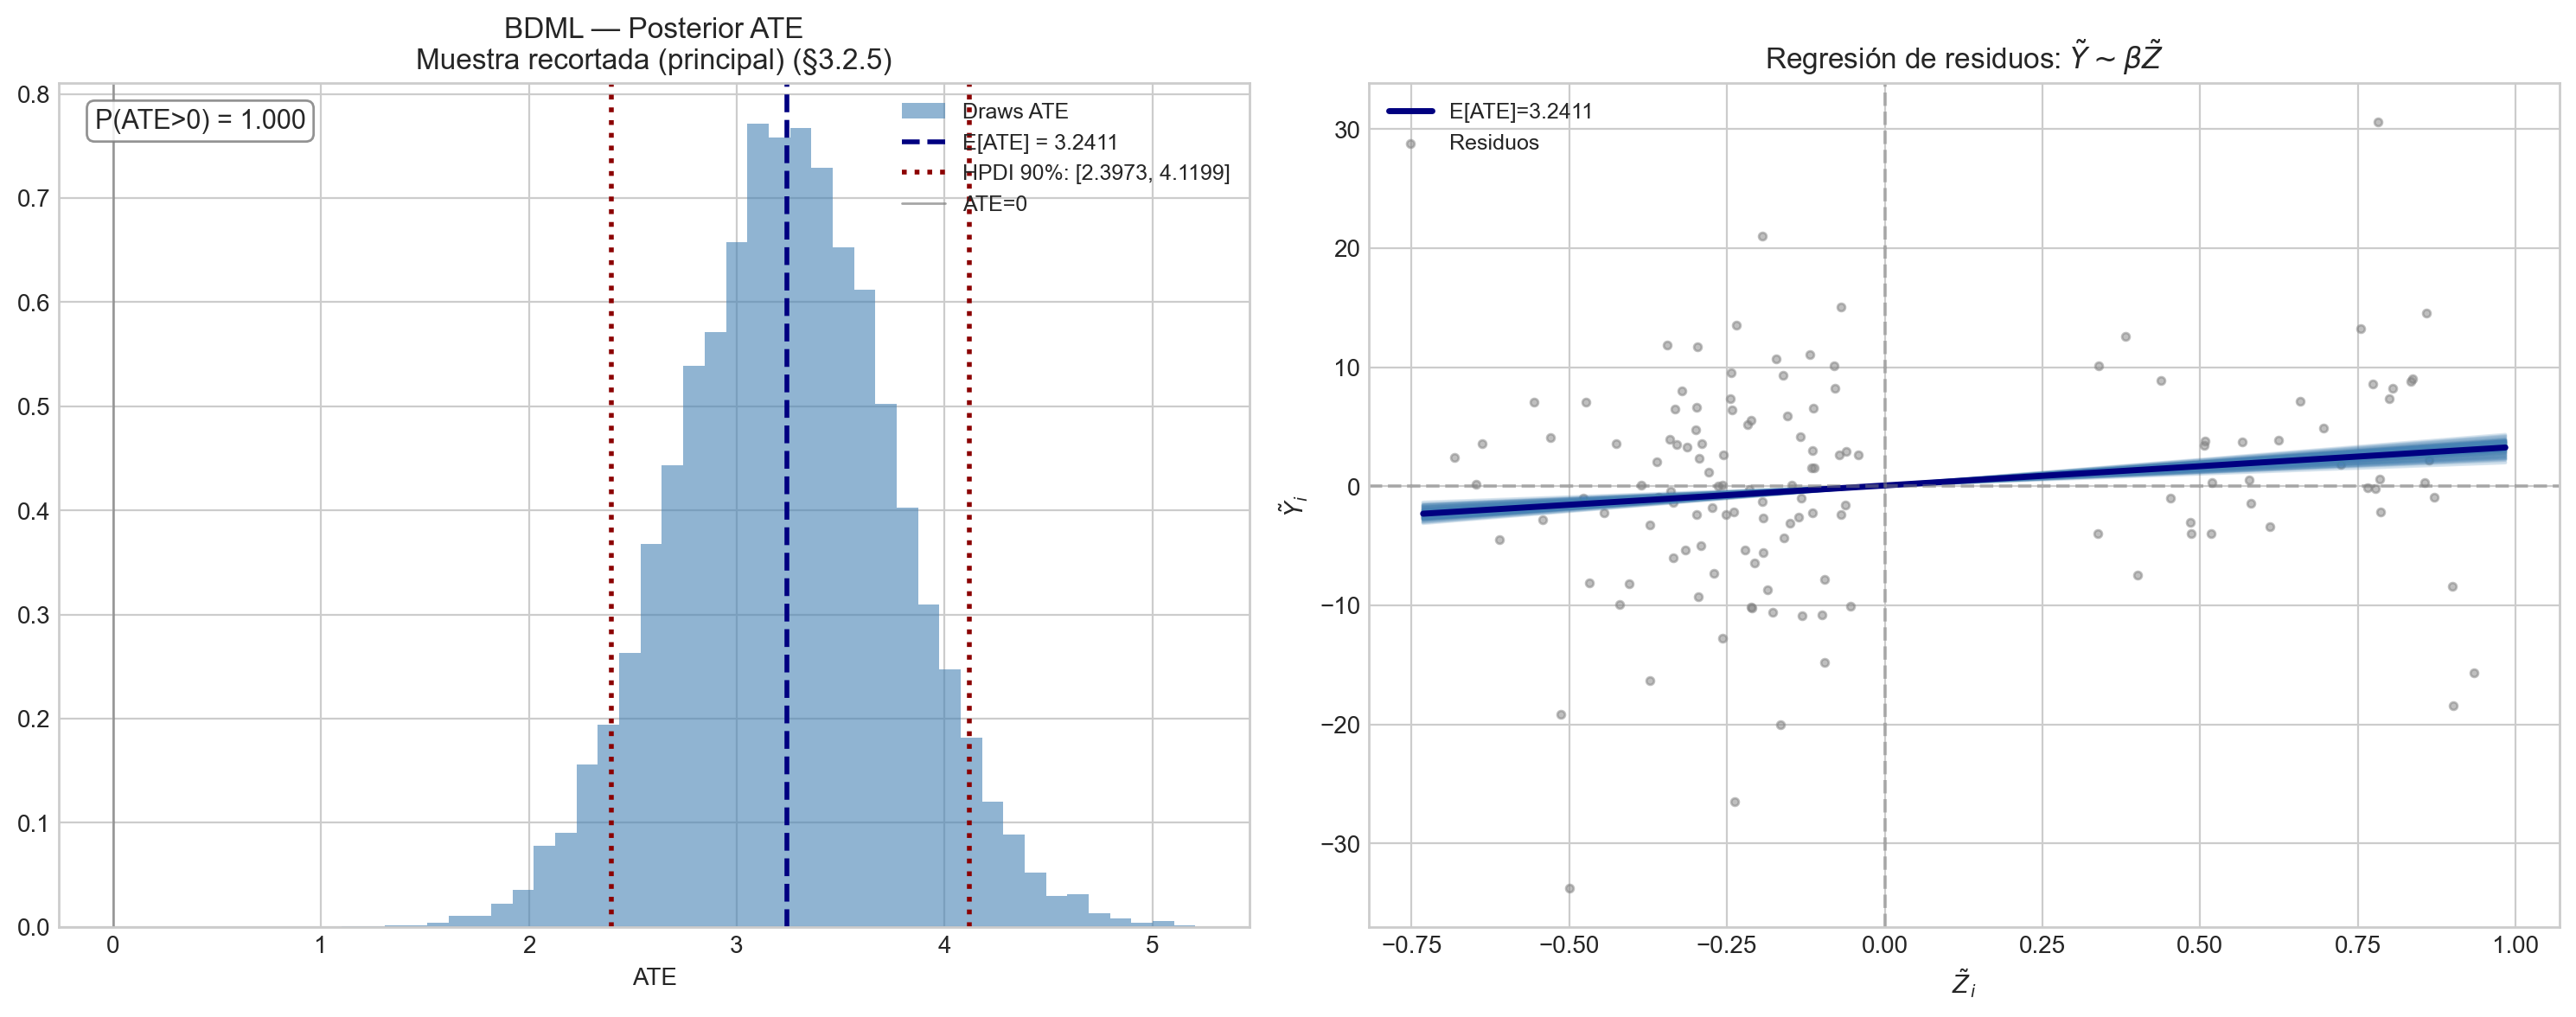

[guardada] FigurasBDML/bdml_fold_consistency_recortada.png  (+ pdf)


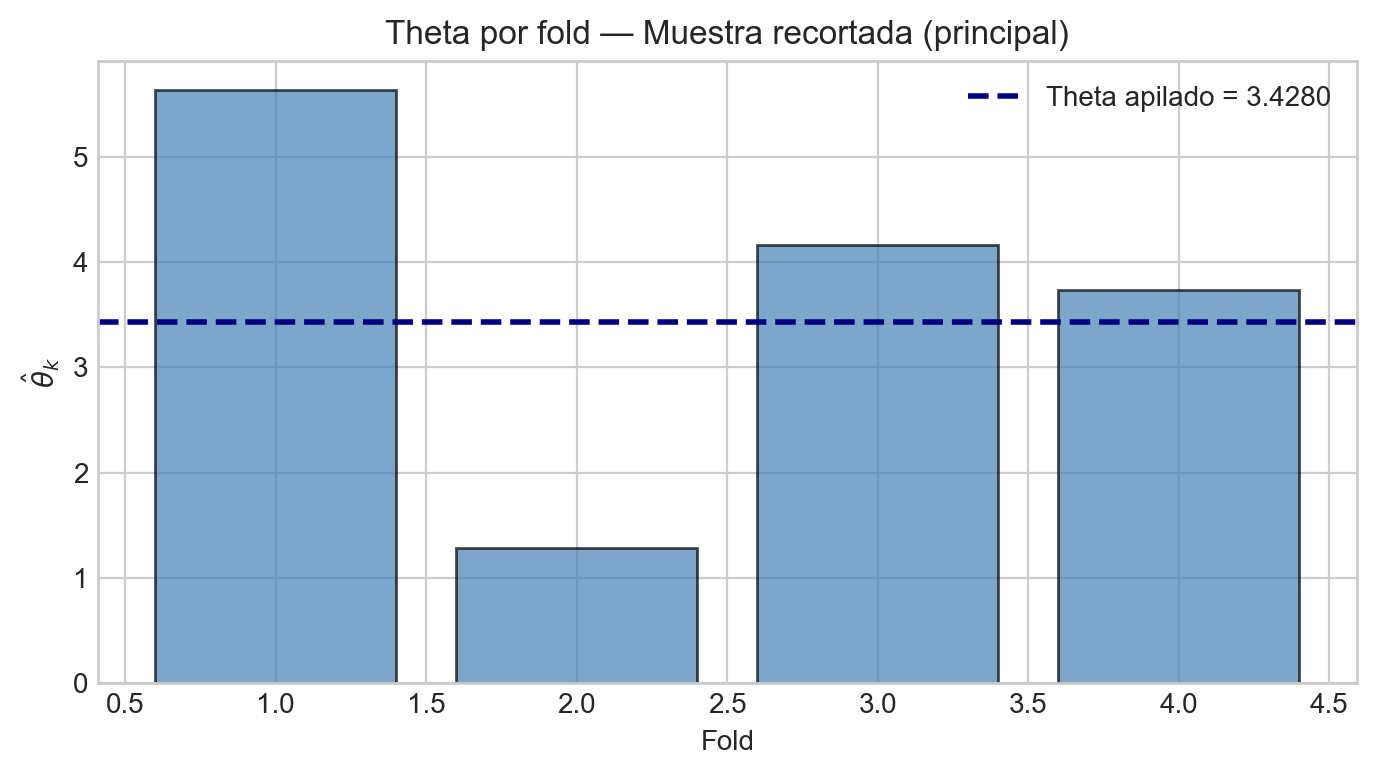

[guardada] FigurasBDML/bdml_evalue_recortada.png  (+ pdf)


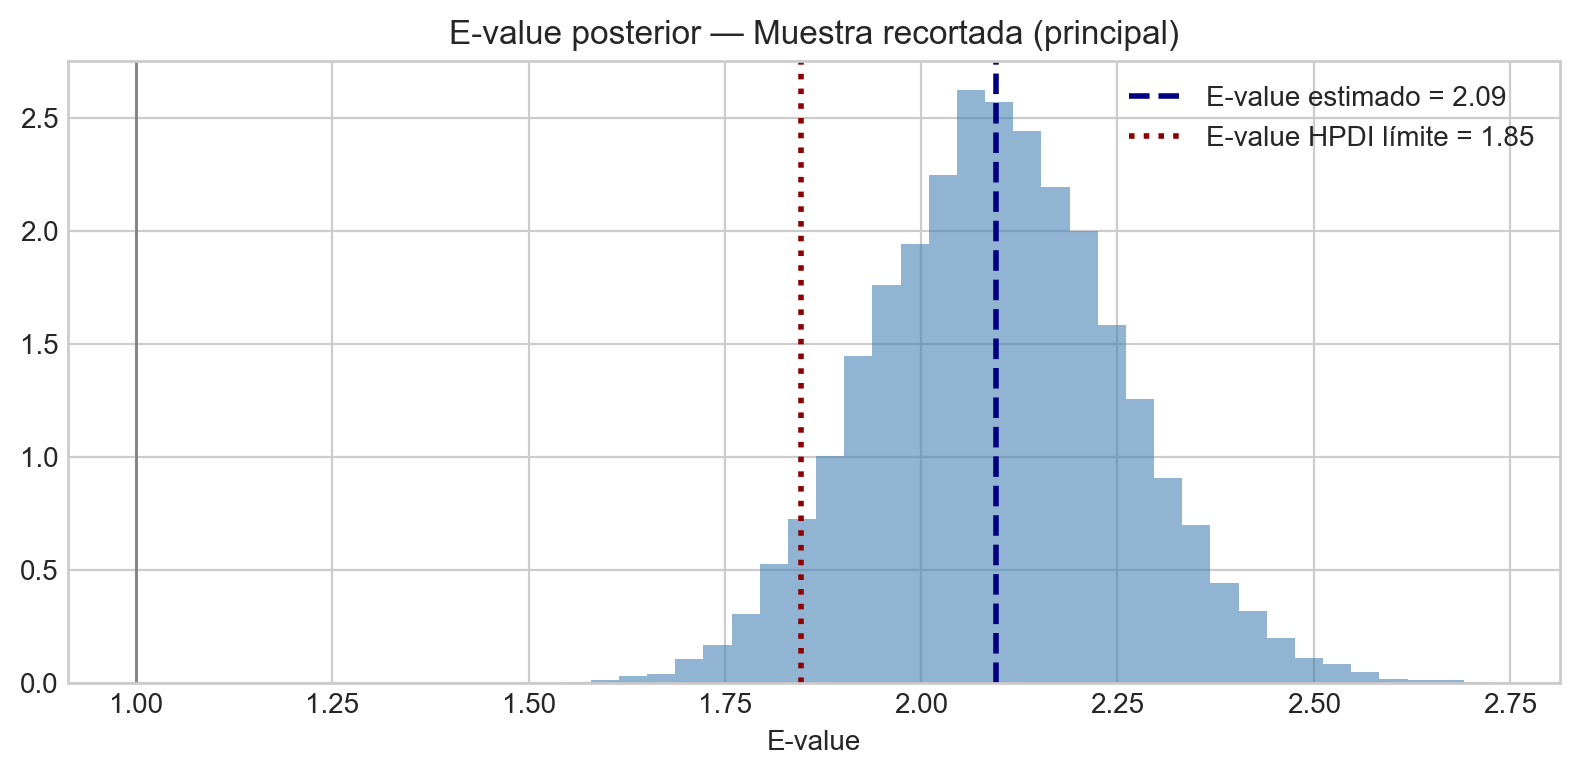

  Estimando CATE R-learner (200 draws)...
  ATE implícito: E=2.7452  P(>0)=1.0000  HPDI 90%=[1.6977,3.6702]
[guardada] FigurasBDML/bdml_cate_posterior_recortada.png  (+ pdf)


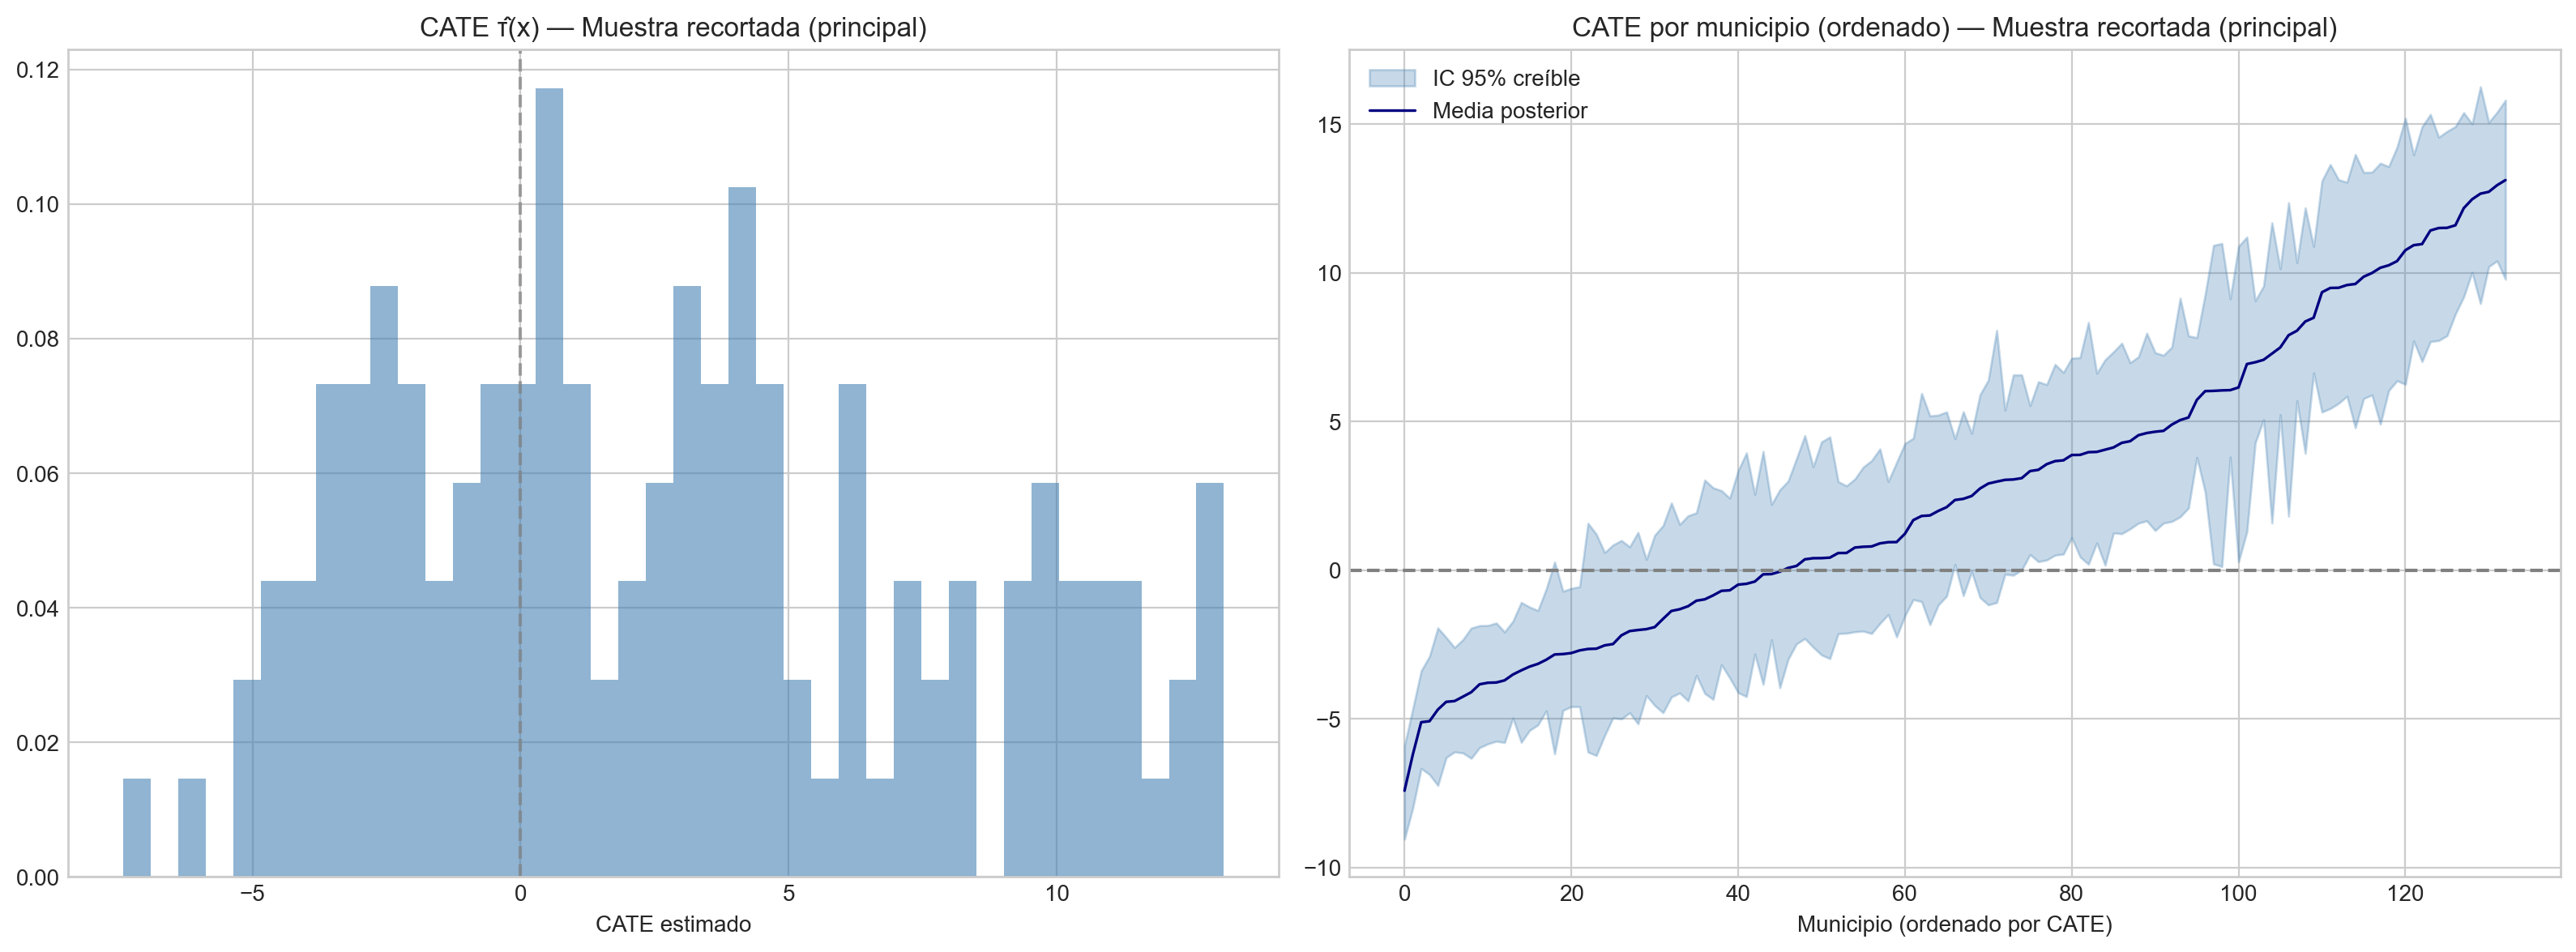

[guardada] FigurasBDML/bdml_cate_tails_recortada.png  (+ pdf)


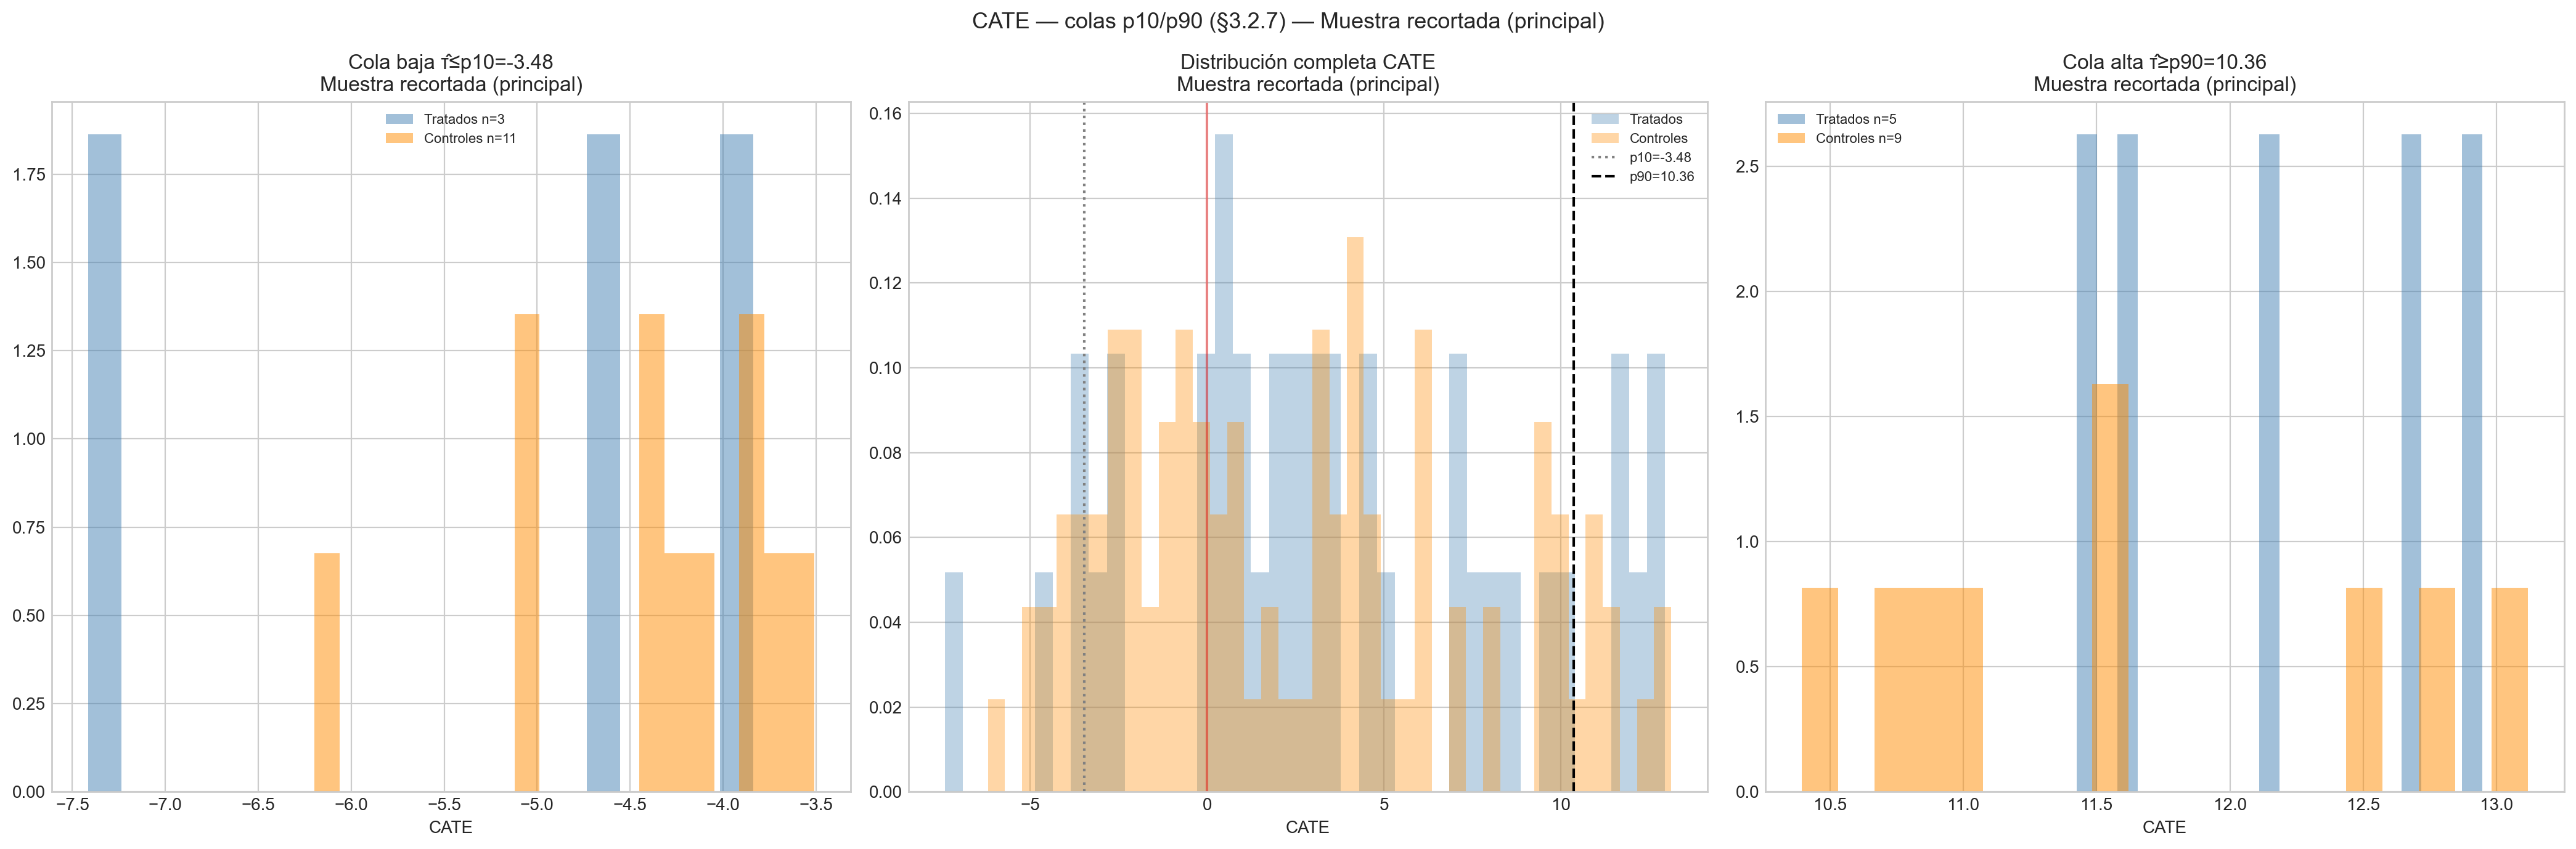

Grupo                             Media τ    IC 2.5%   IC 97.5%     N
-----------------------------------------------------------------
Tratados cola p10                 -5.3141    -7.4184    -3.2373     3
Controles cola p10                -4.3960    -6.2534    -2.5023    11
Tratados cola p90                 12.1618     8.9735    15.4582     5
Controles cola p90                11.5982     8.1071    14.8324     9

Heterogeneidad CATE Muestra recortada (principal):
  P(τ_i>0)>0.95: 63/133
  P(τ_i>0)>0.90: 69/133
  P(τ_i>0)>0.50: 87/133
  HPDI 90% ancho mediana: 5.0513


In [28]:
# ── Análisis principal: muestra recortada ─────────────────────────────────────
cate_trim = bdml_plot_suite(
    res=res_trim,
    X=X_tr_s, t=t_tr_s, y=y_tr_s,
    label="Muestra recortada (principal)",
    suffix="_recortada",
    cate_n_draws=200,
    random_state=SEED + 1,
    run_cate=True,
)


### Gráficas — Muestra completa (análisis de robustez, §3.2)



  BDML — Muestra completa (robustez)
  E[ATE]      = 1.8109
  HPDI 90%    = [0.9515, 2.6769]
  IC 95% equic= [0.7659, 2.8385]
  P(ATE > 0)  = 0.9996
[guardada] FigurasBDML/bdml_ate_posterior_completa.png  (+ pdf)


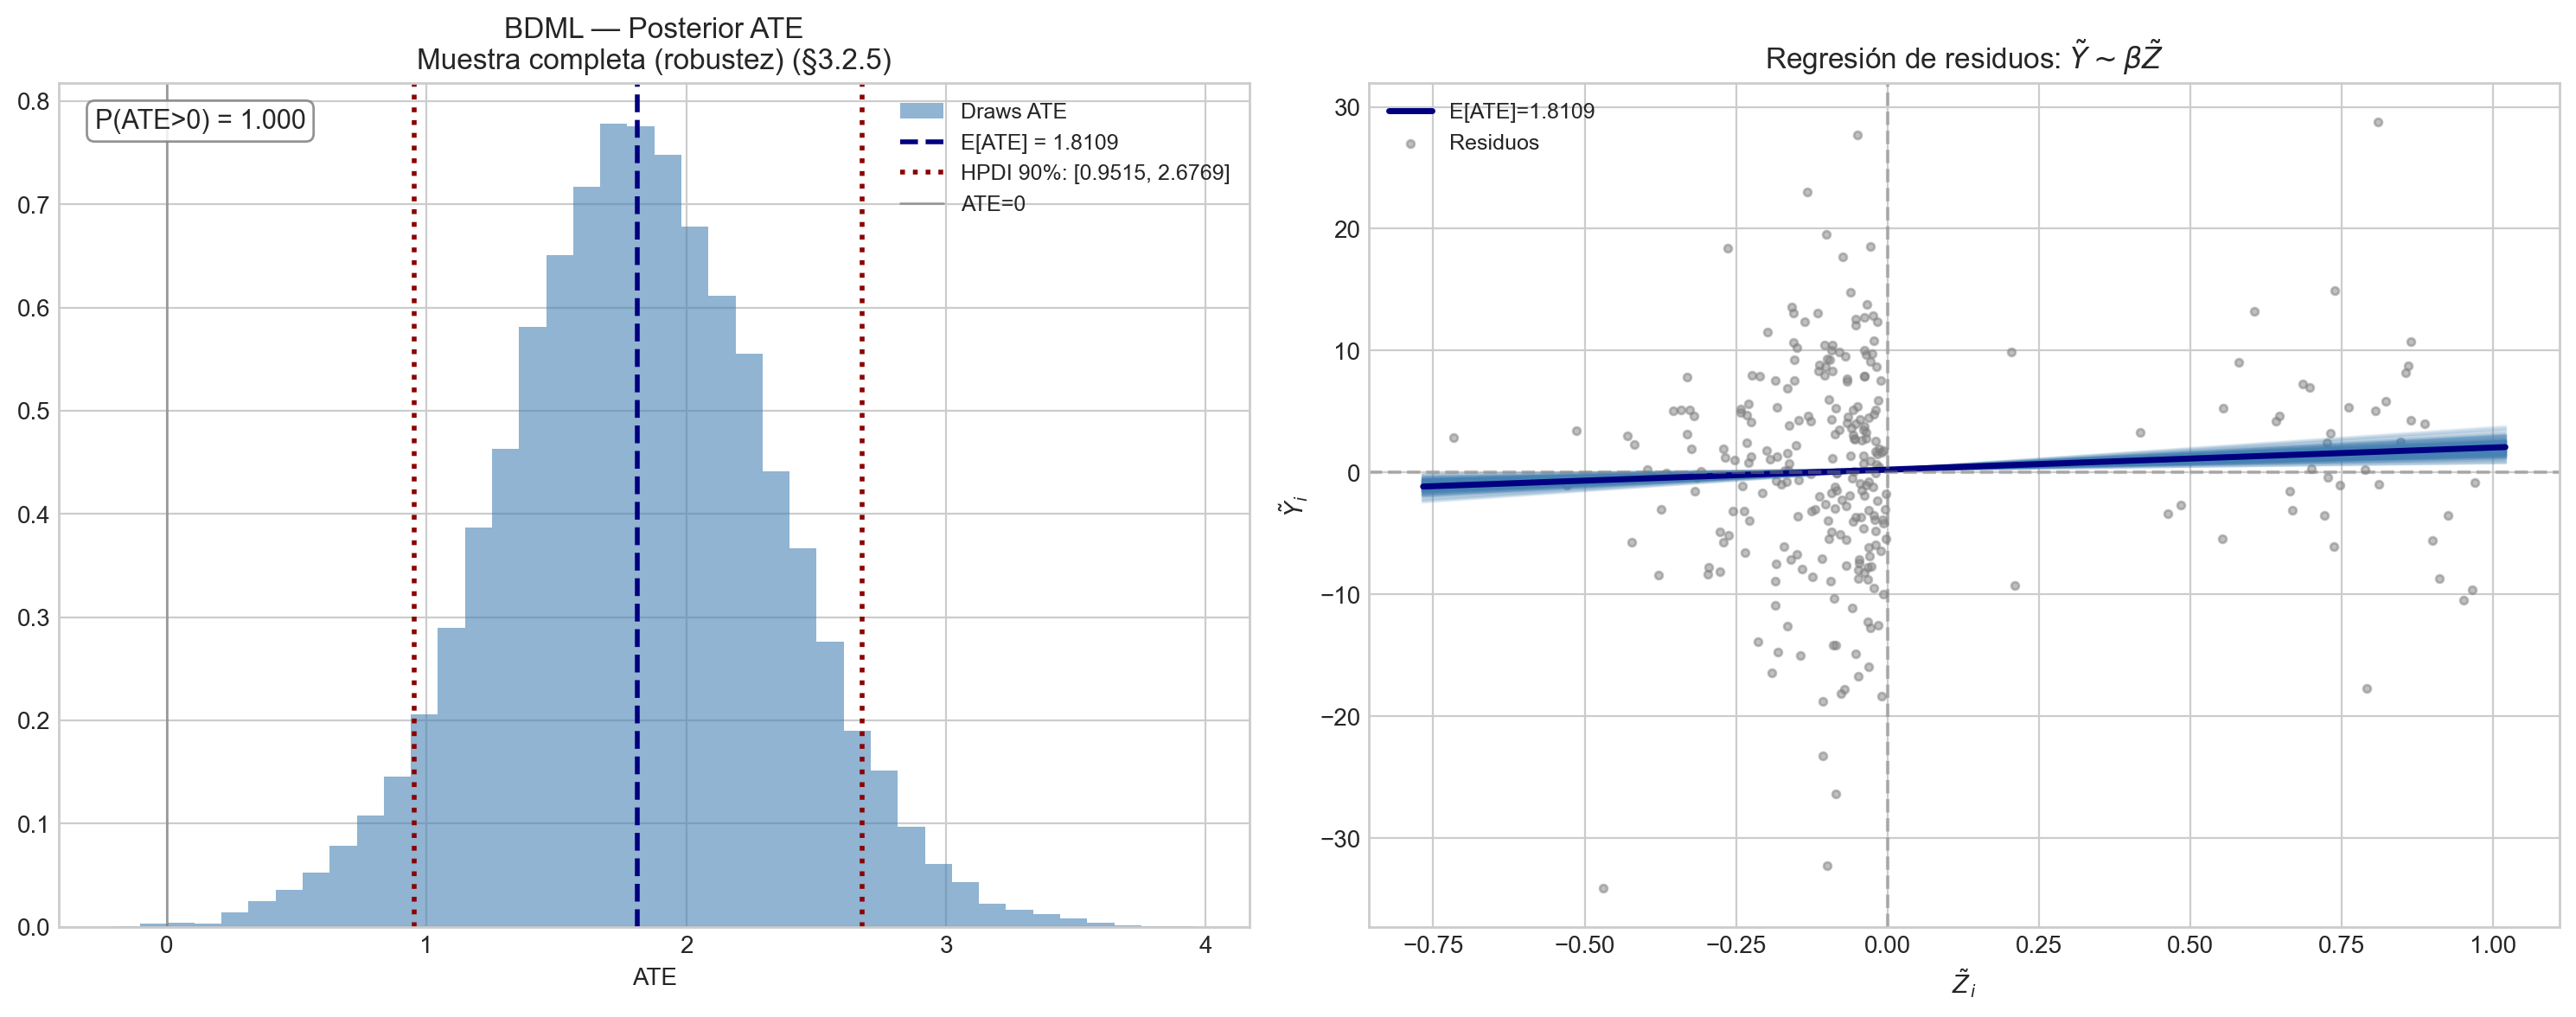

[guardada] FigurasBDML/bdml_fold_consistency_completa.png  (+ pdf)


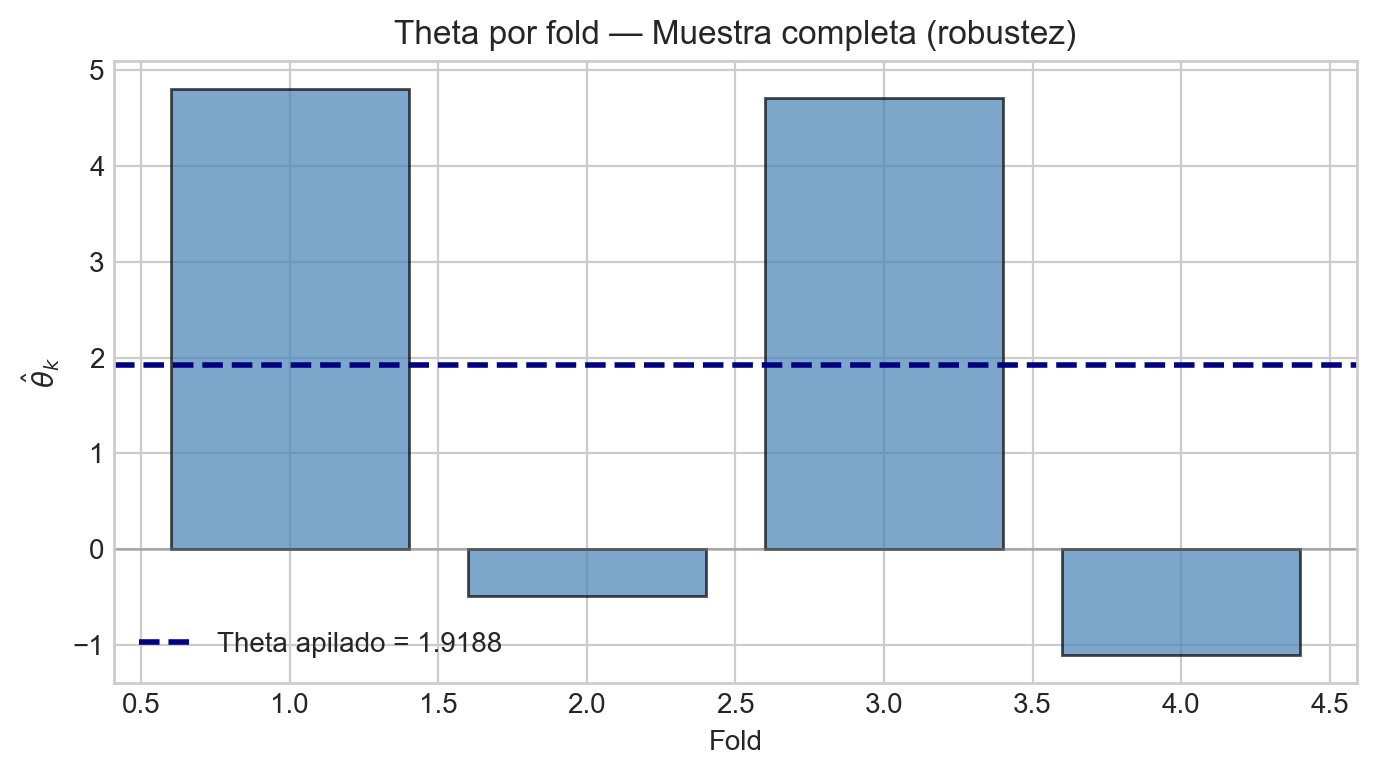

[guardada] FigurasBDML/bdml_evalue_completa.png  (+ pdf)


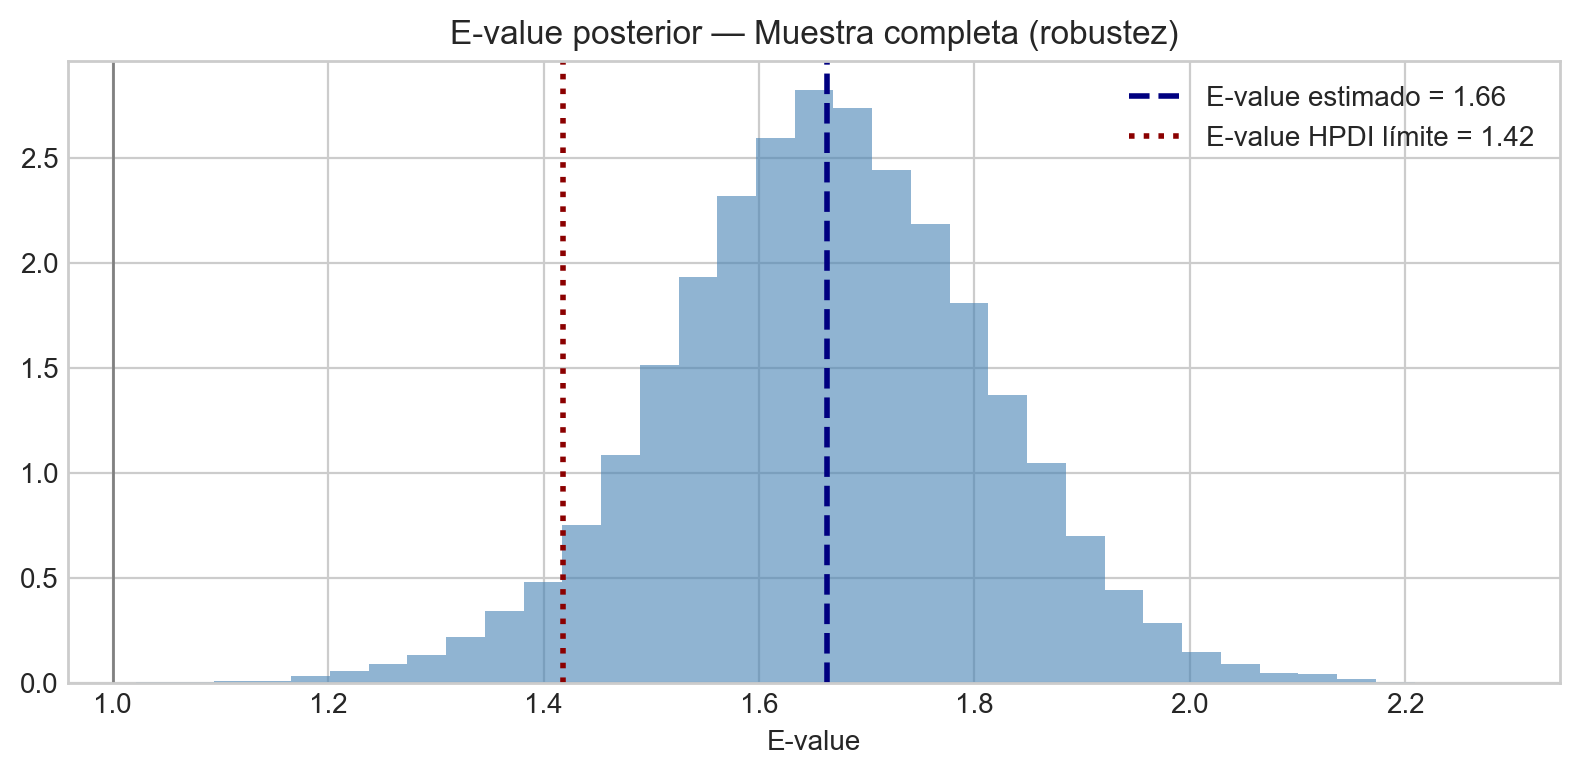

  Estimando CATE R-learner (200 draws)...
  ATE implícito: E=-0.8872  P(>0)=0.1550  HPDI 90%=[-2.2982,0.5199]
[guardada] FigurasBDML/bdml_cate_posterior_completa.png  (+ pdf)


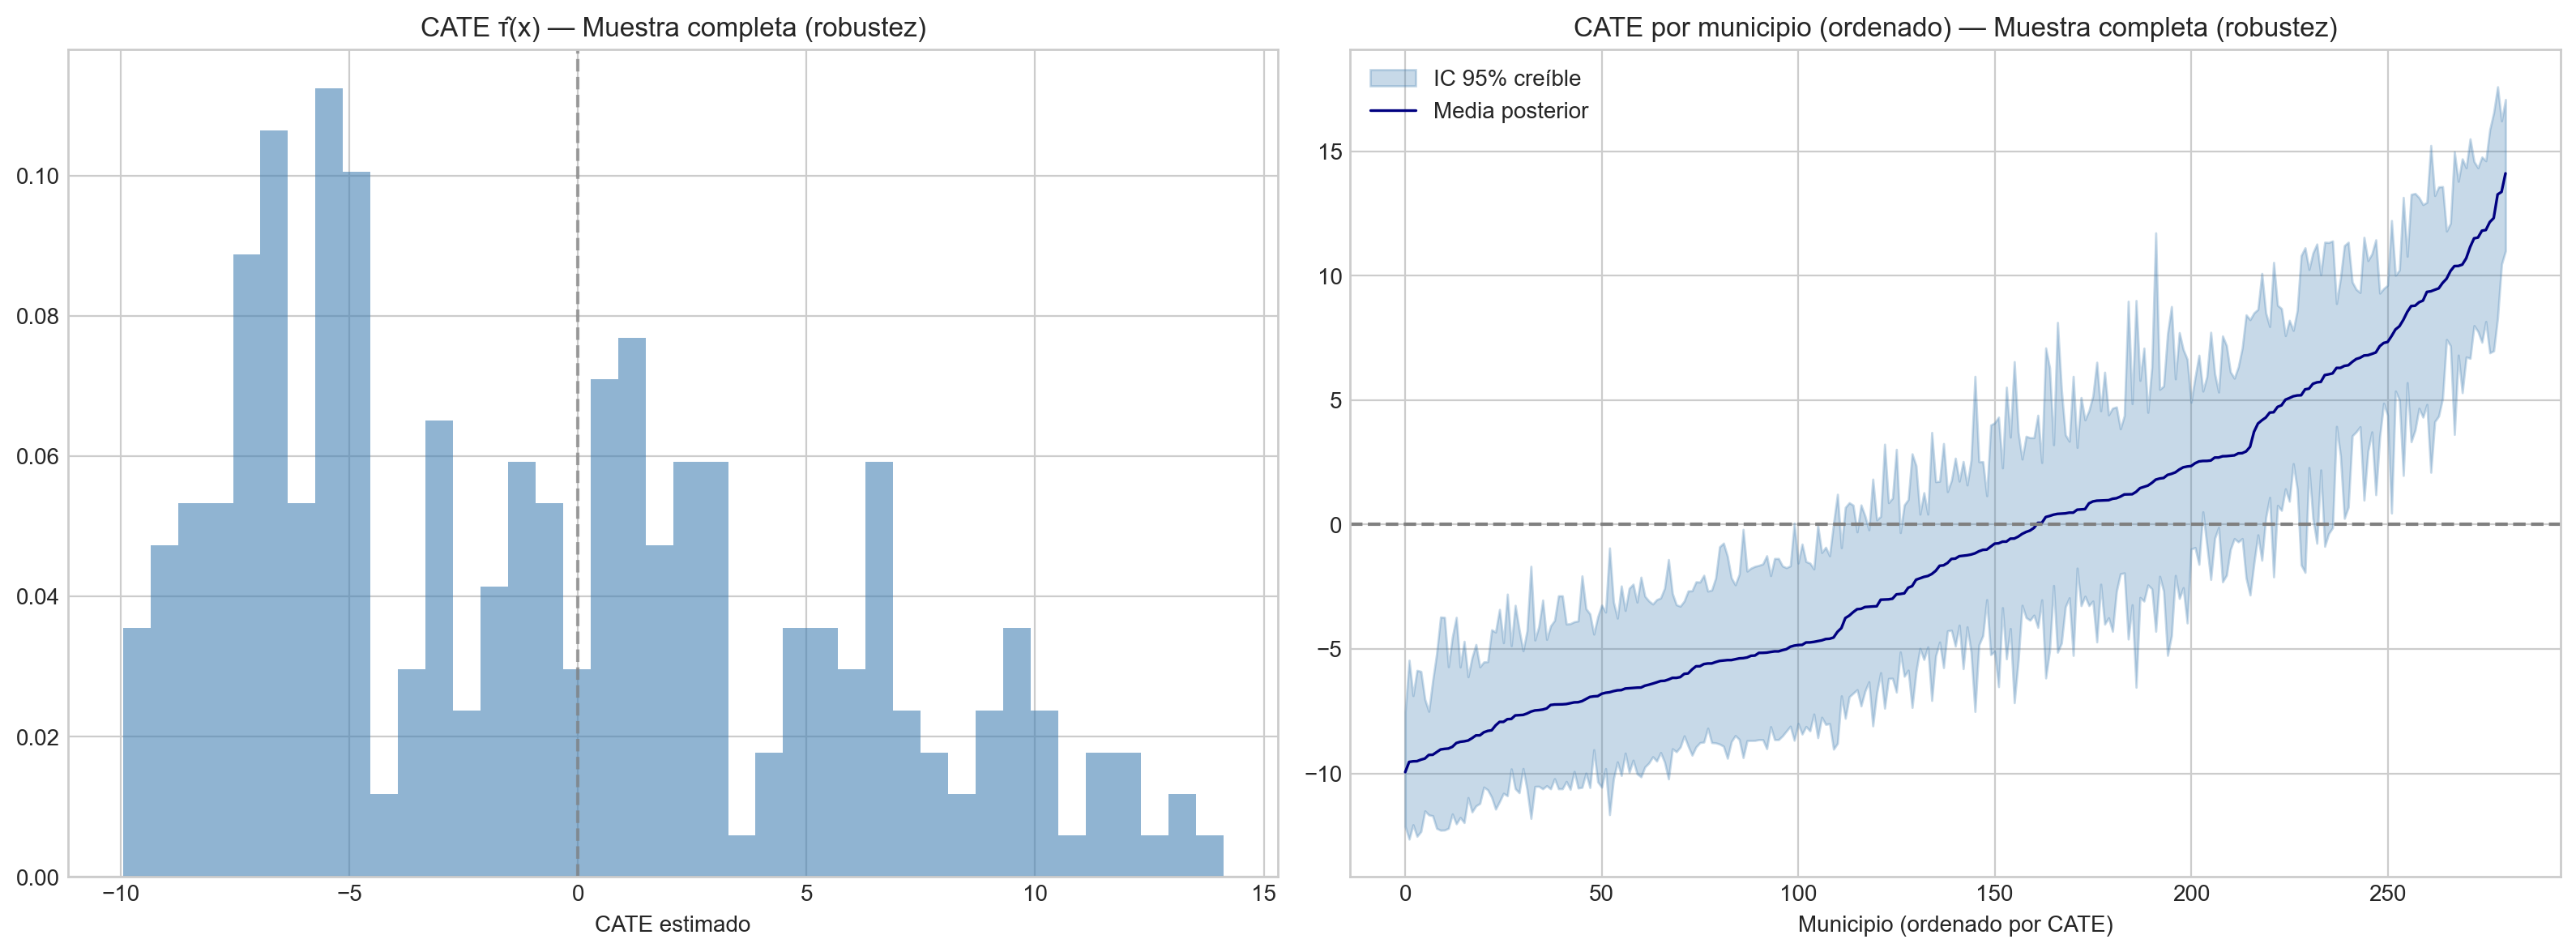

[guardada] FigurasBDML/bdml_cate_tails_completa.png  (+ pdf)


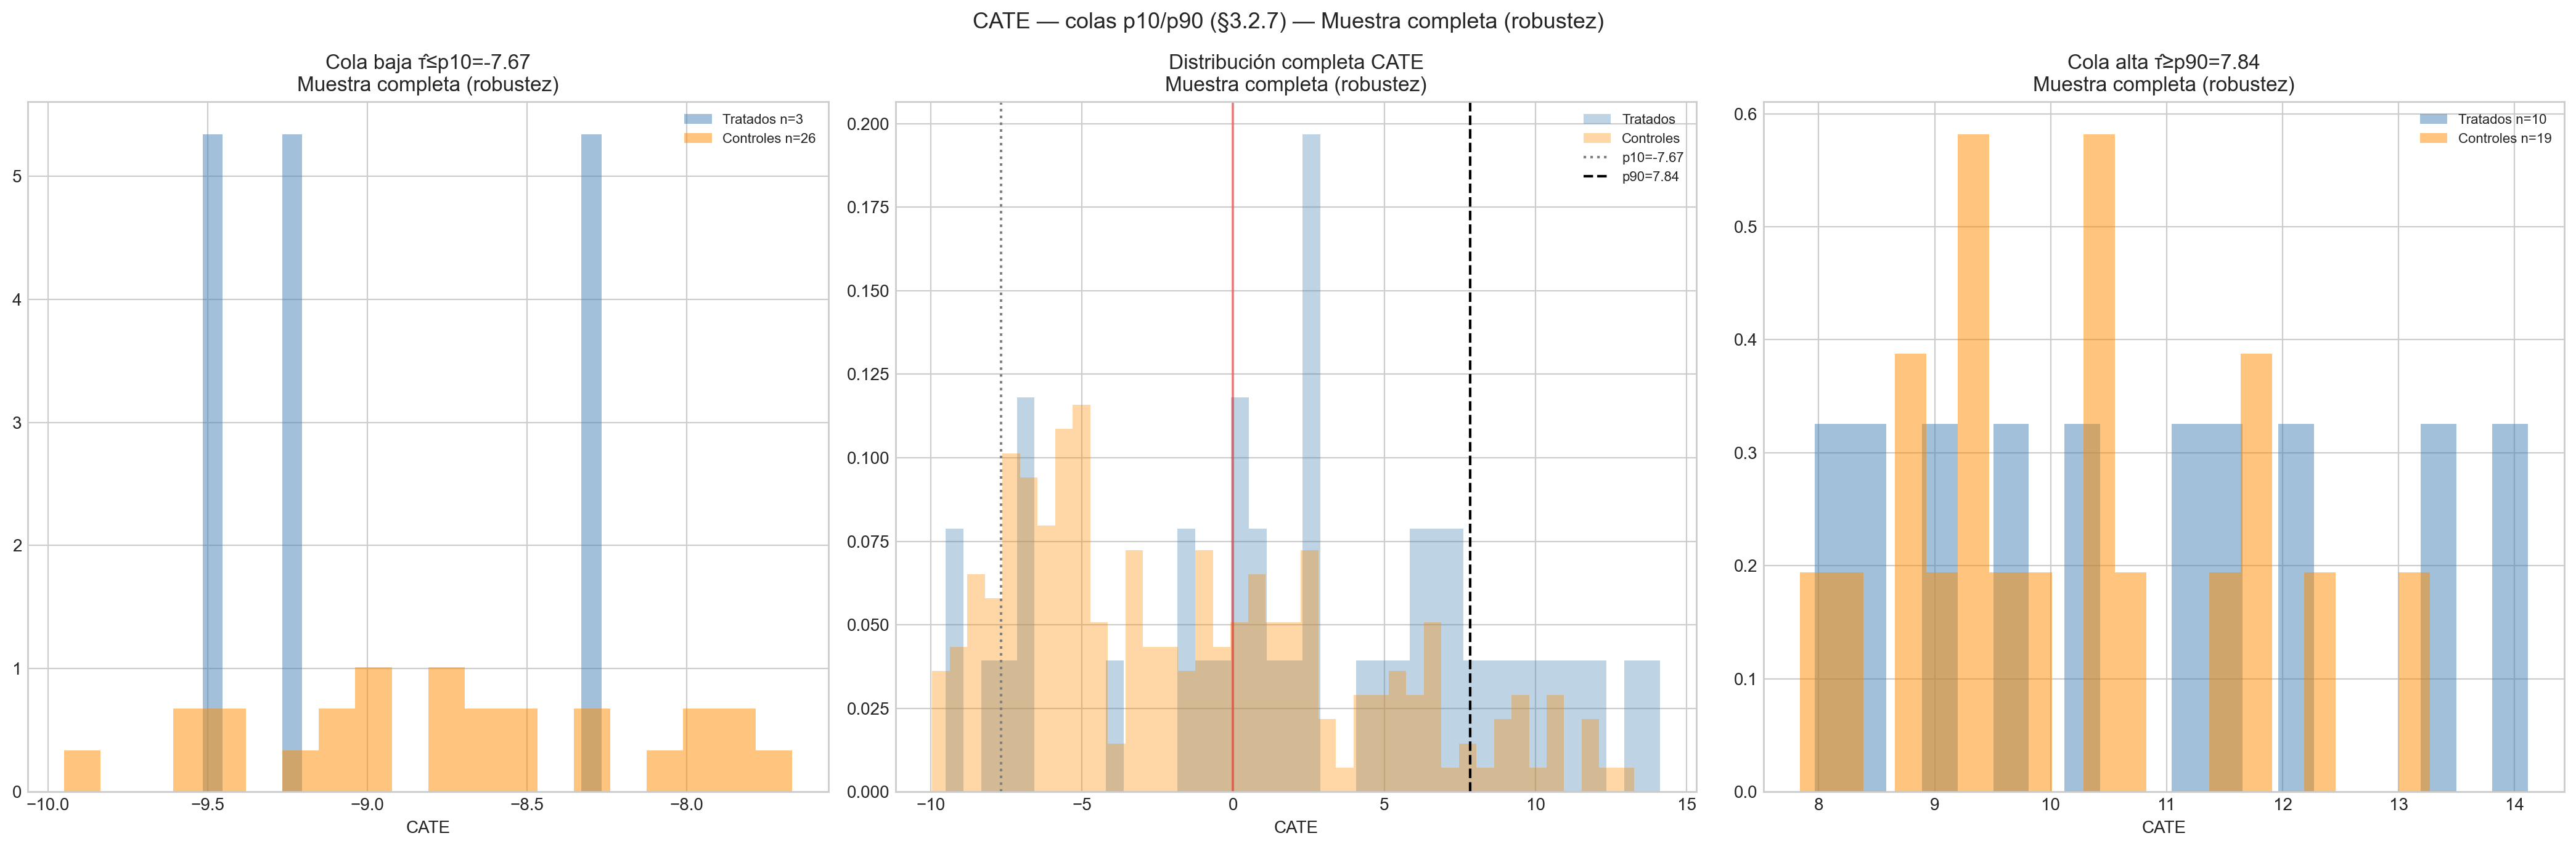

Grupo                             Media τ    IC 2.5%   IC 97.5%     N
-----------------------------------------------------------------
Tratados cola p10                 -9.0146   -11.5657    -6.2043     3
Controles cola p10                -8.7140   -11.5477    -5.0570    26
Tratados cola p90                 10.7655     7.0695    13.9118    10
Controles cola p90                10.1522     5.4023    13.9515    19

Heterogeneidad CATE Muestra completa (robustez):
  P(τ_i>0)>0.95: 60/281
  P(τ_i>0)>0.90: 73/281
  P(τ_i>0)>0.50: 119/281
  HPDI 90% ancho mediana: 5.9713


In [29]:
# ── Robustez: muestra completa ────────────────────────────────────────────────
cate_completa = bdml_plot_suite(
    res=res,
    X=X, t=t, y=y,
    label="Muestra completa (robustez)",
    suffix="_completa",
    cate_n_draws=200,
    random_state=SEED,
    run_cate=True,
)


## Tabla resumen: BDML vs AIPW (§3.2 vs §3.1)

Para facilitar la comparación en la tesis, se presentan los resultados de ambos métodos.
Los resultados de AIPW se toman del notebook `PS_AIPW_DR.ipynb` (§3.1).


In [30]:
# ── Tabla comparativa BDML (§3.2) vs AIPW (§3.1) ─────────────────────────────
# Ajuste los valores de AIPW con los de PS_AIPW_DR.ipynb
# (sustituir por los valores reales del notebook §3.1 si se tienen en memoria)
print("Tabla resumen para la tesis:")
print()
tabla_final = pd.concat([
    report_ate(theta_draws,    "§3.2 BDML — Muestra completa"),
    report_ate(theta_draws_tr, "§3.2 BDML — Muestra recortada"),
], axis=0)
display(tabla_final)
print()
print("Nota: Los resultados AIPW (§3.1) se obtienen de PS_AIPW_DR.ipynb.")
print("      La concordancia entre BDML y AIPW es en sí una verificación de robustez.")


Tabla resumen para la tesis:



,Estimado,Mediana,HPDI 90% Lo,HPDI 90% Hi,HPDI 95% Lo,HPDI 95% Hi,IC equic. 5–95%,IC equic. 2.5–97.5%,P(ATE>0)
§3.2 BDML — Muestra completa,1.8109,1.8091,0.9515,2.6769,0.7730,2.8454,"[0.9482, 2.6738]","[0.7659, 2.8385]",0.9996
§3.2 BDML — Muestra recortada,3.2411,3.2419,2.3973,4.1199,2.2223,4.2772,"[2.3782, 4.1040]","[2.2203, 4.2757]",1.0000



Nota: Los resultados AIPW (§3.1) se obtienen de PS_AIPW_DR.ipynb.
      La concordancia entre BDML y AIPW es en sí una verificación de robustez.


## Referencias

- Athey, S. y Wager, S. (2019). Estimating treatment effects with causal forests: an application. *Observational Studies*, 5, 37–51.
- Chernozhukov, V., Chetverikov, D., Demirer, M., Duflo, E., Hansen, C., Newey, W. y Robins, J. (2018). Double/debiased machine learning for treatment and structural parameters. *The Econometrics Journal*, 21(1), C1–C68.
- Chipman, H. A., George, E. I. y McCulloch, R. E. (2010). BART: Bayesian additive regression trees. *Annals of Applied Statistics*, 4(1), 266–298.
- Facure, M. (2023). *Causal Inference in Python* (p. 223). O'Reilly Media.
- Ahrens, A., Hauser, M., Kédagni, D. y Schaffer, M. E. (2025). Double/debiased machine learning in Stata and Python. *arXiv:2301.09397*.
- Gelman, A., Vehtari, A., Simpson, D. et al. (2020). Bayesian workflow. *arXiv:2011.01808*.
- Hahn, P. R., Murray, J. S. y Carvalho, C. M. (2020). Bayesian regression tree models for causal inference. *Bayesian Analysis*, 15(3), 965–1056.
- Nie, X. y Wager, S. (2021). Quasi-oracle estimation of heterogeneous treatment effects. *Biometrika*, 108(2), 299–319.
- Robinson, P. M. (1988). Root-N-consistent semiparametric regression. *Econometrica*, 56(4), 931–954.
- VanderWeele, T. J. y Ding, P. (2017). Sensitivity analysis in observational research: introducing the E-value. *Annals of Internal Medicine*, 167(4), 268–274.
- Vehtari, A., Gelman, A. y Gabry, J. (2017). Practical Bayesian model evaluation using leave-one-out cross-validation and WAIC. *Statistics and Computing*, 27, 1413–1432.


## Versiones de software

In [31]:
from importlib.metadata import version as _ver
_pkgs = ["pymc", "pymc-bart", "arviz", "numba", "pytensor",
         "numpy", "pandas", "statsmodels", "scipy", "scikit-learn"]
print(f"{'Paquete':>15}  Versión")
print("-"*30)
for p in _pkgs:
    try:
        print(f"{p:>15}: {_ver(p)}")
    except Exception:
        import importlib; m = importlib.import_module(p.replace("-","_"))
        print(f"{p:>15}: {getattr(m,'__version__','?')}")
print()
import platform; print("Python:", platform.python_version())
print("Sistema:", platform.system(), platform.machine())


        Paquete  Versión
------------------------------
           pymc: 6.0.1
      pymc-bart: 0.12.0
          arviz: 1.1.0
          numba: 0.65.1
       pytensor: 3.0.5
          numpy: 2.4.6
         pandas: 3.0.3
    statsmodels: 0.14.6
          scipy: 1.15.3
   scikit-learn: 1.9.0

Python: 3.12.13
Sistema: Windows AMD64
